# CEO Turnover and Executive Pay Dispersion in Europe
**Data & AI in Economics | TU Dortmund**

This notebook develops an analysis-ready panel for studying whether CEO turnover changes CEO compensation and pay dispersion in European firms. It begins with the STOXX Europe 600 universe, retrieves and validates BoardEx and Compustat data, identifies firm-level CEO spells and turnover events, matches CEOs to remuneration records, and combines the resulting CEO pay panel with firm fundamentals, market capitalization, executive characteristics, sector, and country information.

> **Team size:** 2 students  
> **Deliverable:** Jupyter Notebook, extended from proposal to final analysis


<a id="toc"></a>
## Table of Contents

1. [Team](#team)
2. [Research Question](#research-question)
3. [Data Sources and Variables](#data-sources-and-variables)
4. [Setup and Helper Functions](#helper-functions)
5. [Data Collection and Profiling](#data-collection)
   - [STOXX 600 Universe](#stoxx-600-universe)
   - [BoardEx Employment Records](#boardex-employment-records)
   - [BoardEx Executive Details](#boardex-executive-details)
   - [BoardEx Remuneration Records](#boardex-remuneration-records)
   - [Compustat Fundamentals](#compustat-fundamentals)
   - [Compustat Monthly Market Prices](#compustat-market-prices)
   - [Compustat Daily Exchange Rates](#compustat-exchange-rates)
6. [CEO Turnover and Pay Panel](#ceo-turnover-and-pay-panel)
   - [CEO Turnover Events](#ceo-turnover-events)
   - [Remuneration Cleaning and EUR Conversion](#remuneration-currency-conversion)
   - [CEO Remuneration Matching](#ceo-remuneration-matching)
   - [Firm-Year CEO Pay Panel](#firm-year-ceo-pay-panel)
7. [Market Data and Market Capitalization](#market-data-and-market-capitalization)
   - [Convert Annual Fundamentals to EUR](#fundamentals-eur-conversion)
   - [Select One Exchange per Firm](#market-exchange-filter)
   - [Convert Market Prices and Construct Market Cap](#market-eur-merge)
8. [Final Analysis Panel](#final-analysis-panel)
   - [Merge Analysis Inputs](#construct-final-panel)
   - [CPI Adjustment and Real-EUR Variables](#cpi-adjustment)
   - [Winsorization of Pay](#winsorization)
   - [Save Clean Panel](#save-panel)
9. [Data Visualizations](#data-visualizations)
   - [Target Distribution](#target-distribution)
   - [Annual Pay Trend and Coverage](#annual-pay-trend)
   - [Pay Around CEO Turnover](#turnover-event-visualization)
   - [Exploratory Relationships](#exploratory-relationships)
   - [Grouped Pay Comparisons](#grouped-pay-comparisons)
10. [Planned Methods](#planned-methods)
11. [Evaluation Strategy](#evaluation-strategy)
12. [Work Plan](#work-plan)
13. [Results and Discussion](#results-and-discussion)
   - [Causal Inference](#causal-inference-results)

**Reading guide:** run the notebook from top to bottom. The main dataset produced by the preparation workflow is `df_panel_final`; earlier tables are diagnostic checks that explain how each input contributes to that final panel.


<a id="team"></a>
## 1. Team


| Role | Name | Student ID |
|------|------|------------|
| Lead |Achmad Rizky Akbar| |
| Member | Kajetan Zduńczyk| |
| Member *(optional)* | | |


<a id="research-question"></a>
## 2. Mission Title & Research Question


**Title:** *CEO Turnover and Executive Pay Dispersion in Europe: Evidence from Leadership Changes*

**Research question:** *Does CEO turnover causally change CEO compensation levels and pay dispersion within European firms?*

**Why it matters:** *By focusing on leadership changes observed in BoardEx, we can estimate how compensation responds to a governance shock without hand‑collecting policy data. This helps investors and regulators understand whether turnover acts as a disciplining mechanism on executive pay and internal pay gaps.*

<a id="data-sources-and-variables"></a>
## 3. Data Sources and Variables


**Source(s):**  

1. **BoardEx - Individual Profile Employment**

    Includes data about Individual Profile Employment for executives in the BoardEx (Europe) universe.

    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/individual-profile/individual-profile-employment/

2. **BoardEx - Individual Profile Details**

    Includes data about Individual Profile Details for executives in the BoardEx (Europe) universe.

    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/individual-profile/individual-profile-details/

3. **Company Profile Details - BoardEx (Wharton Data Research Services)**

    Company Profile Details includes data such as location, market cap, and sector.
    
    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/company-profile/company-profile-details/

4. **Fundamentals Annual - Compustat Global (Wharton Data Research Services)**

    Provides fundamental annual company information
    
    https://wrds-www.wharton.upenn.edu/pages/get-data/compustat-capital-iq-standard-poors/compustat/global-daily/fundamentals-annual/

5. **Annual Remuneration - BoardEx (Wharton Data Research Services):**
    
    Data such as salary, bonus, and other cash compensation
    
    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/compensation-analysis/annual-remuneration/

6. **Firms in Stoxx 600 Index**

    STOXX 600 is a major stock index representing the performance of 600 large-, mid-, and small-capitalization companies across 17 developed European countries.

    https://www.stoxx.com/selection-lists

**Table grains:** Employment data are role-spell records, remuneration data are executive-year records, fundamentals are firm-year records, and market prices are firm-security-month records. The final analysis table is reduced to one selected CEO observation per firm-year.

**Key variables:**

| Variable | Type | Role (feature / target / instrument / ...) | Description |
|----------|------|---------------------------------------------|-------------|
| Total CEO compensation | Numeric | **Target** | Total annual compensation retained in reported currency, nominal EUR, and real 2015 EUR |
| Pay dispersion | Numeric | **Target / Outcome** | CEO pay relative to top-executive team (e.g., CEO-to-top-5 ratio) |
| CEO turnover indicator | Binary | **Treatment** | Flag for CEO change in a given year (from BoardEx role start/end) |
| Post‑turnover period | Binary | Feature | Indicator for years after turnover (event window) |
| Firm size (log assets / market cap) | Numeric | Feature | Scale and visibility of firm |
| Profitability (ROA / EBIT margin) | Numeric | Feature | Performance controls |
| Leverage | Numeric | Feature | Capital structure |
| Industry & country fixed effects | Categorical | Feature | Sector and institutional context |

**Planned outcomes and controls:**

The preparation pipeline constructs CEO compensation and turnover variables, converts monetary levels to nominal EUR, and deflates them to country-specific real 2015 EUR. Pay dispersion remains a planned extension before the final modelling stage.

**Potential data quality issues:**  
- **Missing compensation components:** use multiple imputation or restrict to firms with complete pay breakdowns; report sensitivity to this choice.
- **Turnover date ambiguity:** define CEO change using role start/end dates and validate with overlapping roles; conduct robustness with alternative windows.
- **Reporting bias / top-coding:** winsorize extreme pay values; compare distributions by country to detect systematic reporting differences.
- **Selection bias in BoardEx coverage:** include a Stoxx 600 filter and check representativeness vs. population benchmarks.
- **Timing misalignment:** align fiscal-year fundamentals with compensation year; drop or lag inconsistent observations.
- **Currency and inflation effects:** implemented through date-aligned EUR exchange rates followed by headquarters-country CPI rebased to 2015 = 100; observations outside CPI coverage remain missing.

---

<a id="helper-functions"></a>
## 4. Setup and Helper Functions

This section defines reusable display, timing, connection, and caching utilities. Keeping these operations in one place makes the data pipeline easier to rerun and audit.


In [1]:
# Core packages and project paths
import wrds
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import lightgbm as lgb
import xgboost as xgb
import optuna

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Measure the running time of code blocks and print it in a readable format.

def print_running_time(start_time, label="Running time"):
    """
    Print elapsed time since start_time.

    Parameters
    ----------
    start_time : float
        Start time from time.time()
    label : str
        Text label for the printed output
    """
    elapsed = time.time() - start_time

    if elapsed < 60:
        print(f"{label}: {elapsed:.2f} seconds")
    else:
        print(f"{label}: {elapsed:.2f} seconds ({elapsed / 60:.2f} minutes)")

In [3]:

# Summarizes dataset health by calculating missing values per column and total duplicate rows.
def missing_and_duplicate_summary(df, sort=True):
    """
    Show missing values breakdown per column and high-level 
    dataset text metrics including duplicate row counts.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame to inspect.
    sort : bool
        If True, sort columns by missing percentage descending.

    Returns
    -------
    pandas.DataFrame
        Table with missing counts and percentages.
    """
    # 1. Calculate general overview metrics
    total_rows = len(df)
    total_cells = df.size
    total_missing = df.isna().sum().sum()
    overall_completeness = ((total_cells - total_missing) / total_cells) * 100 if total_cells > 0 else 0
    
    # Calculate duplicate rows
    total_duplicates = df.duplicated().sum()
    duplicate_percent = (total_duplicates / total_rows) * 100 if total_rows > 0 else 0

    # 2. Print the high-level summary text
    print("==================================================")
    print("               DATA QUALITY SUMMARY               ")
    print("==================================================")
    print(f"Dataset shape       : {df.shape[0]:,} rows, {df.shape[1]:,} columns")
    print(f"Total data cells    : {total_cells:,}")
    print(f"Total missing values: {total_missing:,} ({overall_completeness:.2f}% populated)")
    print(f"Total duplicate rows: {total_duplicates:,} ({duplicate_percent:.2f}% of rows)")
    print("--------------------------------------------------\n")

    # 3. Calculate column-specific missing data
    missing_count = df.isna().sum()
    missing_percent = (missing_count / total_rows) * 100 if total_rows > 0 else 0

    missing_df = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent
    })

    missing_df["missing_percent"] = missing_df["missing_percent"].round(2)

    # 4. Filter, sort, and return
    if sort:
        missing_df = missing_df.sort_values(
            by="missing_percent",
            ascending=False
        )

    print("Detailed missing data breakdown per column:")
    return missing_df

In [4]:
# show all columns and rows in DataFrame outputs
pd.set_option('display.max_columns', None)

In [5]:
def summarize_dataframe(df_input):
    """Display and return a dtype-safe health summary for a DataFrame or data file.

    Supports CSV, Excel, pickle, and Parquet files. Categorical statistics are
    calculated explicitly so pandas `string`, `object`, and `category` dtypes
    are handled consistently.
    """
    if isinstance(df_input, (str, Path)):
        path = Path(df_input)
        readers = {
            ".csv": pd.read_csv,
            ".xlsx": pd.read_excel,
            ".xls": pd.read_excel,
            ".pkl": pd.read_pickle,
            ".pickle": pd.read_pickle,
            ".parquet": pd.read_parquet,
        }
        if path.suffix.lower() not in readers:
            raise ValueError(
                f"Unsupported file extension: {path.suffix or '<none>'}. "
                f"Supported extensions: {sorted(readers)}"
            )
        df = readers[path.suffix.lower()](path)
        print(f"Loaded: {path}")
    elif isinstance(df_input, pd.DataFrame):
        df = df_input
    else:
        raise TypeError("df_input must be a pandas DataFrame or a supported file path.")

    if df.empty:
        print(f"Empty DataFrame with {df.shape[1]} columns.")
        return {"overview": pd.DataFrame(), "missing": pd.DataFrame()}

    try:
        duplicate_rows = int(df.duplicated().sum())
    except TypeError:
        duplicate_rows = pd.NA

    overview = pd.DataFrame({
        "value": [
            len(df),
            df.shape[1],
            duplicate_rows,
            f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB",
        ]
    }, index=["rows", "columns", "duplicate rows", "memory usage"])

    missing = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=True),
    }).sort_values(["missing_pct", "unique"], ascending=[False, False])

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = df.select_dtypes(
        include=["object", "string", "category", "bool"]
    ).columns.tolist()
    datetime_cols = df.select_dtypes(
        include=["datetime", "datetimetz"]
    ).columns.tolist()

    numeric_summary = (
        df[numeric_cols].describe().T if numeric_cols else pd.DataFrame()
    )

    categorical_rows = []
    for col in categorical_cols:
        counts = df[col].value_counts(dropna=True)
        categorical_rows.append({
            "column": col,
            "count": int(df[col].notna().sum()),
            "missing": int(df[col].isna().sum()),
            "unique": int(df[col].nunique(dropna=True)),
            "top": counts.index[0] if not counts.empty else pd.NA,
            "top_frequency": int(counts.iloc[0]) if not counts.empty else 0,
        })
    categorical_summary = (
        pd.DataFrame(categorical_rows).set_index("column")
        if categorical_rows else pd.DataFrame()
    )

    datetime_summary = pd.DataFrame()
    if datetime_cols:
        datetime_summary = pd.DataFrame({
            "min": df[datetime_cols].min(),
            "max": df[datetime_cols].max(),
            "missing": df[datetime_cols].isna().sum(),
        })

    print("### Dataset overview")
    display(overview)
    print("### Column coverage and dtypes")
    display(missing)
    if not numeric_summary.empty:
        print("### Numeric columns")
        display(numeric_summary)
    if not categorical_summary.empty:
        print("### Categorical columns")
        display(categorical_summary)
    if not datetime_summary.empty:
        print("### Datetime columns")
        display(datetime_summary)

    return {
        "overview": overview,
        "missing": missing,
        "numeric": numeric_summary,
        "categorical": categorical_summary,
        "datetime": datetime_summary,
    }


<a id="data-collection"></a>
## 5. Data Collection and Profiling

The data pipeline follows a common STOXX 600 sample frame:

1. STOXX 600 ISINs define the firm universe.
2. BoardEx employment records provide CEO roles and turnover dates.
3. BoardEx executive details provide demographic characteristics.
4. BoardEx remuneration records provide annual compensation.
5. Compustat annual fundamentals provide firm-year controls.
6. Compustat monthly security data provide prices for market capitalization.
7. Compustat daily exchange rates provide the currency bridge to EUR.

Each query selects only columns used by the preparation or modelling pipeline. This reduces WRDS transfer time, cache size, and in-memory DataFrame size while keeping identifiers needed for validation. The sources are combined only after their identifiers, dates, currencies, and table grains have been checked.


<a id="stoxx-600-universe"></a>
### 5.1 STOXX 600 Company Universe


Before querying BoardEx, we define the project sample. The analysis is restricted to firms in the STOXX Europe 600. We use the `stoxx600_clean.csv` file as the sample frame and extract its ISINs as the main identifier for WRDS queries.

In [ ]:
DATA_DIR = Path("../data")
STOXX_FILE = DATA_DIR / "stoxx600_clean.csv"
WRDS_CACHE_DIR = DATA_DIR / "wrds_cache"
WRDS_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using project root: {PROJECT_ROOT}")
print(f"Using data dir: {DATA_DIR}")

# Set this to True when you deliberately want to replace all cached WRDS data.
REFRESH_WRDS_CACHE = False


def get_wrds_connection():
    """Create the WRDS connection only when a server query is actually needed."""
    global conn

    try:
        conn
        print("Using existing WRDS connection.")
    except NameError:
        conn = wrds.Connection()
        print("Created new WRDS connection.")

    return conn


def load_or_fetch(cache_name, fetch_function, refresh=False):
    """Load a DataFrame from disk, or fetch and cache it when unavailable.

    Parameters
    ----------
    cache_name : str
        File stem used inside WRDS_CACHE_DIR.
    fetch_function : callable
        Zero-argument function that retrieves and returns a DataFrame.
    refresh : bool
        If True, ignore any existing cache and retrieve fresh data.
    """
    cache_path = WRDS_CACHE_DIR / f"{cache_name}.pkl"

    if cache_path.exists() and not refresh:
        try:
            df = pd.read_pickle(cache_path)
            print(f"Loaded cached data: {cache_path} ({len(df):,} rows)")
            return df
        except (AttributeError, ImportError, ModuleNotFoundError, TypeError, ValueError, EOFError) as exc:
            print(
                f"Cache could not be read ({type(exc).__name__}); "
                "retrieving a compatible copy from WRDS."
            )

    print(f"Cache not used; retrieving data from WRDS: {cache_name}")
    df = fetch_function()

    if not isinstance(df, pd.DataFrame):
        raise TypeError("fetch_function must return a pandas DataFrame.")

    # Write to a temporary file first so an interrupted save cannot corrupt the cache.
    temporary_path = cache_path.with_suffix(".tmp")
    df.to_pickle(temporary_path)
    temporary_path.replace(cache_path)
    print(f"Saved data to cache: {cache_path} ({len(df):,} rows)")

    return df

print(f"STOXX 600 file exists: {STOXX_FILE.exists()}")
print(f"WRDS cache directory: {WRDS_CACHE_DIR.resolve()}")

Using project root: /Users/kajetan/Projects/TUdortmund/DAI
Using data dir: /Users/kajetan/Projects/TUdortmund/DAI/data/data_project
STOXX 600 file exists: True
WRDS cache directory: /Users/kajetan/Projects/TUdortmund/DAI/data/data_project/wrds_cache


WRDS results are cached as pickle files in `/Users/kajetan/Projects/TUdortmund/DAI/data/data_project/wrds_cache`. On later runs, the notebook loads those local files and does not open a WRDS connection. A connection is created lazily only when a cache is missing or `REFRESH_WRDS_CACHE = True`.

In [7]:
# No connection is opened here. Each retrieval cell first checks its local cache.
print(f"Cached WRDS datasets available: {len(list(WRDS_CACHE_DIR.glob('*.pkl')))}")
print("A WRDS connection will be opened only if a required cache is unavailable.")

Cached WRDS datasets available: 7
A WRDS connection will be opened only if a required cache is unavailable.


Only `ISIN` is required from the STOXX 600 file: it defines the firm universe and serves as the filter for BoardEx and Compustat. The values are standardized before they are passed to WRDS.

In [8]:
# Read STOXX Europe 600 constituents
df_sxxp = pd.read_csv(STOXX_FILE, sep=";", usecols=["ISIN"])

df_sxxp["ISIN"] = (
    df_sxxp["ISIN"]
    .astype(str)
    .str.strip()
    .str.upper()
)

isin_list = df_sxxp["ISIN"].dropna().unique().tolist()

print(f"STOXX 600 rows: {len(df_sxxp):,}")
print(f"Unique STOXX 600 ISINs: {len(isin_list):,}")
print(f"Duplicate ISIN rows: {df_sxxp['ISIN'].duplicated().sum():,}")

df_sxxp.head()

STOXX 600 rows: 600
Unique STOXX 600 ISINs: 600
Duplicate ISIN rows: 0


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/244876026.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_sxxp["ISIN"] = (


,ISIN
0,NL0010273215
1,GB0005405286
2,GB0009895292
3,CH0012032048
4,CH0012005267


| Column | Precise description | WRDS/pandas representation |
|---|---|---|
| `ISIN` | Twelve-character International Securities Identification Number used to restrict all server queries to the STOXX Europe 600 universe. | String |

In [9]:
summarize_dataframe(df_sxxp)

### Dataset overview


,value
rows,600
columns,1
duplicate rows,0
memory usage,0.04 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
ISIN,object,600,0,0.0,600


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
ISIN,600,0,600,NL0010273215,1


{'overview':                   value
 rows                600
 columns               1
 duplicate rows        0
 memory usage    0.04 MB,
 'missing':        dtype  non_null  missing  missing_pct  unique
 ISIN  object       600        0          0.0     600,
 'numeric': Empty DataFrame
 Columns: []
 Index: [],
 'categorical':         count  missing  unique           top  top_frequency
 column                                                     
 ISIN      600        0     600  NL0010273215              1,
 'datetime': Empty DataFrame
 Columns: []
 Index: []}

**Table description:** `df_sxxp` is a one-column sample-frame table. Its grain is one STOXX constituent per ISIN. The summary verifies identifier coverage and confirms that duplicate ISINs will not create repeated query keys.


These ISINs are the bridge from the index universe to BoardEx. All following BoardEx employment and remuneration pulls should be filtered using this STOXX 600 firm list, so the project remains focused on European large- and mid-cap firms.

<a id="boardex-employment-records"></a>
### 5.2 BoardEx Employment Records


The STOXX 600 file defines the company universe for the project. We use the ISINs from `df_sxxp` as the filter for BoardEx Europe employment records, so all later CEO turnover and compensation variables are built only for firms that are members of the STOXX 600 sample.

This query retains only the person, company, role-spell, and firm-context fields used downstream. Role start and end dates define CEO spells; `directorid` identifies CEO changes; `companyid` and `isin` provide merge keys; and sector/country fields become final-panel controls.

In [10]:
start_time = time.time()

# Pull BoardEx employment records for the STOXX 600 firm universe when not cached
isin_list = df_sxxp["ISIN"].dropna().str.strip().str.upper().unique().tolist()

def fetch_boardex_employment():
    wrds_conn = get_wrds_connection()
    chunks = []
    chunk_size = 1000

    for i in range(0, len(isin_list), chunk_size):
        isin_chunk = tuple(isin_list[i:i + chunk_size])
        temp = wrds_conn.raw_sql("""
            SELECT
                companyid, companyname, directorid, directorname,
                datestartrole, dateendrole, rolename,
                hocountryname, sector, isin
            FROM boardex.eur_wrds_dir_profile_emp
            WHERE isin IN %(isins)s
            ORDER BY companyname, directorname, datestartrole, rolename
        """, params={"isins": isin_chunk})
        chunks.append(temp)

    return pd.concat(chunks, ignore_index=True)


df_emp = load_or_fetch(
    "boardex_employment_stoxx600_analysis_cols_v1",
    fetch_boardex_employment,
    refresh=REFRESH_WRDS_CACHE,
)

print(f"STOXX 600 ISINs used for WRDS query: {len(isin_list):,}")
print(f"BoardEx employment records retrieved: {len(df_emp):,}")
print(f"Unique companies matched in BoardEx: {df_emp['companyid'].nunique():,}")
print(f"Unique individuals matched in BoardEx: {df_emp['directorid'].nunique():,}")

print_running_time(start_time, label="Employment data load time")

df_emp.head()

Loaded cached data: /Users/kajetan/Projects/TUdortmund/DAI/data/data_project/wrds_cache/boardex_employment_stoxx600_analysis_cols_v1.pkl (140,892 rows)
STOXX 600 ISINs used for WRDS query: 600
BoardEx employment records retrieved: 140,892
Unique companies matched in BoardEx: 567
Unique individuals matched in BoardEx: 64,458
Employment data load time: 0.07 seconds


,companyid,companyname,directorid,directorname,datestartrole,dateendrole,rolename,hocountryname,sector,isin
0,294.0,3I GROUP PLC,1348931.0,Aaron Church,2013-07-01,2022-04-28,Director - Infrastructure,United Kingdom - England,Private Equity,GB00B1YW4409
1,294.0,3I GROUP PLC,1348931.0,Aaron Church,2022-04-01,9000-01-01,Partner,United Kingdom - England,Private Equity,GB00B1YW4409
2,294.0,3I GROUP PLC,1520966.0,Adrian Yurkwich,1995-03-01,1998-10-28,Investment Executive,United Kingdom - England,Private Equity,GB00B1YW4409
3,294.0,3I GROUP PLC,1653996.0,Alain De Woillemont,2004-02-01,2007-09-28,Director - Development,United Kingdom - England,Private Equity,GB00B1YW4409
4,294.0,3I GROUP PLC,208004.0,Alan Lewis,1900-01-01,1991-12-28,Various Positions,United Kingdom - England,Private Equity,GB00B1YW4409


**Table description:** `df_emp` has one row per BoardEx employment-role spell. It contains the minimum fields required to identify firm-level CEOs, order their spells through time, construct turnover events, link people and firms to other sources, and attach sector and headquarters-country controls.


| Column | Precise description | WRDS type |
|---|---|---|
| `companyid` | BoardEx company identifier used to group CEO spells and merge remuneration records (`boardid`). | Float |
| `companyname` | BoardEx company name retained for readable diagnostics and outputs. | Char(128) |
| `directorid` | Stable BoardEx individual identifier used to identify consecutive CEOs and merge executive/remuneration records. | Float |
| `directorname` | Individual name retained for readable CEO-spell and transition checks. | Char(255) |
| `datestartrole` | First date of the employment-role spell; determines CEO ordering and turnover year. | Date |
| `dateendrole` | Last date of the role spell; open-ended sentinel dates are cleaned later. | Date |
| `rolename` | Reported role title used to identify and refine firm-level CEO positions. | Char(100) |
| `hocountryname` | Company headquarters country used as a country control in the final panel. | Char(255) |
| `sector` | BoardEx company-sector classification used as an industry control. | Char(100) |
| `isin` | International Securities Identification Number linking BoardEx firms to the STOXX and Compustat samples. | Char(12) |

In [11]:
summarize_dataframe(df_emp)

### Dataset overview


,value
rows,140892
columns,10
duplicate rows,0
memory usage,72.06 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
directorid,Float64,140892,0,0.0,64458
directorname,string,140892,0,0.0,63853
rolename,string,140892,0,0.0,9961
datestartrole,string,140892,0,0.0,7222
dateendrole,string,140892,0,0.0,6811
companyname,string,140892,0,0.0,586
companyid,Float64,140892,0,0.0,567
isin,string,140892,0,0.0,567
sector,string,140892,0,0.0,39
hocountryname,string,140892,0,0.0,27


### Numeric columns


,count,mean,std,min,25%,50%,75%,max
companyid,140892.0,250598.48513,677556.854497,294.0,9091.0,22380.0,31253.0,4066835.0
directorid,140892.0,1389399.536106,920926.690044,37.0,550109.0,1321578.0,2160348.0,3354861.0


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
companyname,140892,0,586,DEUTSCHE BANK AG,2720
directorname,140892,0,63853,Doctor Roland Busch,31
datestartrole,140892,0,7222,1900-01-01,10703
dateendrole,140892,0,6811,9000-01-01,19309
rolename,140892,0,9961,Various Positions,9330
hocountryname,140892,0,27,France,26790
sector,140892,0,39,Banks,27061
isin,140892,0,567,DE0005140008,2720


{'overview':                    value
 rows              140892
 columns               10
 duplicate rows         0
 memory usage    72.06 MB,
 'missing':                  dtype  non_null  missing  missing_pct  unique
 directorid     Float64    140892        0          0.0   64458
 directorname    string    140892        0          0.0   63853
 rolename        string    140892        0          0.0    9961
 datestartrole   string    140892        0          0.0    7222
 dateendrole     string    140892        0          0.0    6811
 companyname     string    140892        0          0.0     586
 companyid      Float64    140892        0          0.0     567
 isin            string    140892        0          0.0     567
 sector          string    140892        0          0.0      39
 hocountryname   string    140892        0          0.0      27,
 'numeric':                count            mean            std    min       25%  \
 companyid   140892.0    250598.48513  677556.854497  294

**Insights:**

- BoardEx matches slightly fewer firms than the 600 STOXX constituents, which is expected because coverage depends on BoardEx identifiers and available employment histories.
- The employment table is the backbone of the turnover design: it supplies `directorid`, `companyid`, role titles, and start/end dates.
- The most important quality check here is whether CEO-like role titles are too broad; later filters narrow regional or divisional CEO roles into firm-level CEO spells.


<a id="boardex-executive-details"></a>
### 5.3 BoardEx Executive Details

The employment table identifies which people belong to the sample. Only `directorid`, age, and gender are retrieved because these are the executive-profile fields used in the final analysis panel.

| Column | Precise description | WRDS type |
|---|---|---|
| `directorid` | BoardEx individual identifier used to merge the profile onto CEO records. | Float |
| `age` | Director age reported by BoardEx at the time of data extraction. It is treated as an executive characteristic, not a historical age-by-year measure. | Char(3) |
| `gender` | One-character gender classification reported by BoardEx. | Char(1) |
|`dob` | Date of birth | Date |
|`dod` | Date of death | Date |


In [12]:
start_time = time.time()

# Retrieve executive details for all matched directors when not cached
directorid_list = tuple(df_emp["directorid"].dropna().astype(int).unique().tolist())

def fetch_boardex_executive_details():
    wrds_conn = get_wrds_connection()
    chunks = []
    chunk_size = 1000

    for i in range(0, len(directorid_list), chunk_size):
        directorid_chunk = tuple(directorid_list[i:i + chunk_size])
        temp = wrds_conn.raw_sql("""
            SELECT directorid, age, gender, dob, dod
            FROM boardex.eur_dir_profile_details
            WHERE directorid IN %(directorids)s
            ORDER BY directorname
        """, params={"directorids": directorid_chunk})
        chunks.append(temp)

    return pd.concat(chunks, ignore_index=True)


df_exec = load_or_fetch(
    "boardex_executive_details_stoxx600_analysis_cols_v1",
    fetch_boardex_executive_details,
    refresh=REFRESH_WRDS_CACHE,
)

print(f"Director IDs queried: {len(directorid_list):,}")
print(f"Executive records retrieved: {len(df_exec):,}")
print(f"Unique executives: {df_exec['directorid'].nunique():,}")

print_running_time(start_time, label="Executive details load time")

df_exec

Loaded cached data: /Users/kajetan/Projects/TUdortmund/DAI/data/data_project/wrds_cache/boardex_executive_details_stoxx600_analysis_cols_v1.pkl (64,458 rows)
Director IDs queried: 64,458
Executive records retrieved: 64,458
Unique executives: 64,458
Executive details load time: 0.01 seconds


,directorid,age,gender,dob,dod
0,1348931.0,<NA>,M,1900-01-01,9999-12-31
1,327778.0,76,M,1947-11-26,9999-12-31
2,602849.0,84,M,1942-06-01,9999-12-31
3,1520966.0,57,M,1968-09-05,9999-12-31
4,2521149.0,<NA>,F,1900-01-01,9999-12-31
...,...,...,...,...,...
64453,1074548.0,57,M,1967-09-01,9999-12-31
64454,1334081.0,<NA>,M,1900-01-01,9999-12-31
64455,1055598.0,65,M,1961-01-01,9999-12-31
64456,1541272.0,<NA>,F,1900-01-01,9999-12-31


In [13]:
summarize_dataframe(df_exec)

### Dataset overview


,value
rows,64458
columns,5
duplicate rows,0
memory usage,14.13 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
age,string,39861,24597,38.16,78
directorid,Float64,64458,0,0.00,64458
dob,string,64458,0,0.00,9940
dod,string,64458,0,0.00,926
gender,string,64455,3,0.00,2


### Numeric columns


,count,mean,std,min,25%,50%,75%,max
directorid,64458.0,1561933.773403,930195.074341,37.0,833991.75,1588688.5,2354305.75,3354861.0


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
age,39861,24597,78,59,1636
gender,64455,3,2,M,49977
dob,64458,0,9940,1900-01-01,24598
dod,64458,0,926,9999-12-31,63453


{'overview':                    value
 rows               64458
 columns                5
 duplicate rows         0
 memory usage    14.13 MB,
 'missing':               dtype  non_null  missing  missing_pct  unique
 age          string     39861    24597        38.16      78
 directorid  Float64     64458        0         0.00   64458
 dob          string     64458        0         0.00    9940
 dod          string     64458        0         0.00     926
 gender       string     64455        3         0.00       2,
 'numeric':               count            mean            std   min        25%  \
 directorid  64458.0  1561933.773403  930195.074341  37.0  833991.75   
 
                   50%         75%        max  
 directorid  1588688.5  2354305.75  3354861.0  ,
 'categorical':         count  missing  unique         top  top_frequency
 column                                                   
 age     39861    24597      78          59           1636
 gender  64455        3       2  

<a id="boardex-remuneration-records"></a>
### 5.4 BoardEx Remuneration Records

We retrieve remuneration for all matched executives rather than CEOs alone. The selected fields cover identifiers, reporting date and currency, core cash compensation, and the equity/performance measures retained in the CEO-pay panel. The broader executive population remains available for the planned pay-dispersion outcome.

| Column | Precise description | WRDS type / unit |
|---|---|---|
| `boardid` | BoardEx company identifier; matched to employment `companyid`. | Float |
| `boardname` | Company/board name used for readable matching diagnostics. | Char(128) |
| `directorid` | BoardEx individual identifier linking remuneration to CEO spells. | Float |
| `directorname` | Individual name used for readable matching diagnostics. | Char(255) |
| `rolename` | Role reported on the remuneration record; retained to distinguish it from the employment-role title after merging. | Char(100) |
| `annualreportdate` | Annual-report date associated with the remuneration observation; its year defines the pay-panel year. | Date |
| `currency` | Three-character currency code supplied by BoardEx for the monetary fields. | Char(3) |
| `salary` | Annual base salary reported by BoardEx. | Float; USD thousands in the current extract |
| `bonus` | Annual cash bonus reported by BoardEx. | Float; USD thousands in the current extract |
| `totalcompensation` | Main CEO-pay outcome: total annual compensation reported by BoardEx. | Float; thousands |
| `totaldirectcomp` | Salary + bonus + other compensation + employer pension contribution. | Float; thousands |
| `perftotal` | LTIP value divided by total awards for the remuneration period. | Float ratio |
| `valtoteqheld` | Total value of equity held by the executive. | Float; thousands |
| `valltipheld` | Value of long-term incentive plans held. | Float; thousands |
| `valeqaward` | Value of equity awarded during the latest year. | Float; thousands |
| `ltipvalue` | Value of LTIP awards granted during the latest year. | Float; thousands |
| `toteqatrisk` | Total value of stock, option, and LTIP awards at risk. | Float; thousands |


In [14]:
start_time = time.time()

# Retrieve remuneration for all executives when not cached (needed for pay dispersion)
directorid_list = tuple(df_emp["directorid"].dropna().astype(int).unique().tolist())

def fetch_boardex_remuneration():
    wrds_conn = get_wrds_connection()
    chunks = []
    chunk_size = 1000

    for i in range(0, len(directorid_list), chunk_size):
        directorid_chunk = tuple(directorid_list[i:i + chunk_size])
        temp = wrds_conn.raw_sql("""
            SELECT
                boardname, boardid, directorname, directorid, rolename,
                annualreportdate, currency, salary, bonus, totalcompensation,
                valtoteqheld, valltipheld, valeqaward, ltipvalue, toteqatrisk,
                totaldirectcomp, perftotal
            FROM boardex.eur_dir_standard_remun
            WHERE directorid IN %(directorids)s
            ORDER BY boardname, directorname, annualreportdate
        """, params={"directorids": directorid_chunk})
        chunks.append(temp)

    return pd.concat(chunks, ignore_index=True)


df_remun = load_or_fetch(
    "boardex_remuneration_stoxx600_analysis_cols_v1",
    fetch_boardex_remuneration,
    refresh=REFRESH_WRDS_CACHE,
)

print(f"Director IDs queried: {len(directorid_list):,}")
print(f"Remuneration records retrieved: {len(df_remun):,}")
print(f"Unique remunerated directors: {df_remun['directorid'].nunique():,}")

print_running_time(start_time, label="Remuneration data load time")

df_remun.head()

Loaded cached data: /Users/kajetan/Projects/TUdortmund/DAI/data/data_project/wrds_cache/boardex_remuneration_stoxx600_analysis_cols_v1.pkl (275,806 rows)
Director IDs queried: 64,458
Remuneration records retrieved: 275,806
Unique remunerated directors: 26,004
Remuneration data load time: 0.09 seconds


,boardname,boardid,directorname,directorid,rolename,annualreportdate,currency,salary,bonus,totalcompensation,valtoteqheld,valltipheld,valeqaward,ltipvalue,toteqatrisk,totaldirectcomp,perftotal
0,2G ENERGY AG,2037575.0,Pablo Hofelich,2228767.0,CEO,<NA>,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2INVEST AG (4basebio AG prior to 04/2021),18949.0,Juergen Dormann,11152.0,Chairman,2005-03-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,2024-03-01,USD,44.0,<NA>,44.0,<NA>,<NA>,<NA>,<NA>,<NA>,44.0,<NA>
3,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,2025-03-01,USD,67.0,<NA>,67.0,<NA>,<NA>,<NA>,<NA>,<NA>,67.0,<NA>
4,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,<NA>,USD,72.0,<NA>,72.0,<NA>,<NA>,<NA>,<NA>,<NA>,72.0,<NA>


**Table description:** `df_remun` has one row per executive, board, and annual-report observation where BoardEx provides a remuneration record. Coverage is sparse by design, so the profile emphasizes missingness and currency consistency before CEO matching. Monetary fields retain BoardEx's reported scale; conversion or inflation adjustment must therefore preserve their documented units.


In [15]:
summarize_dataframe(df_remun)

### Dataset overview


,value
rows,275806
columns,17
duplicate rows,607
memory usage,117.35 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
valeqaward,Float64,284,275522,99.90,162
ltipvalue,Float64,6901,268905,97.50,2946
perftotal,Float64,6901,268905,97.50,101
valltipheld,Float64,7191,268615,97.39,4463
toteqatrisk,Float64,8148,267658,97.05,3269
bonus,Float64,13107,262699,95.25,2678
valtoteqheld,Float64,26781,249025,90.29,5914
salary,Float64,48578,227228,82.39,2438
totaldirectcomp,Float64,67442,208364,75.55,4712
totalcompensation,Float64,67440,208366,75.55,4035


### Numeric columns


,count,mean,std,min,25%,50%,75%,max
boardid,275806.0,509606.975258,909017.309375,304.0,12158.0,26246.0,637059.0,4066835.0
directorid,275806.0,701217.759447,750077.84489,37.0,25050.25,489325.0,1203965.0,3354861.0
salary,48578.0,309.000371,532.027316,0.0,54.0,108.0,284.0,19076.0
bonus,13107.0,758.295796,1011.834886,0.0,82.0,354.0,1098.5,14286.0
totalcompensation,67440.0,369.952239,905.722264,0.0,0.0,74.0,193.0,19076.0
valtoteqheld,26781.0,56000.439677,1325350.239255,0.0,39.0,145.0,960.0,79338242.0
valltipheld,7191.0,7092.796273,27789.185037,0.0,622.5,2132.0,6111.0,1163693.0
valeqaward,284.0,784.246479,2833.503002,0.0,80.0,189.0,324.5,34572.0
ltipvalue,6901.0,2225.279525,8305.457842,0.0,248.0,949.0,2243.0,347474.0
toteqatrisk,8148.0,2266.033751,7914.999084,0.0,233.0,936.0,2295.0,347474.0


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
boardname,275806,0,5917,COMMERZBANK AG,935
directorname,275806,0,25953,Baron Frère,189
rolename,275806,0,1993,Independent Board Member,46127
annualreportdate,259096,16710,344,2022-12-01,13031
currency,275806,0,1,USD,275806


{'overview':                     value
 rows               275806
 columns                17
 duplicate rows        607
 memory usage    117.35 MB,
 'missing':                      dtype  non_null  missing  missing_pct  unique
 valeqaward         Float64       284   275522        99.90     162
 ltipvalue          Float64      6901   268905        97.50    2946
 perftotal          Float64      6901   268905        97.50     101
 valltipheld        Float64      7191   268615        97.39    4463
 toteqatrisk        Float64      8148   267658        97.05    3269
 bonus              Float64     13107   262699        95.25    2678
 valtoteqheld       Float64     26781   249025        90.29    5914
 salary             Float64     48578   227228        82.39    2438
 totaldirectcomp    Float64     67442   208364        75.55    4712
 totalcompensation  Float64     67440   208366        75.55    4035
 annualreportdate    string    259096    16710         6.06     344
 directorid         Float

<a id="compustat-fundamentals"></a>
### 5.5 Compustat Annual Fundamentals

Compustat fundamentals add the annual firm controls used in `df_panel_final`. The compact query retains identifiers and dates, accounting currency, the numerators and denominators required for profitability and leverage ratios, employment, and shares outstanding for market capitalization.


In [16]:
start_time = time.time()

# Pull annual firm fundamentals for the STOXX 600 universe when not cached
isin_list = df_sxxp["ISIN"].dropna().str.strip().str.upper().unique().tolist()

def fetch_compustat_fundamentals():
    wrds_conn = get_wrds_connection()
    chunks = []
    chunk_size = 1000

    for i in range(0, len(isin_list), chunk_size):
        isin_chunk = tuple(isin_list[i:i + chunk_size])
        temp = wrds_conn.raw_sql("""
            SELECT
                gvkey, isin, fyear, datadate, curcd,
                at, sale, ebit, dltt, nicon, emp, cshoi
            FROM comp_global_daily.g_funda
            WHERE isin IN %(isins)s
              AND fyear BETWEEN 2000 AND 2024
            ORDER BY isin, fyear, datadate
        """, params={"isins": isin_chunk})
        chunks.append(temp)

    return pd.concat(chunks, ignore_index=True)


df_firm = load_or_fetch(
    "compustat_fundamentals_stoxx600_2000_2024_analysis_cols_v1",
    fetch_compustat_fundamentals,
    refresh=REFRESH_WRDS_CACHE,
)

print(f"STOXX 600 ISINs used for WRDS query: {len(isin_list):,}")
print(f"Firm fundamentals records retrieved: {len(df_firm):,}")
print(f"Unique ISINs matched: {df_firm['isin'].nunique():,}")

print_running_time(start_time, label="Fundamentals data load time")

df_firm.head()

Loaded cached data: /Users/kajetan/Projects/TUdortmund/DAI/data/data_project/wrds_cache/compustat_fundamentals_stoxx600_2000_2024_analysis_cols_v1.pkl (12,501 rows)
STOXX 600 ISINs used for WRDS query: 600
Firm fundamentals records retrieved: 12,501
Unique ISINs matched: 556
Fundamentals data load time: 0.00 seconds


,gvkey,isin,fyear,datadate,curcd,at,sale,ebit,dltt,nicon,emp,cshoi
0,272817,AT0000606306,2003,2003-12-31,EUR,20060.255,<NA>,332.687,620.895,178.733,17.299,50.0
1,272817,AT0000606306,2004,2004-12-31,EUR,28907.122,<NA>,414.062,826.594,210.462,22.851,62.5
2,272817,AT0000606306,2005,2005-12-31,EUR,40695.0,<NA>,621.0,1340.0,382.0,43.6,142.58
3,272817,AT0000606306,2006,2006-12-31,EUR,55867.0,<NA>,1082.0,1677.0,1182.0,52.732,142.508
4,272817,AT0000606306,2007,2007-12-31,EUR,72742.805,<NA>,3411.209,16964.595,841.258,58.365,153.841


**Table description:** `df_firm` has one annual accounting observation per Compustat firm/security identifier and fiscal year. The selected variables are exactly those needed to merge firms, align reporting dates, construct ROA, EBIT margin, leverage and log assets, control for employment, and calculate market capitalization after attaching prices.


| Column | Precise description | Compustat representation |
|---|---|---|
| `gvkey` | Stable Compustat company identifier used to connect annual fundamentals to monthly security prices. | Char |
| `isin` | Security identifier used to connect Compustat fundamentals to the STOXX/BoardEx firm sample. | Char |
| `fyear` | Fiscal year assigned by Compustat; renamed `annualreportyear` in the final merge. | Integer |
| `datadate` | Fiscal reporting date used to attach the nearest monthly market price within 31 days. | Date |
| `curcd` | Currency in which the annual accounting values are reported. | Char |
| `at` | Total assets; denominator for ROA and leverage and input to log assets. | Numeric |
| `sale` | Net sales/turnover; denominator for EBIT margin. | Numeric |
| `ebit` | Earnings before interest and taxes; numerator for EBIT margin. | Numeric |
| `dltt` | Long-term debt; numerator for the leverage ratio. | Numeric |
| `nicon` | Consolidated net income/loss; numerator for ROA. | Numeric |
| `emp` | Number of employees, generally reported in thousands by Compustat. | Numeric |
| `cshoi` | Common shares outstanding for the issue, used with monthly price to calculate market capitalization. | Numeric |

<a id="compustat-market-prices"></a>
### 5.6 Compustat Monthly Market Prices

Monthly security prices are retrieved for the `gvkey` values present in annual fundamentals. The compact table keeps only the firm and issue identifiers, observation date, closing price, price currency, and exchange code needed to select one listing and construct market capitalization. Its grain is one security issue per month.


In [17]:
start_time = time.time()

# Pull monthly security prices for the matched firms when not cached
gvkey_list = (
    df_firm["gvkey"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .unique()
    .tolist()
)

def fetch_compustat_market_data():
    wrds_conn = get_wrds_connection()
    chunks = []
    chunk_size = 1000

    for i in range(0, len(gvkey_list), chunk_size):
        gvkey_chunk = tuple(gvkey_list[i:i + chunk_size])
        temp = wrds_conn.raw_sql("""
            SELECT gvkey, iid, datadate, prccm, curcdm, exchg
            FROM comp.g_secm
            WHERE gvkey IN %(gvkeys)s
            ORDER BY gvkey, datadate
        """, params={"gvkeys": gvkey_chunk})
        chunks.append(temp)

    return pd.concat(chunks, ignore_index=True)


df_market = load_or_fetch(
    "compustat_monthly_market_stoxx600_analysis_cols_v1",
    fetch_compustat_market_data,
    refresh=REFRESH_WRDS_CACHE,
)

print(f"STOXX 600 GVKEYs used for WRDS query: {len(gvkey_list):,}")
print(f"Monthly market records available: {len(df_market):,}")
print(f"Unique GVKEYs matched: {df_market['gvkey'].nunique():,}")

print_running_time(start_time, label="Market data load time")

df_market.head()

Loaded cached data: /Users/kajetan/Projects/TUdortmund/DAI/data/data_project/wrds_cache/compustat_monthly_market_stoxx600_analysis_cols_v1.pkl (394,739 rows)
STOXX 600 GVKEYs used for WRDS query: 556
Monthly market records available: 394,739
Unique GVKEYs matched: 552
Market data load time: 0.06 seconds


,gvkey,iid,datadate,prccm,curcdm,exchg
0,001166,02W,2007-01-31,17.67,EUR,171
1,001166,01W,2007-01-31,17.58,EUR,104
2,001166,02W,2007-02-28,17.56,EUR,171
3,001166,01W,2007-02-28,17.43,EUR,104
4,001166,02W,2007-03-31,16.45,EUR,171


| Column | Precise description | Compustat representation |
|---|---|---|
| `gvkey` | Compustat company identifier linking monthly prices to annual fundamentals. | Char |
| `iid` | Compustat issue identifier distinguishing multiple securities issued by the same company. | Char |
| `datadate` | Month-end date of the security-price observation. | Date |
| `prccm` | Monthly closing price in the currency identified by `curcdm`. | Numeric |
| `curcdm` | ISO currency code applicable to `prccm`. | Char |
| `exchg` | Compustat exchange code used to select one primary price history per `gvkey`. | Integer |

In [18]:
summarize_dataframe(df_market)

### Dataset overview


,value
rows,394739
columns,6
duplicate rows,0
memory usage,88.84 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
prccm,Float64,388323,6416,1.63,85203
gvkey,string,394739,0,0.00,552
datadate,string,394739,0,0.00,233
exchg,Int64,394735,4,0.00,40
iid,string,394739,0,0.00,38
curcdm,string,394739,0,0.00,19


### Numeric columns


,count,mean,std,min,25%,50%,75%,max
prccm,388323.0,315.463708,3375.737961,0.001,13.26,40.0,110.7,232700.0
exchg,394735.0,223.954684,71.994654,104.0,171.0,194.0,276.0,349.0


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
gvkey,394739,0,552,101020,2362
iid,394739,0,38,01W,99030
datadate,394739,0,233,2026-05-31,2573
curcdm,394739,0,19,EUR,237178


{'overview':                    value
 rows              394739
 columns                6
 duplicate rows         0
 memory usage    88.84 MB,
 'missing':             dtype  non_null  missing  missing_pct  unique
 prccm     Float64    388323     6416         1.63   85203
 gvkey      string    394739        0         0.00     552
 datadate   string    394739        0         0.00     233
 exchg       Int64    394735        4         0.00      40
 iid        string    394739        0         0.00      38
 curcdm     string    394739        0         0.00      19,
 'numeric':           count        mean          std    min    25%    50%    75%       max
 prccm  388323.0  315.463708  3375.737961  0.001  13.26   40.0  110.7  232700.0
 exchg  394735.0  223.954684    71.994654  104.0  171.0  194.0  276.0     349.0,
 'categorical':            count  missing  unique         top  top_frequency
 column                                                      
 gvkey     394739        0     552      1

<a id="compustat-exchange-rates"></a>
### 5.7 Compustat Daily Exchange Rates

The analysis requires a common currency for monetary levels. Source currencies are derived directly from remuneration, annual fundamentals, and monthly prices. Compustat stores these observations as GBP-based cross rates, so the query retrieves only GBP-to-required-currency series and the function derives each source-currency-to-EUR rate as `(GBP→EUR) / (GBP→source currency)`. This avoids loading the full cross-currency matrix. The resulting table grain is one source-currency/date conversion rate to EUR.


In [19]:
# Retrieve only currencies observed in the monetary source tables.
currency_list = sorted(
    set(df_remun["currency"].dropna().astype(str))
    | set(df_firm["curcd"].dropna().astype(str))
    | set(df_market["curcdm"].dropna().astype(str))
)

def fetch_comp_gcurrency():
    """Fetch GBP cross-rates and derive units of EUR per source currency."""
    wrds_conn = get_wrds_connection()
    target_currencies = tuple(sorted(set(currency_list) | {"EUR", "GBP"}))

    raw_cross_rates = wrds_conn.raw_sql(
        """
        SELECT
            datadate,
            fromcurd,
            tocurd,
            exratd
        FROM comp.g_exrt_dly
        WHERE fromcurd = 'GBP'
          AND tocurd IN %(currencies)s
          AND datadate BETWEEN '1995-01-01' AND '2025-12-31'
        ORDER BY datadate, tocurd
        """,
        params={"currencies": target_currencies},
    )

    raw_cross_rates["datadate"] = pd.to_datetime(
        raw_cross_rates["datadate"], errors="coerce"
    )
    rate_matrix = raw_cross_rates.pivot_table(
        index="datadate",
        columns="tocurd",
        values="exratd",
        aggfunc="last",
    )

    if "EUR" not in rate_matrix.columns:
        raise ValueError("Compustat returned no GBP-to-EUR reference series.")

    # If 1 GBP = x EUR and 1 GBP = y source-currency units,
    # then 1 source-currency unit = x / y EUR.
    eur_rates = rate_matrix.rdiv(rate_matrix["EUR"], axis=0)
    eur_rates.columns.name = "fromcurd"

    result = (
        eur_rates
        .stack(future_stack=True)
        .rename("exratd")
        .reset_index()
    )
    result["tocurd"] = "EUR"
    return result[["datadate", "fromcurd", "tocurd", "exratd"]]


df_gcurrency = load_or_fetch(
    "compustat_daily_fx_to_eur_analysis_currencies_1995_2025_v2",
    fetch_comp_gcurrency,
    refresh=REFRESH_WRDS_CACHE,
)

df_gcurrency["datadate"] = pd.to_datetime(
    df_gcurrency["datadate"], errors="coerce"
)

# Average rates are appropriate for annual flow variables such as pay, sales, and earnings.
fx_annual_average = (
    df_gcurrency
    .assign(fx_year=df_gcurrency["datadate"].dt.year)
    .groupby(["fromcurd", "fx_year"], as_index=False)["exratd"]
    .mean()
    .rename(columns={"exratd": "fx_rate_avg_to_eur"})
)


def attach_daily_eur_rate(df, date_col, currency_col, rate_col, tolerance_days=7):
    """Attach the latest available EUR rate on or before each observation date."""
    left = df.copy()
    left[date_col] = (
        pd.to_datetime(left[date_col], errors="coerce")
        .astype("datetime64[ns]")
    )
    left[currency_col] = left[currency_col].astype("string")

    right = (
        df_gcurrency[["datadate", "fromcurd", "exratd"]]
        .rename(columns={
            "datadate": "fx_date",
            "fromcurd": currency_col,
            "exratd": rate_col,
        })
        .dropna(subset=["fx_date", currency_col, rate_col])
    )
    right["fx_date"] = pd.to_datetime(right["fx_date"], errors="coerce").astype("datetime64[ns]")
    right[currency_col] = right[currency_col].astype("string")

    return pd.merge_asof(
        left.sort_values([date_col, currency_col]),
        right.sort_values(["fx_date", currency_col]),
        left_on=date_col,
        right_on="fx_date",
        by=currency_col,
        direction="backward",
        tolerance=pd.Timedelta(days=tolerance_days),
    )

df_gcurrency.head()

Loaded cached data: /Users/kajetan/Projects/TUdortmund/DAI/data/data_project/wrds_cache/compustat_daily_fx_to_eur_analysis_currencies_1995_2025_v2.pkl (305,694 rows)


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/3371683466.py:63: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_gcurrency["datadate"] = pd.to_datetime(


,datadate,fromcurd,tocurd,exratd
0,1995-01-01,ARS,EUR,<NA>
1,1995-01-01,AUD,EUR,<NA>
2,1995-01-01,BEF,EUR,<NA>
3,1995-01-01,CHF,EUR,<NA>
4,1995-01-01,CZK,EUR,<NA>


| Column | Precise description | Compustat representation |
|---|---|---|
| `datadate` | Calendar date to which the daily exchange rate applies. | Date |
| `fromcurd` | ISO code of the monetary variable's original currency. | Char |
| `tocurd` | Target currency; fixed to EUR by this query. | Char |
| `exratd` | Units of EUR obtained for one unit of `fromcurd`; multiply the original amount by this rate to express it in EUR. | Numeric |

In [20]:
summarize_dataframe(df_gcurrency)

### Dataset overview


,value
rows,305694
columns,4
duplicate rows,0
memory usage,35.28 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
exratd,Float64,272557,33137,10.84,177725
datadate,datetime64[ns],305694,0,0.00,11322
fromcurd,string,305694,0,0.00,27
tocurd,object,305694,0,0.00,1


### Numeric columns


,count,mean,std,min,25%,50%,75%,max
exratd,272557.0,0.321314,0.421528,0.000429,0.010418,0.121748,0.511303,4.558039


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
fromcurd,305694,0,27,ARS,11322
tocurd,305694,0,1,EUR,305694


### Datetime columns


,min,max,missing
datadate,1995-01-01,2025-12-31,0


{'overview':                    value
 rows              305694
 columns                4
 duplicate rows         0
 memory usage    35.28 MB,
 'missing':                    dtype  non_null  missing  missing_pct  unique
 exratd           Float64    272557    33137        10.84  177725
 datadate  datetime64[ns]    305694        0         0.00   11322
 fromcurd          string    305694        0         0.00      27
 tocurd            object    305694        0         0.00       1,
 'numeric':            count      mean       std       min       25%       50%       75%  \
 exratd  272557.0  0.321314  0.421528  0.000429  0.010418  0.121748  0.511303   
 
              max  
 exratd  4.558039  ,
 'categorical':            count  missing  unique  top  top_frequency
 column                                               
 fromcurd  305694        0      27  ARS          11322
 tocurd    305694        0       1  EUR         305694,
 'datetime':                 min        max  missing
 datadate 

---

<a id="ceo-turnover-and-pay-panel"></a>
## 6. CEO Turnover and Pay Panel

This section converts raw role and remuneration records into a firm-year CEO panel. The sequence is deliberate: identify valid CEO spells, detect changes between consecutive CEOs, match pay to the correct person and firm, and finally construct treatment and outcome variables.


<a id="ceo-turnover-events"></a>
### 6.1 Define CEO Turnover Events


#### 6.1.1 Identify broad CEO candidates from role names

In [21]:
# Identify broad CEO candidates from role names
CEO_PATTERN = r"chief executive|(?<!\w)ceo(?!\w)|chief executive officer|managing director"

# Clean dates before constructing CEO spells and turnover events
df_emp = df_emp.copy()
df_emp["datestartrole"] = pd.to_datetime(df_emp["datestartrole"], errors="coerce")

df_emp["dateendrole_clean"] = (
    df_emp["dateendrole"]
    .astype(str)
    .replace(["9000-01-01", "9999-12-31", "NaT", "nan", "None"], pd.NA)
)

df_emp["dateendrole_clean"] = pd.to_datetime(
    df_emp["dateendrole_clean"],
    errors="coerce"
)

df_emp["rolename_clean"] = df_emp["rolename"].fillna("").str.strip()

df_emp["is_ceo"] = (
    df_emp["rolename_clean"]
    .str.lower()
    .str.contains(CEO_PATTERN, na=False, regex=True)
)

df_emp_ceo = df_emp[df_emp["is_ceo"]].copy()

print(f"Broad CEO candidate role records: {len(df_emp_ceo):,}")
df_emp_ceo["rolename_clean"].value_counts().head(30)

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/1258679446.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_emp["datestartrole"] = pd.to_datetime(df_emp["datestartrole"], errors="coerce")
/var/folders/wx/b_h8zt7d5ps2y7

Broad CEO candidate role records: 8,009


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/1258679446.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_emp["rolename_clean"] = df_emp["rolename"].fillna("").str.strip()
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc000

rolename_clean
Division CEO                       2670
CEO                                 719
Regional CEO                        600
President/CEO                       434
Chairman/CEO                        411
Division Chairman/Division CEO      261
Deputy CEO                          217
Division President/Division CEO     190
Division President/CEO              134
Division Deputy CEO                 122
Group CEO                           101
Executive VP/Division CEO            97
Division Chairman/CEO                95
Regional President/CEO               57
Division Chief Executive             48
Division CEO/Division MD             44
Division Regional CEO                43
CEO/MD                               37
Co-CEO                               36
VP/Division CEO                      34
CFO/Deputy CEO                       34
Division Interim CEO                 33
CEO/General Manager                  32
Regional CEO/Regional President      31
Executive VP/Regional CEO

#### 6.1.2 Refine candidates to firm-level CEO spells

In [22]:
# The broad CEO keyword search also captures regional, divisional, acting, and advisory roles.
df_emp_ceo = df_emp_ceo.copy()

# Main firm-level CEO keywords
has_main_ceo_title = df_emp_ceo["rolename_clean"].str.contains(
    r"\bCEO\b|Chief Executive|Chief Executive Officer|Group CEO|President/CEO|Chairman/CEO|Chair/CEO|MD/CEO|CEO/MD|Managing Director",
    case=False,
    regex=True,
    na=False
)

# Exclude business-unit / regional / lower-level CEO roles
exclude_unit_roles = df_emp_ceo["rolename_clean"].str.contains(
    r"Regional|Division|Divisional|Country|Branch|Sector|Zonal|Area|Business Unit|Market|Subsidiary|Segment",
    case=False,
    regex=True,
    na=False
)

# Exclude non-actual CEO roles
exclude_non_actual = df_emp_ceo["rolename_clean"].str.contains(
    r"Designate|Elect|in-Residence|Delegate|Office|Adviser|Advisor|Honorary|Shareholder Representative",
    case=False,
    regex=True,
    na=False
)

# Exclude subordinate CEO roles
exclude_subordinate = df_emp_ceo["rolename_clean"].str.contains(
    r"Deputy CEO|Vice CEO|Associate CEO|Assistant CEO",
    case=False,
    regex=True,
    na=False
)

# Interim / acting CEOs are excluded from the strict baseline definition
is_interim_acting = df_emp_ceo["rolename_clean"].str.contains(
    r"Interim|Acting",
    case=False,
    regex=True,
    na=False
)

# Co-CEO / joint CEO can be included in a robustness definition
is_co_ceo = df_emp_ceo["rolename_clean"].str.contains(
    r"Co-CEO|Joint CEO",
    case=False,
    regex=True,
    na=False
)

# Baseline CEO role definition
df_emp_ceo["firm_level_ceo_role"] = (
    has_main_ceo_title
    & ~exclude_unit_roles
    & ~exclude_non_actual
    & ~exclude_subordinate
)

# Strict baseline: exclude interim/acting and co-CEO roles
df_emp_ceo["firm_level_ceo_strict"] = (
    df_emp_ceo["firm_level_ceo_role"]
    & ~is_interim_acting
    & ~is_co_ceo
)

# Robustness definition: include co-CEOs but exclude interim/acting CEOs
df_emp_ceo["firm_level_ceo_with_coceo"] = (
    df_emp_ceo["firm_level_ceo_role"]
    & ~is_interim_acting
)

print(f"Strict firm-level CEO spells: {df_emp_ceo['firm_level_ceo_strict'].sum():,}")
print(f"Firm-level CEO spells including co-CEOs: {df_emp_ceo['firm_level_ceo_with_coceo'].sum():,}")

df_emp_ceo

Strict firm-level CEO spells: 2,029
Firm-level CEO spells including co-CEOs: 2,102


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/1927609206.py:53: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_emp_ceo["firm_level_ceo_role"] = (
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/192760920

,companyid,companyname,directorid,directorname,datestartrole,dateendrole,rolename,hocountryname,sector,isin,dateendrole_clean,rolename_clean,is_ceo,firm_level_ceo_role,firm_level_ceo_strict,firm_level_ceo_with_coceo
196,294.0,3I GROUP PLC,1297838.0,Maite Ballester Fornés,2008-01-01,2014-03-28,Regional CEO,United Kingdom - England,Private Equity,GB00B1YW4409,2014-03-28,Regional CEO,True,False,False,False
302,294.0,3I GROUP PLC,342366.0,Simon Borrows,2012-05-17,9000-01-01,CEO,United Kingdom - England,Private Equity,GB00B1YW4409,NaT,CEO,True,True,True,True
393,953.0,A2A SPA,2482408.0,Edoardo Iacopozzi,2024-01-01,9000-01-01,Division CEO,Italy,Utilities - Other,IT0001233417,NaT,Division CEO,True,False,False,False
459,953.0,A2A SPA,1587233.0,Luca Camerano,2014-06-16,2017-07-11,CEO,Italy,Utilities - Other,IT0001233417,2017-07-11,CEO,True,True,True,True
460,953.0,A2A SPA,1587233.0,Luca Camerano,2017-07-11,2020-05-13,CEO/General Manager,Italy,Utilities - Other,IT0001233417,2020-05-13,CEO/General Manager,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140862,34200.0,ZURICH INSURANCE GROUP AG,1286256.0,Tulsi Naidu,2021-01-01,9000-01-01,Regional CEO,Switzerland,Insurance,CH0011075394,NaT,Regional CEO,True,False,False,False
140868,34200.0,ZURICH INSURANCE GROUP AG,3257780.0,Urs Lüthy,2026-03-10,9000-01-01,Division CEO,Switzerland,Insurance,CH0011075394,NaT,Division CEO,True,False,False,False
140876,34200.0,ZURICH INSURANCE GROUP AG,1317310.0,Wendy Liu,2021-09-01,2022-04-28,Division Interim CEO,Switzerland,Insurance,CH0011075394,2022-04-28,Division Interim CEO,True,False,False,False
140877,34200.0,ZURICH INSURANCE GROUP AG,1317310.0,Wendy Liu,2022-05-01,2026-03-28,Division CEO,Switzerland,Insurance,CH0011075394,2026-03-28,Division CEO,True,False,False,False


#### 6.1.3 Construct the baseline CEO-spell table

In [23]:
df_ceo_main = (
    df_emp_ceo[df_emp_ceo["firm_level_ceo_strict"]]
    .dropna(subset=["companyid", "directorid", "datestartrole"])
    .sort_values(["companyid", "datestartrole", "dateendrole_clean", "directorid"])
    .copy()
)

df_ceo_main

,companyid,companyname,directorid,directorname,datestartrole,dateendrole,rolename,hocountryname,sector,isin,dateendrole_clean,rolename_clean,is_ceo,firm_level_ceo_role,firm_level_ceo_strict,firm_level_ceo_with_coceo
302,294.0,3I GROUP PLC,342366.0,Simon Borrows,2012-05-17,9000-01-01,CEO,United Kingdom - England,Private Equity,GB00B1YW4409,NaT,CEO,True,True,True,True
753,384.0,AALBERTS NV (Aalberts Industries NV prior to 0...,33284.0,Jan Aalberts,1987-01-01,2012-04-26,President/CEO,Netherlands,Engineering & Machinery,NL0000852564,2012-04-26,President/CEO,True,True,True,True
805,384.0,AALBERTS NV (Aalberts Industries NV prior to 0...,654106.0,Wim Pelsma,2012-04-26,2023-09-07,CEO,Netherlands,Engineering & Machinery,NL0000852564,2023-09-07,CEO,True,True,True,True
795,384.0,AALBERTS NV (Aalberts Industries NV prior to 0...,1542238.0,Stéphane Simonetta,2023-09-07,9000-01-01,CEO,Netherlands,Engineering & Machinery,NL0000852564,NaT,CEO,True,True,True,True
1101,422.0,ABB LTD,14884.0,Jörgen Centerman,2000-12-31,2002-09-05,President/CEO,Switzerland,Engineering & Machinery,CH0012221716,2002-09-05,President/CEO,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95395,3786106.0,PUIG BRANDS SA,1680890.0,Marc Puig Guasch,2024-05-03,9000-01-01,Chairman/CEO,Spain,Clothing & Personal Products,ES0105777017,NaT,Chairman/CEO,True,True,True,True
117834,3883566.0,SUNRISE COMMUNICATIONS AG,1109005.0,André Krause,2024-11-08,9000-01-01,CEO,Switzerland,Telecommunication Services,CH1386220409,NaT,CEO,True,True,True,True
135493,4030700.0,VERISURE PLC,1262461.0,Austin Lally,2025-10-08,9000-01-01,CEO,United Kingdom - England,Business Services,GB00BVMN1558,NaT,CEO,True,True,True,True
77534,4052924.0,MAGNUM ICE CREAM CO NV (THE) (TMICC),1342012.0,Peter ter Kulve,2025-12-08,9000-01-01,CEO,Netherlands,Food Producers & Processors,NL0015002MS2,NaT,CEO,True,True,True,True


#### 6.1.4 Identify CEO turnover events

CEO turnover is defined when the current firm-level CEO's `directorid` differs from the previous observed CEO's `directorid` within the same company. The first observed CEO spell per company is not coded as turnover, because we do not observe a prior CEO inside our sample window.

In [24]:
# Using .ne(...).fillna(False) avoids pandas NA-to-integer conversion errors.
df_ceo_main["previous_ceo_directorid"] = (
    df_ceo_main
    .groupby("companyid")["directorid"]
    .shift()
)

df_ceo_main["ceo_turnover"] = (
    df_ceo_main["directorid"]
    .ne(df_ceo_main["previous_ceo_directorid"])
    .fillna(False)
    .astype(int)
)

# First observed CEO in each company is not counted as turnover
df_ceo_main.loc[
    df_ceo_main["previous_ceo_directorid"].isna(),
    "ceo_turnover"
] = 0

df_ceo_main["turnover_year"] = df_ceo_main["datestartrole"].dt.year

print(f"CEO role spells: {len(df_ceo_main):,}")
print(f"Unique companies with CEO spells: {df_ceo_main['companyid'].nunique():,}")
print(f"CEO turnover events: {df_ceo_main['ceo_turnover'].sum():,}")

df_ceo_main[[
    "companyname", "directorname", "rolename", "datestartrole",
    "dateendrole_clean", "previous_ceo_directorid", "ceo_turnover", "turnover_year"
]].head(10)

CEO role spells: 2,029
Unique companies with CEO spells: 511
CEO turnover events: 1,232


,companyname,directorname,rolename,datestartrole,dateendrole_clean,previous_ceo_directorid,ceo_turnover,turnover_year
302,3I GROUP PLC,Simon Borrows,CEO,2012-05-17,NaT,<NA>,0,2012
753,AALBERTS NV (Aalberts Industries NV prior to 0...,Jan Aalberts,President/CEO,1987-01-01,2012-04-26,<NA>,0,1987
805,AALBERTS NV (Aalberts Industries NV prior to 0...,Wim Pelsma,CEO,2012-04-26,2023-09-07,33284.0,1,2012
795,AALBERTS NV (Aalberts Industries NV prior to 0...,Stéphane Simonetta,CEO,2023-09-07,NaT,654106.0,1,2023
1101,ABB LTD,Jörgen Centerman,President/CEO,2000-12-31,2002-09-05,<NA>,0,2000
1112,ABB LTD,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,14884.0,1,2002
1027,ABB LTD,Fred Kindle,President/CEO,2005-01-01,2008-02-13,11152.0,1,2005
983,ABB LTD,Doctor Ulrich Spiesshofer,President/CEO,2013-09-15,2019-04-17,4611.0,1,2013
863,ABB LTD,Björn Rosengren,CEO,2020-03-01,2024-07-31,486454.0,1,2020
1203,ABB LTD,Morten Wierod,CEO,2024-08-01,NaT,32417.0,1,2024


#### 6.1.5 Collapse turnover events to the firm-year level

In [25]:
ceo_turnover_firm_year = (
    df_ceo_main[df_ceo_main["ceo_turnover"] == 1]
    .groupby(["companyid", "turnover_year"])
    .size()
    .reset_index(name="num_ceo_turnovers")
)

ceo_turnover_firm_year["ceo_turnover_dummy"] = 1
ceo_turnover_firm_year.head(20)

,companyid,turnover_year,num_ceo_turnovers,ceo_turnover_dummy
0,384.0,2012,1,1
1,384.0,2023,1,1
2,422.0,2002,1,1
3,422.0,2005,1,1
4,422.0,2013,1,1
5,422.0,2020,1,1
6,422.0,2024,1,1
7,595.0,2016,1,1
8,595.0,2021,1,1
9,598.0,2006,1,1


The resulting `ceo_turnover_firm_year` table will later be merged into the remuneration panel by `companyid` and fiscal/report year.

<a id="ceo-remuneration-matching"></a>
### 6.2 Prepare Annual Remuneration Records for Identified CEOs


The cached remuneration table contains all executives in the sampled firms. We now filter it to the `directorid` values identified as firm-level CEOs, clean the compensation variables, and then match each record to the correct CEO spell and company.

In [26]:
df_remun

,boardname,boardid,directorname,directorid,rolename,annualreportdate,currency,salary,bonus,totalcompensation,valtoteqheld,valltipheld,valeqaward,ltipvalue,toteqatrisk,totaldirectcomp,perftotal
0,2G ENERGY AG,2037575.0,Pablo Hofelich,2228767.0,CEO,<NA>,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2INVEST AG (4basebio AG prior to 04/2021),18949.0,Juergen Dormann,11152.0,Chairman,2005-03-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,2024-03-01,USD,44.0,<NA>,44.0,<NA>,<NA>,<NA>,<NA>,<NA>,44.0,<NA>
3,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,2025-03-01,USD,67.0,<NA>,67.0,<NA>,<NA>,<NA>,<NA>,<NA>,67.0,<NA>
4,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,<NA>,USD,72.0,<NA>,72.0,<NA>,<NA>,<NA>,<NA>,<NA>,72.0,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275801,ZURICH INSURANCE GROUP AG,34200.0,Rafael del Pino y Calvo-Sotelo,27757.0,Independent Director,2015-12-01,USD,132.0,<NA>,132.0,351.0,<NA>,<NA>,<NA>,<NA>,190.0,<NA>
275802,ZURICH INSURANCE GROUP AG,34200.0,Rafael del Pino y Calvo-Sotelo,27757.0,Independent Director,2016-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
275803,ZURICH INSURANCE GROUP AG,34200.0,Rolf Hüppi,8796.0,Chairman/CEO,2001-12-01,USD,<NA>,<NA>,0.0,7634.0,<NA>,<NA>,920.0,920.0,0.0,1.0
275804,ZURICH INSURANCE GROUP AG,34200.0,Rolf Hüppi,8796.0,CEO,2002-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


#### 6.2.1 Filter remuneration to identified CEOs

In [27]:
ceo_directorid_list = (
    df_ceo_main["directorid"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

df_remun_ceos = df_remun[df_remun["directorid"].isin(ceo_directorid_list)].copy()

print(f"CEO director IDs queried: {len(ceo_directorid_list):,}")
print(f"Remuneration records retrieved: {len(df_remun_ceos):,}")
print(f"Unique remunerated directors: {df_remun_ceos['directorid'].nunique():,}")
print(f"Remuneration records for CEOs: {len(df_remun_ceos):,}")

df_remun_ceos

CEO director IDs queried: 1,647
Remuneration records retrieved: 31,645
Unique remunerated directors: 1,441
Remuneration records for CEOs: 31,645


,boardname,boardid,directorname,directorid,rolename,annualreportdate,currency,salary,bonus,totalcompensation,valtoteqheld,valltipheld,valeqaward,ltipvalue,toteqatrisk,totaldirectcomp,perftotal
1,2INVEST AG (4basebio AG prior to 04/2021),18949.0,Juergen Dormann,11152.0,Chairman,2005-03-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
150,A2A SPA,953.0,Flavio Cattaneo,9246.0,Deputy Chairman,1999-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
151,A2A SPA,953.0,Flavio Cattaneo,9246.0,Deputy Chairman,2000-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
152,A2A SPA,953.0,Flavio Cattaneo,9246.0,Deputy Chairman,2001-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
250,A2A SPA,953.0,Luca Camerano,1587233.0,CEO,2014-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275687,ZEALAND PHARMA AS,45895.0,Britt Jensen,1477956.0,President/CEO,2017-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
275688,ZEALAND PHARMA AS,45895.0,Britt Jensen,1477956.0,President/CEO,2018-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
275689,ZEALAND PHARMA AS,45895.0,Britt Jensen,1477956.0,President/CEO,2019-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
275803,ZURICH INSURANCE GROUP AG,34200.0,Rolf Hüppi,8796.0,Chairman/CEO,2001-12-01,USD,<NA>,<NA>,0.0,7634.0,<NA>,<NA>,920.0,920.0,0.0,1.0


We first clean dates and monetary fields. Because remuneration represents compensation accumulated over a reporting year, nominal values are then converted to EUR using the average daily exchange rate for that calendar year. Original reported values and currency codes are preserved beside the EUR variables.

<a id="remuneration-currency-conversion"></a>
#### 6.2.2 Clean Remuneration and Convert Nominal Values to EUR

In [28]:
df_remun_ceos = df_remun_ceos.copy()

df_remun_ceos["annualreportdate"] = pd.to_datetime(
    df_remun_ceos["annualreportdate"],
    errors="coerce"
)

df_remun_ceos["annualreportyear"] = df_remun_ceos["annualreportdate"].dt.year

pay_cols = [
    "salary", "bonus", "totalcompensation", "valtoteqheld", "valltipheld",
    "valeqaward", "ltipvalue", "toteqatrisk",
    "totaldirectcomp", "perftotal"
]

for col in pay_cols:
    if col in df_remun_ceos.columns:
        df_remun_ceos[col] = pd.to_numeric(df_remun_ceos[col], errors="coerce")

# Attach the annual-average rate: units of EUR per unit of reported currency.
df_remun_ceos = (
    df_remun_ceos
    .drop(columns=["fromcurd", "fx_year", "remun_fx_rate_avg_to_eur"], errors="ignore")
    .merge(
        fx_annual_average.rename(columns={
            "fx_rate_avg_to_eur": "remun_fx_rate_avg_to_eur"
        }),
        left_on=["currency", "annualreportyear"],
        right_on=["fromcurd", "fx_year"],
        how="left",
        validate="many_to_one",
    )
    .drop(columns=["fromcurd", "fx_year"])
)

pay_monetary_cols = [col for col in pay_cols if col != "perftotal"]
for col in pay_monetary_cols:
    df_remun_ceos[f"{col}_eur"] = (
        df_remun_ceos[col] * df_remun_ceos["remun_fx_rate_avg_to_eur"]
    )

print("Missing annual report dates:", df_remun_ceos["annualreportdate"].isna().sum())
print("Missing total compensation:", df_remun_ceos["totalcompensation"].isna().sum())
print("Positive total compensation records:", (df_remun_ceos["totalcompensation"] > 0).sum())
usable_pay_for_fx = (
    df_remun_ceos["annualreportdate"].notna()
    & df_remun_ceos["totalcompensation"].gt(0)
)
print(
    "Missing FX rates among usable positive-pay records:",
    df_remun_ceos.loc[usable_pay_for_fx, "remun_fx_rate_avg_to_eur"].isna().sum(),
)

df_remun_ceos[[
    "directorid", "directorname", "boardid", "boardname",
    "annualreportdate", "currency", "remun_fx_rate_avg_to_eur",
    "totalcompensation", "totalcompensation_eur",
]].head(10)

Missing annual report dates: 1486
Missing total compensation: 21467
Positive total compensation records: 8048
Missing FX rates among usable positive-pay records: 0


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/3762172857.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_remun_ceos["annualreportdate"] = pd.to_datetime(
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74

,directorid,directorname,boardid,boardname,annualreportdate,currency,remun_fx_rate_avg_to_eur,totalcompensation,totalcompensation_eur
0,11152.0,Juergen Dormann,18949.0,2INVEST AG (4basebio AG prior to 04/2021),2005-03-01,USD,0.804784,<NA>,<NA>
1,9246.0,Flavio Cattaneo,953.0,A2A SPA,1999-12-01,USD,0.939369,<NA>,<NA>
2,9246.0,Flavio Cattaneo,953.0,A2A SPA,2000-12-01,USD,1.085237,<NA>,<NA>
3,9246.0,Flavio Cattaneo,953.0,A2A SPA,2001-12-01,USD,1.11768,<NA>,<NA>
4,1587233.0,Luca Camerano,953.0,A2A SPA,2014-12-01,USD,0.754015,<NA>,<NA>
5,1587233.0,Luca Camerano,953.0,A2A SPA,2015-12-01,USD,0.901516,<NA>,<NA>
6,1587233.0,Luca Camerano,953.0,A2A SPA,2016-12-01,USD,0.904276,<NA>,<NA>
7,1587233.0,Luca Camerano,953.0,A2A SPA,2017-12-01,USD,0.886736,<NA>,<NA>
8,1587233.0,Luca Camerano,953.0,A2A SPA,2018-12-01,USD,0.8477,<NA>,<NA>
9,1587233.0,Luca Camerano,953.0,A2A SPA,2019-12-01,USD,0.893372,<NA>,<NA>


### 6.3 Match CEO Remuneration to Valid CEO Spells


The merge first links remuneration and employment by `directorid`, then requires `boardid == companyid` so compensation cannot be assigned to the same person at another firm. We retain annual-report dates inside the CEO spell with a 90-day boundary tolerance. The tolerance accommodates reporting dates close to a transition, but it can allow both outgoing and incoming CEOs to appear in the same firm-year; the next section therefore applies an explicit one-record selection rule.

In [29]:
ceo_spells = df_ceo_main[[
    "companyid", "companyname", "directorid", "directorname", "rolename",
    "datestartrole", "dateendrole_clean", "ceo_turnover", "turnover_year"
]].copy()

# Ensure merge keys are comparable
ceo_spells["companyid"] = pd.to_numeric(ceo_spells["companyid"], errors="coerce")
df_remun_ceos["boardid"] = pd.to_numeric(df_remun_ceos["boardid"], errors="coerce")


# df_rt_ceo = remuneration records for CEO candidates matched to valid CEO spells
df_rt_ceos = df_remun_ceos.merge(
    ceo_spells,
    on="directorid",
    how="inner",
    suffixes=("_remun", "_emp")
)

# Keep compensation records for the same firm only
df_rt_ceos = df_rt_ceos[
    df_rt_ceos["boardid"].eq(df_rt_ceos["companyid"])
].copy()

# Keep compensation records during the valid CEO role period
tolerance_days = 90
start_ok = df_rt_ceos["annualreportdate"] >= (
    df_rt_ceos["datestartrole"] - pd.Timedelta(days=tolerance_days)
)
end_ok = (
    df_rt_ceos["dateendrole_clean"].isna()
    | (df_rt_ceos["annualreportdate"] <= df_rt_ceos["dateendrole_clean"] + pd.Timedelta(days=tolerance_days))
)

df_rt_ceos = df_rt_ceos[start_ok & end_ok].copy()

# Keep usable compensation observations for the baseline CEO pay analysis
df_rt_ceos = df_rt_ceos[
    df_rt_ceos["annualreportdate"].notna()
    & df_rt_ceos["totalcompensation_eur"].notna()
    & (df_rt_ceos["totalcompensation_eur"] > 0)
].drop_duplicates().copy()

df_rt_ceos["annualreportyear"] = df_rt_ceos["annualreportdate"].dt.year
df_rt_ceos["log_totalcompensation_eur"] = np.log(
    df_rt_ceos["totalcompensation_eur"]
)

print(f"Matched CEO remuneration records: {len(df_rt_ceos):,}")
print(f"Companies with matched CEO pay: {df_rt_ceos['companyid'].nunique():,}")
print(f"CEOs with matched pay: {df_rt_ceos['directorid'].nunique():,}")

df_rt_ceos[[
    "companyname", "directorname_emp", "rolename_emp", "datestartrole",
    "dateendrole_clean", "annualreportdate", "currency",
    "totalcompensation", "totalcompensation_eur",
    "log_totalcompensation_eur", "ceo_turnover", "turnover_year"
]].head(10)

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/1489410156.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ceo_spells["companyid"] = pd.to_numeric(ceo_spells["companyid"], errors="coerce")
/var/folders/wx/b_h8zt7d5ps2y7d

Matched CEO remuneration records: 2,111
Companies with matched CEO pay: 137
CEOs with matched pay: 348


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/1489410156.py:43: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_rt_ceos["annualreportyear"] = df_rt_ceos["annualreportdate"].dt.year
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc

,companyname,directorname_emp,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,currency,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,ceo_turnover,turnover_year
148,ABB LTD,Doctor Ulrich Spiesshofer,President/CEO,2013-09-15,2019-04-17,2013-12-01,USD,2742.0,2065.509782,7.633132,1,2013
149,ABB LTD,Doctor Ulrich Spiesshofer,President/CEO,2013-09-15,2019-04-17,2014-12-01,USD,3701.0,2790.609912,7.934015,1,2013
150,ABB LTD,Doctor Ulrich Spiesshofer,President/CEO,2013-09-15,2019-04-17,2015-12-01,USD,4192.0,3779.15332,8.237255,1,2013
151,ABB LTD,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2004-12-01,USD,351.0,282.529315,5.643782,1,2005
154,ABB LTD,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2005-12-01,USD,1299.0,1045.414149,6.952168,1,2005
157,ABB LTD,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2006-12-01,USD,2689.0,2142.520336,7.669738,1,2005
160,ABB LTD,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2007-12-01,USD,3059.0,2234.819533,7.711916,1,2005
219,ABB LTD,Jörgen Centerman,President/CEO,2000-12-31,2002-09-05,2001-12-01,USD,1787.0,1997.294162,7.599549,0,2000
228,ABB LTD,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,USD,1419.0,1505.002572,7.31655,1,2002
231,ABB LTD,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,USD,2414.0,2136.607095,7.666974,1,2002


<a id="firm-year-ceo-pay-panel"></a>
### 6.4 Firm-Year CEO Pay Panel


The matched table can contain more than one CEO record for a company-year when outgoing and incoming CEOs both receive compensation, when roles overlap, or when the 90-day tolerance admits records near both spells. For this first analysis panel, we keep the latest annual-report observation within each `companyid` and `annualreportyear`. If annual-report dates tie, the current sort uses `directorid` only as a deterministic tie-breaker; that tie should not be interpreted economically.

In [30]:
# Build a firm-year CEO pay panel from the matched remuneration records
panel_cols = [
    "companyid", "companyname", "boardid", "boardname",
    "directorid", "directorname_emp", "rolename_emp",
    "datestartrole", "dateendrole_clean",
    "annualreportdate", "annualreportyear", "currency",
    "remun_fx_rate_avg_to_eur",
    "salary", "salary_eur", "bonus", "bonus_eur",
    "totalcompensation", "totalcompensation_eur", "log_totalcompensation_eur",
    "totaldirectcomp", "totaldirectcomp_eur", "perftotal",
    "valtoteqheld", "valtoteqheld_eur",
    "valltipheld", "valltipheld_eur",
    "valeqaward", "valeqaward_eur",
    "ltipvalue", "ltipvalue_eur",
    "toteqatrisk", "toteqatrisk_eur",
    "ceo_turnover", "turnover_year"
]

available_panel_cols = [col for col in panel_cols if col in df_rt_ceos.columns]
missing_panel_cols = [col for col in panel_cols if col not in df_rt_ceos.columns]

if missing_panel_cols:
    print(f"Panel columns unavailable and omitted: {missing_panel_cols}")

ceo_pay_panel = df_rt_ceos[available_panel_cols].copy()

# Keep one record per firm-year: latest report date, then directorid as a deterministic tie-breaker.
ceo_pay_panel = (
    ceo_pay_panel
    .sort_values(["companyid", "annualreportyear", "annualreportdate", "directorid"])
    .drop_duplicates(subset=["companyid", "annualreportyear"], keep="last")
    .sort_values(["companyid", "annualreportyear"])
    .reset_index(drop=True)
)

print(f"Firm-year CEO pay observations: {len(ceo_pay_panel):,}")
print(f"Unique companies: {ceo_pay_panel['companyid'].nunique():,}")
print(f"Year range: {ceo_pay_panel['annualreportyear'].min()}-{ceo_pay_panel['annualreportyear'].max()}")

ceo_pay_panel

Firm-year CEO pay observations: 2,062
Unique companies: 137
Year range: 1997-2025


,companyid,companyname,boardid,boardname,directorid,directorname_emp,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,annualreportyear,currency,remun_fx_rate_avg_to_eur,salary,salary_eur,bonus,bonus_eur,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,totaldirectcomp,totaldirectcomp_eur,perftotal,valtoteqheld,valtoteqheld_eur,valltipheld,valltipheld_eur,valeqaward,valeqaward_eur,ltipvalue,ltipvalue_eur,toteqatrisk,toteqatrisk_eur,ceo_turnover,turnover_year
0,422.0,ABB LTD,422.0,ABB LTD,14884.0,Jörgen Centerman,President/CEO,2000-12-31,2002-09-05,2001-12-01,2001,USD,1.11768,894.0,999.205921,894.0,999.205921,1787.0,1997.294162,7.599549,1787.0,1997.294162,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2000
1,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,2002,USD,1.060608,1419.0,1505.002572,<NA>,<NA>,1419.0,1505.002572,7.31655,1419.0,1505.002572,<NA>,507.0,537.728192,<NA>,<NA>,384.0,407.273423,<NA>,<NA>,384.0,407.273423,1,2002
2,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,2003,USD,0.88509,2414.0,2136.607095,<NA>,<NA>,2414.0,2136.607095,7.666974,3375.0,2987.17852,<NA>,2707.0,2395.938446,<NA>,<NA>,727.0,643.46038,<NA>,<NA>,727.0,643.46038,1,2002
3,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2004-12-01,2004,USD,0.804927,2734.0,2200.669935,648.0,521.592581,3383.0,2723.067443,7.909514,4479.0,3605.267241,<NA>,3502.0,2818.853735,<NA>,<NA>,485.0,390.389509,<NA>,<NA>,485.0,390.389509,1,2002
4,422.0,ABB LTD,422.0,ABB LTD,4611.0,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2005-12-01,2005,USD,0.804784,993.0,799.150308,306.0,246.263841,1299.0,1045.414149,6.952168,1614.0,1298.921044,0.67,24.0,19.314811,3843.0,3092.784121,<NA>,<NA>,2599.0,2091.633081,2599.0,2091.633081,1,2005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2057,2794683.0,SIEMENS HEALTHINEERS AG,2794683.0,SIEMENS HEALTHINEERS AG,831291.0,Doctor Bernd Montag,CEO,2018-03-16,NaT,2022-09-01,2022,USD,0.951076,1353.0,1286.805968,1176.0,1118.465498,2529.0,2405.271466,7.785418,3893.0,3702.539271,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2018
2058,2794683.0,SIEMENS HEALTHINEERS AG,2794683.0,SIEMENS HEALTHINEERS AG,831291.0,Doctor Bernd Montag,CEO,2018-03-16,NaT,2023-09-01,2023,USD,0.92487,1459.0,1349.386035,1515.0,1401.178782,2974.0,2750.564817,7.919562,3676.0,3399.823896,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2018
2059,2794683.0,SIEMENS HEALTHINEERS AG,2794683.0,SIEMENS HEALTHINEERS AG,831291.0,Doctor Bernd Montag,CEO,2018-03-16,NaT,2024-09-01,2024,USD,0.924488,1571.0,1452.370702,1727.0,1596.590835,3297.0,3048.037048,8.022253,4040.0,3734.931658,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2018
2060,3081662.0,PROSUS NV (Myriad International Holdings NV pr...,3081662.0,PROSUS NV (Myriad International Holdings NV pr...,1045804.0,Fabricio Rocha,Group CEO,2024-08-21,2026-01-01,2025-03-01,2025,USD,0.886216,542.0,480.32885,638.0,565.405547,1180.0,1045.734397,6.952475,1460.0,1293.874762,0.99,5864.0,5196.768223,109729.0,97243.550539,<NA>,<NA>,109729.0,97243.550539,109729.0,97243.550539,0,2024


Next, we merge in the CEO turnover firm-year indicator created from the employment data. `ceo_turnover_dummy` equals one in years where a new CEO spell starts at the firm. Missing values are set to zero, meaning no observed CEO turnover in that firm-year.

In [31]:
# Merge firm-year CEO turnover indicator into the pay panel
ceo_pay_panel = ceo_pay_panel.merge(
    ceo_turnover_firm_year,
    left_on=["companyid", "annualreportyear"],
    right_on=["companyid", "turnover_year"],
    how="left",
    suffixes=("", "_event")
)

ceo_pay_panel["num_ceo_turnovers"] = ceo_pay_panel["num_ceo_turnovers"].fillna(0).astype(int)
ceo_pay_panel["ceo_turnover_dummy"] = ceo_pay_panel["ceo_turnover_dummy"].fillna(0).astype(int)

# If the merge creates a second turnover-year column, keep it only as event-year information.
if "turnover_year_event" in ceo_pay_panel.columns:
    ceo_pay_panel = ceo_pay_panel.rename(columns={"turnover_year_event": "turnover_event_year"})

ceo_pay_panel[[
    "companyname", "annualreportyear", "directorname_emp", "totalcompensation_eur",
    "ceo_turnover_dummy", "num_ceo_turnovers"
]]

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/1243379572.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ceo_pay_panel["num_ceo_turnovers"] = ceo_pay_panel["num_ceo_turnovers"].fillna(0).astype(int)
/var/folders/wx/b_

,companyname,annualreportyear,directorname_emp,totalcompensation_eur,ceo_turnover_dummy,num_ceo_turnovers
0,ABB LTD,2001,Jörgen Centerman,1997.294162,0,0
1,ABB LTD,2002,Juergen Dormann,1505.002572,1,1
2,ABB LTD,2003,Juergen Dormann,2136.607095,0,0
3,ABB LTD,2004,Juergen Dormann,2723.067443,0,0
4,ABB LTD,2005,Fred Kindle,1045.414149,1,1
...,...,...,...,...,...,...
2057,SIEMENS HEALTHINEERS AG,2022,Doctor Bernd Montag,2405.271466,0,0
2058,SIEMENS HEALTHINEERS AG,2023,Doctor Bernd Montag,2750.564817,0,0
2059,SIEMENS HEALTHINEERS AG,2024,Doctor Bernd Montag,3048.037048,0,0
2060,PROSUS NV (Myriad International Holdings NV pr...,2025,Fabricio Rocha,1045.734397,0,0


For event-style analysis, each company is assigned its first observed turnover year. `treated_firm` identifies companies that experience at least one observed turnover, while `event_time` measures years relative to that first turnover and `post_turnover` identifies the turnover year and later observations.

In [32]:
first_turnover_year = (
    ceo_turnover_firm_year
    .groupby("companyid")["turnover_year"]
    .min()
    .rename("first_turnover_year")
    .reset_index()
)
print(f"Firms with an observed turnover: {len(first_turnover_year):,}")
print(
    f"Observed first-turnover range: "
    f"{first_turnover_year['first_turnover_year'].min()}-"
    f"{first_turnover_year['first_turnover_year'].max()}"
)
first_turnover_year.head()

Firms with an observed turnover: 412
Observed first-turnover range: 1900-2026


,companyid,first_turnover_year
0,384.0,2012
1,422.0,2002
2,595.0,2016
3,598.0,2006
4,626.0,1983


In [33]:
# Inspect the distribution of first observed turnover years before merging it into the pay panel.
first_turnover_year["first_turnover_year"].describe()

count     412.000000
mean     2007.483010
std        13.227458
min      1900.000000
25%      2000.000000
50%      2008.000000
75%      2017.000000
max      2026.000000
Name: first_turnover_year, dtype: float64

In [34]:
# Create event-time variables around the first observed CEO turnover per firm.
ceo_pay_panel = ceo_pay_panel.merge(
    first_turnover_year,
    on="companyid",
    how="left"
)

ceo_pay_panel["treated_firm"] = ceo_pay_panel["first_turnover_year"].notna().astype(int)
ceo_pay_panel["event_time"] = ceo_pay_panel["annualreportyear"] - ceo_pay_panel["first_turnover_year"]
ceo_pay_panel["post_turnover"] = (
    ceo_pay_panel["treated_firm"].eq(1)
    & ceo_pay_panel["event_time"].ge(0)
).astype(int)

# Useful event-window flags for later robustness checks
ceo_pay_panel["event_window_3yr"] = ceo_pay_panel["event_time"].between(-3, 3).fillna(False).astype(int)
ceo_pay_panel["event_window_5yr"] = ceo_pay_panel["event_time"].between(-5, 5).fillna(False).astype(int)

ceo_pay_panel[[
    "companyname", "annualreportyear", "first_turnover_year", "event_time",
    "treated_firm", "post_turnover", "ceo_turnover_dummy"
]]

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/2925359981.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ceo_pay_panel["treated_firm"] = ceo_pay_panel["first_turnover_year"].notna().astype(int)
/var/folders/wx/b_h8zt7d

,companyname,annualreportyear,first_turnover_year,event_time,treated_firm,post_turnover,ceo_turnover_dummy
0,ABB LTD,2001,2002.0,-1.0,1,0,0
1,ABB LTD,2002,2002.0,0.0,1,1,1
2,ABB LTD,2003,2002.0,1.0,1,1,0
3,ABB LTD,2004,2002.0,2.0,1,1,0
4,ABB LTD,2005,2002.0,3.0,1,1,1
...,...,...,...,...,...,...,...
2057,SIEMENS HEALTHINEERS AG,2022,NaN,NaN,0,0,0
2058,SIEMENS HEALTHINEERS AG,2023,NaN,NaN,0,0,0
2059,SIEMENS HEALTHINEERS AG,2024,NaN,NaN,0,0,0
2060,PROSUS NV (Myriad International Holdings NV pr...,2025,2024.0,1.0,1,1,0


At this stage, compensation is comparable across currencies but remains nominal. Pay growth, logarithms, winsorization, and dispersion are deliberately postponed until after the final panel receives its CPI adjustment in Section 8.2; otherwise inflation could be mistaken for a change in CEO pay.

In [35]:
# Sort the nominal-EUR pay panel; real pay changes are created after CPI adjustment.
ceo_pay_panel = ceo_pay_panel.sort_values(["companyid", "annualreportyear"]).copy()

ceo_pay_panel[[
    "companyname", "annualreportyear", "currency",
    "totalcompensation", "remun_fx_rate_avg_to_eur",
    "totalcompensation_eur", "ceo_turnover_dummy", "post_turnover"
]]

,companyname,annualreportyear,currency,totalcompensation,remun_fx_rate_avg_to_eur,totalcompensation_eur,ceo_turnover_dummy,post_turnover
0,ABB LTD,2001,USD,1787.0,1.11768,1997.294162,0,0
1,ABB LTD,2002,USD,1419.0,1.060608,1505.002572,1,1
2,ABB LTD,2003,USD,2414.0,0.88509,2136.607095,0,1
3,ABB LTD,2004,USD,3383.0,0.804927,2723.067443,0,1
4,ABB LTD,2005,USD,1299.0,0.804784,1045.414149,1,1
...,...,...,...,...,...,...,...,...
2057,SIEMENS HEALTHINEERS AG,2022,USD,2529.0,0.951076,2405.271466,0,0
2058,SIEMENS HEALTHINEERS AG,2023,USD,2974.0,0.92487,2750.564817,0,0
2059,SIEMENS HEALTHINEERS AG,2024,USD,3297.0,0.924488,3048.037048,0,0
2060,PROSUS NV (Myriad International Holdings NV pr...,2025,USD,1180.0,0.886216,1045.734397,0,1


<a id="market-data-and-market-capitalization"></a>
## 7. Market Data and Market Capitalization

Annual fundamentals and monthly prices arrive in local currencies. We first convert annual accounting values to nominal EUR, then select one exchange per firm, convert only the retained price history to EUR, and finally attach the nearest monthly price within 31 days of each fiscal reporting date.

<a id="fundamentals-eur-conversion"></a>
### 7.1 Convert Annual Fundamentals to Nominal EUR

Balance-sheet stocks (`at`, `dltt`) use the latest daily rate on or before `datadate`. Annual flows (`sale`, `ebit`, `nicon`) use the average rate for the reporting year. Original local-currency values remain unchanged for auditing and ratio construction.


In [36]:
# Retain the annual fundamentals needed for the final analysis panel.
fundamental_cols = [
    "gvkey", "isin", "datadate", "fyear", "curcd", "at", "sale",
    "ebit", "dltt", "nicon", "emp", "cshoi",
]
df_firm = df_firm[fundamental_cols].copy()
df_firm["datadate"] = pd.to_datetime(df_firm["datadate"], errors="coerce")
df_firm["fx_year"] = df_firm["datadate"].dt.year

# Annual-average EUR rate for income-statement flow variables.
df_firm = (
    df_firm
    .drop(columns=["fromcurd", "funda_fx_rate_avg_to_eur"], errors="ignore")
    .merge(
        fx_annual_average.rename(columns={
            "fx_rate_avg_to_eur": "funda_fx_rate_avg_to_eur"
        }),
        left_on=["curcd", "fx_year"],
        right_on=["fromcurd", "fx_year"],
        how="left",
        validate="many_to_one",
    )
    .drop(columns="fromcurd")
)

# Period-end EUR rate for balance-sheet stock variables.
df_firm = attach_daily_eur_rate(
    df_firm.drop(columns=["fx_date", "funda_fx_rate_close_to_eur"], errors="ignore"),
    date_col="datadate",
    currency_col="curcd",
    rate_col="funda_fx_rate_close_to_eur",
)

for col in ["sale", "ebit", "nicon"]:
    df_firm[f"{col}_eur"] = df_firm[col] * df_firm["funda_fx_rate_avg_to_eur"]
for col in ["at", "dltt"]:
    df_firm[f"{col}_eur"] = df_firm[col] * df_firm["funda_fx_rate_close_to_eur"]

print(f"Fundamental rows: {len(df_firm):,}")
print(f"Missing annual-average FX rates: {df_firm['funda_fx_rate_avg_to_eur'].isna().sum():,}")
print(f"Missing period-end FX rates: {df_firm['funda_fx_rate_close_to_eur'].isna().sum():,}")
df_firm[[
    "gvkey", "fyear", "curcd", "at", "at_eur",
    "sale", "sale_eur", "funda_fx_rate_close_to_eur",
]].head()

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/1357518032.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_firm["datadate"] = pd.to_datetime(df_firm["datadate"], errors="coerce")
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9p

Fundamental rows: 12,501
Missing annual-average FX rates: 0
Missing period-end FX rates: 0


,gvkey,fyear,curcd,at,at_eur,sale,sale_eur,funda_fx_rate_close_to_eur
0,100953,2000,EUR,64989.0,64989.0,42426.0,42426.0,1.0
1,100171,2000,GBP,1068.3,1687.16619,1250.0,2052.067281,1.5793
2,018636,2000,GBP,16136.0,25483.5848,11870.0,19486.430904,1.5793
3,210652,2000,GBP,52.783,83.360192,<NA>,<NA>,1.5793
4,102187,2000,DEM,4313.418,2205.421205,7134.282,3647.726668,0.511293


In [37]:
# Monthly prices were retrieved once in Section 5.6; reuse that compact table here.
print(f"Monthly market records available: {len(df_market):,}")
print(f"Unique GVKEYs matched: {df_market['gvkey'].nunique():,}")
df_market.head()

Monthly market records available: 394,739
Unique GVKEYs matched: 552


,gvkey,iid,datadate,prccm,curcdm,exchg
0,001166,02W,2007-01-31,17.67,EUR,171
1,001166,01W,2007-01-31,17.58,EUR,104
2,001166,02W,2007-02-28,17.56,EUR,171
3,001166,01W,2007-02-28,17.43,EUR,104
4,001166,02W,2007-03-31,16.45,EUR,171


**Table description:** `df_market` contains monthly Compustat security prices. Because the same `gvkey` can be listed on multiple exchanges, this table is checked before choosing one exchange per firm.


In [38]:
missing_and_duplicate_summary(df_market)

               DATA QUALITY SUMMARY               
Dataset shape       : 394,739 rows, 6 columns
Total data cells    : 2,368,434
Total missing values: 6,420 (99.73% populated)
Total duplicate rows: 0 (0.00% of rows)
--------------------------------------------------



Detailed missing data breakdown per column:


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/1171145149.py:48: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  missing_df["missing_percent"] = missing_df["missing_percent"].round(2)


,missing_count,missing_percent
prccm,6416,1.63
gvkey,0,0.00
iid,0,0.00
datadate,0,0.00
curcdm,0,0.00
exchg,4,0.00


In [39]:
exchanges = (
    df_market["exchg"]
    .dropna()
    .astype(int)
    .drop_duplicates()
    .tolist()
)

def fetch_exchange_codes():
    wrds_conn = get_wrds_connection()
    return wrds_conn.raw_sql("""
        SELECT exchgcd, exchgdesc
        FROM comp_na_daily_all.r_ex_codes
        WHERE exchgcd IN %(exchanges)s
    """, params={"exchanges": tuple(exchanges)})


df_exchanges = load_or_fetch(
    "compustat_exchange_codes_analysis_cols_v1",
    fetch_exchange_codes,
    refresh=REFRESH_WRDS_CACHE,
)

df_exchanges

Loaded cached data: /Users/kajetan/Projects/TUdortmund/DAI/data/data_project/wrds_cache/compustat_exchange_codes_analysis_cols_v1.pkl (40 rows)


,exchgcd,exchgdesc
0,329,Kazakhstan Stock Exchange
1,341,Hong Kong-Shanghai Stock Connect (SB)
2,348,Hong Kong-Shenzhen Stock Connect (SB)
3,349,BATS Chi-X Europe
4,171,XETRA
5,172,Irish Stock Exchange All Market
6,177,Johannesburg Stock Exchange
7,185,Nigerian Stock Exchange
8,104,NYSE Euronext Amsterdam
9,106,ASX All Markets


In [40]:
# Merge exchange names into the market data for better interpretability
df_market = df_market.merge(df_exchanges, left_on="exchg", right_on="exchgcd", how="left")
df_market

,gvkey,iid,datadate,prccm,curcdm,exchg,exchgcd,exchgdesc
0,001166,02W,2007-01-31,17.67,EUR,171,171,XETRA
1,001166,01W,2007-01-31,17.58,EUR,104,104,NYSE Euronext Amsterdam
2,001166,02W,2007-02-28,17.56,EUR,171,171,XETRA
3,001166,01W,2007-02-28,17.43,EUR,104,104,NYSE Euronext Amsterdam
4,001166,02W,2007-03-31,16.45,EUR,171,171,XETRA
...,...,...,...,...,...,...,...,...
394734,370750,01W,2026-01-31,30.555,EUR,104,104,NYSE Euronext Amsterdam
394735,370750,01W,2026-02-28,31.83,EUR,104,104,NYSE Euronext Amsterdam
394736,370750,01W,2026-03-31,23.34,EUR,104,104,NYSE Euronext Amsterdam
394737,370750,01W,2026-04-30,18.416,EUR,104,104,NYSE Euronext Amsterdam


<a id="market-exchange-filter"></a>
### 7.2 Select One Exchange per Firm


**Why this filter matters:** Some companies have monthly prices from several exchanges. To avoid duplicate firm-month observations and unnecessary FX conversions, `df_market_filtered` keeps the exchange with the most complete non-missing price-date coverage for each `gvkey`. Only this retained price history is converted to EUR.


In [41]:
# Keep one exchange per gvkey: choose the exchange with the most complete price-date coverage.
df_market = df_market.copy()

if "market_datadate" not in df_market.columns:
    df_market["market_datadate"] = pd.to_datetime(df_market["datadate"], errors="coerce")
else:
    df_market["market_datadate"] = pd.to_datetime(df_market["market_datadate"], errors="coerce")

df_market["_priced_market_datadate"] = df_market["market_datadate"].where(
    df_market["prccm"].notna()
)

exchange_coverage = (
    df_market
    .groupby(["gvkey", "exchg", "exchgdesc"], dropna=False)
    .agg(
        price_date_count=("_priced_market_datadate", "nunique"),
        price_obs_count=("prccm", "count"),
        total_rows=("market_datadate", "size"),
        first_market_datadate=("market_datadate", "min"),
        last_market_datadate=("market_datadate", "max"),
    )
    .reset_index()
)

selected_exchanges = (
    exchange_coverage
    .sort_values(
        ["gvkey", "price_date_count", "price_obs_count", "last_market_datadate", "total_rows"],
        ascending=[True, False, False, False, False],
    )
    .drop_duplicates("gvkey")
)

df_market_filtered = (
    df_market
    .merge(
        selected_exchanges[["gvkey", "exchg"]].assign(_selected_exchange=1),
        on=["gvkey", "exchg"],
        how="inner",
    )
    .drop(columns=["_priced_market_datadate", "_selected_exchange"])
    .sort_values(["gvkey", "market_datadate"])
    .reset_index(drop=True)
)

multi_exchange_gvkeys = exchange_coverage.groupby("gvkey")["exchg"].nunique().gt(1).sum()

print(f"Raw market rows:        {len(df_market):,}")
print(f"Filtered market rows:   {len(df_market_filtered):,}")
print(f"GVKEYs retained:        {df_market_filtered['gvkey'].nunique():,}")
print(f"GVKEYs with >1 exchange before filtering: {multi_exchange_gvkeys:,}")

display(selected_exchanges.head(10))
df_market_filtered


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/2719515269.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_market["market_datadate"] = pd.to_datetime(df_market["datadate"], errors="coerce")
/var/folders/wx/b_h8zt7d5ps

Raw market rows:        394,739
Filtered market rows:   129,745
GVKEYs retained:        552
GVKEYs with >1 exchange before filtering: 541


,gvkey,exchg,exchgdesc,price_date_count,price_obs_count,total_rows,first_market_datadate,last_market_datadate
0,001166,104,NYSE Euronext Amsterdam,233,233,233,2007-01-31,2026-05-31
10,001932,194,London Stock Exchange,233,233,233,2007-01-31,2026-05-31
16,002410,194,London Stock Exchange,233,699,699,2007-01-31,2026-05-31
19,002411,194,London Stock Exchange,233,233,233,2007-01-31,2026-05-31
25,004439,256,NASDAQ OMX Nordic,233,466,466,2007-01-31,2026-05-31
29,005180,194,London Stock Exchange,233,233,233,2007-01-31,2026-05-31
32,008546,104,NYSE Euronext Amsterdam,233,269,269,2007-01-31,2026-05-31
38,011217,256,NASDAQ OMX Nordic,233,466,466,2007-01-31,2026-05-31
44,011749,256,NASDAQ OMX Nordic,233,468,468,2007-01-31,2026-05-31
48,012368,256,NASDAQ OMX Nordic,233,466,466,2007-01-31,2026-05-31


,gvkey,iid,datadate,prccm,curcdm,exchg,exchgcd,exchgdesc,market_datadate
0,001166,01W,2007-01-31,17.58,EUR,104,104,NYSE Euronext Amsterdam,2007-01-31
1,001166,01W,2007-02-28,17.43,EUR,104,104,NYSE Euronext Amsterdam,2007-02-28
2,001166,01W,2007-03-31,16.65,EUR,104,104,NYSE Euronext Amsterdam,2007-03-31
3,001166,01W,2007-04-30,18.0,EUR,104,104,NYSE Euronext Amsterdam,2007-04-30
4,001166,01W,2007-05-31,19.6,EUR,104,104,NYSE Euronext Amsterdam,2007-05-31
...,...,...,...,...,...,...,...,...,...
129740,370750,01W,2026-01-31,30.555,EUR,104,104,NYSE Euronext Amsterdam,2026-01-31
129741,370750,01W,2026-02-28,31.83,EUR,104,104,NYSE Euronext Amsterdam,2026-02-28
129742,370750,01W,2026-03-31,23.34,EUR,104,104,NYSE Euronext Amsterdam,2026-03-31
129743,370750,01W,2026-04-30,18.416,EUR,104,104,NYSE Euronext Amsterdam,2026-04-30


In [42]:
print("Currencies retained after exchange selection:")
sorted(df_market_filtered["curcdm"].dropna().unique())

Currencies retained after exchange selection:


['CHF', 'CZK', 'DKK', 'EUR', 'GBP', 'HKD', 'NOK', 'PLN', 'SEK', 'USD', 'ZAR']

<a id="market-eur-merge"></a>
### 7.3 Convert Market Prices and Merge with Fundamentals


**Table description:** The selected monthly closing price is converted using the latest daily FX rate on or before `market_datadate`. `df_funda` then attaches the nearest monthly observation within 31 days of each fiscal reporting date. This is a nearest-date match, not a monthly-price average. Both local-currency and nominal-EUR market capitalization are retained.


In [43]:
# Convert only the retained monthly price histories to nominal EUR.
df_market_filtered = attach_daily_eur_rate(
    df_market_filtered.drop(columns=["fx_date", "market_fx_rate_to_eur"], errors="ignore"),
    date_col="market_datadate",
    currency_col="curcdm",
    rate_col="market_fx_rate_to_eur",
)
df_market_filtered["prccm_eur"] = (
    df_market_filtered["prccm"] * df_market_filtered["market_fx_rate_to_eur"]
)

# Make sure dates are datetime
df_firm["datadate"] = pd.to_datetime(df_firm["datadate"])
df_market_filtered["market_datadate"] = pd.to_datetime(df_market_filtered["market_datadate"])

# Make sure gvkey has the same type/format in both datasets
df_firm["gvkey"] = df_firm["gvkey"].astype(str).str.strip()
df_market_filtered["gvkey"] = df_market_filtered["gvkey"].astype(str).str.strip()

# IMPORTANT: for merge_asof, sort by date first, then gvkey
df_firm_sorted = df_firm.sort_values(["datadate", "gvkey"]).reset_index(drop=True)
df_market_sorted = df_market_filtered.sort_values(["market_datadate", "gvkey"]).reset_index(drop=True)

df_funda = pd.merge_asof(
    df_firm_sorted,
    df_market_sorted,
    left_on="datadate",
    right_on="market_datadate",
    by="gvkey",
    direction="nearest",
    tolerance=pd.Timedelta("31 days")
)

# Shares outstanding are not monetary, so the same share count scales both prices.
df_funda["market_cap_local"] = df_funda["prccm"] * df_funda["cshoi"]
df_funda["market_cap_eur"] = df_funda["prccm_eur"] * df_funda["cshoi"]

print(f"Matched monthly prices: {df_funda['prccm'].notna().sum():,}")
print(f"Matched EUR market prices: {df_funda['prccm_eur'].notna().sum():,}")
df_funda

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/3371683466.py:80: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  left[date_col] = (
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/3371683466.py:84: FutureWarn

Matched monthly prices: 9,322
Matched EUR market prices: 9,322


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/3388830378.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_market_filtered["prccm_eur"] = (
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/3388830378.p

,gvkey,isin,datadate_x,fyear,curcd,at,sale,ebit,dltt,nicon,emp,cshoi,fx_year,funda_fx_rate_avg_to_eur,fx_date_x,funda_fx_rate_close_to_eur,sale_eur,ebit_eur,nicon_eur,at_eur,dltt_eur,iid,datadate_y,prccm,curcdm,exchg,exchgcd,exchgdesc,market_datadate,fx_date_y,market_fx_rate_to_eur,prccm_eur,market_cap_local,market_cap_eur
0,018636,GB0002374006,2000-06-30,2000,GBP,16136.0,11870.0,1977.0,3751.0,976.0,72.474,3422.0,2000,1.641654,2000-06-30,1.5793,19486.430904,3245.549612,1602.254133,25483.5848,5923.9543,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,<NA>,<NA>
1,100171,GB0000811801,2000-06-30,2000,GBP,1068.3,1250.0,150.8,26.5,100.2,3.188,233.527,2000,1.641654,2000-06-30,1.5793,2052.067281,247.561397,164.493713,1687.16619,41.85145,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,<NA>,<NA>
2,100953,DE0007037129,2000-06-30,2000,EUR,64989.0,42426.0,267.0,1333.0,1212.0,152.132,473.012,2000,1.0,2000-06-30,1.0,42426.0,267.0,1212.0,64989.0,1333.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,<NA>,<NA>
3,210652,GB00BYRJ5J14,2000-06-30,2000,GBP,52.783,<NA>,2.873,29.5,1.116,0.0,15.7,2000,1.641654,2000-06-30,1.5793,<NA>,4.716471,1.832086,83.360192,46.58935,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,<NA>,<NA>
4,100045,GB00B1WY2338,2000-07-31,2000,GBP,1303.3,1463.7,265.6,217.6,177.0,15.521,317.215,2000,1.641654,2000-07-31,1.6163,2402.888704,436.023256,290.572727,2106.52379,351.70688,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12496,319417,GB00BVYVFW23,2025-03-31,2024,GBP,639.6,601.1,373.2,0.4,282.6,1.29,879.805,2025,1.167284,2025-03-31,1.1954,701.654478,435.63043,329.874489,764.57784,0.47816,01W,2025-03-31,7.442,GBP,194,194,London Stock Exchange,2025-03-31,2025-03-31,1.1954,8.896167,6547.50881,7826.892031
12497,332739,GB00BKDRYJ47,2025-03-31,2024,USD,12023.0,4955.0,1473.0,4656.0,220.0,4.253,3668.349,2025,0.886216,2025-03-31,0.925232,4391.198251,1305.395565,194.96743,11124.066718,4307.881115,01W,2025-03-31,1.656,GBP,194,194,London Stock Exchange,2025-03-31,2025-03-31,1.1954,1.979582,6074.785944,7261.799117
12498,333645,NL0013654783,2025-03-31,2024,USD,72588.0,6170.0,188.0,15053.0,12495.0,23.323,2280.205,2025,0.886216,2025-03-31,0.925232,5467.950194,166.608531,11073.263804,67160.754799,13927.520279,02W,2025-03-31,42.575,EUR,104,104,NYSE Euronext Amsterdam,2025-03-31,2025-03-31,1.0,42.575,97079.727875,97079.727875
12499,206248,GB0003718474,2025-05-31,2024,GBP,383.0,617.5,262.5,34.0,196.1,3.015,32.972,2025,1.167284,2025-05-31,1.1876,720.797938,306.412079,228.904414,454.8508,40.3784,01W,2025-05-31,153.3,GBP,194,194,London Stock Exchange,2025-05-31,2025-05-31,1.1876,182.05908,5054.6076,6002.851986


---

<a id="final-analysis-panel"></a>
## 8. Final Analysis Panel

`ceo_pay_panel` is the firm-year backbone. All monetary inputs have already been converted to nominal EUR before this merge. Fundamentals and market capitalization are attached by `isin` and `annualreportyear`; executive age and gender by `directorid`; and sector and headquarters country through a de-duplicated company bridge. The merge preserves one observation per company-year. CPI adjustment is applied only after these inputs are consolidated.


<a id="construct-final-panel"></a>
### 8.1 Merge the Nominal-EUR Analysis Inputs


In [44]:
FUNDA_COLS = [
    "gvkey", "isin", "datadate_x", "fyear", "curcd", "curcdm",
    "funda_fx_rate_avg_to_eur", "funda_fx_rate_close_to_eur",
    "market_fx_rate_to_eur", "at", "at_eur", "sale", "sale_eur",
    "ebit", "ebit_eur", "dltt", "dltt_eur",
    "nicon", "nicon_eur", "emp", "cshoi",
    "prccm", "prccm_eur", "market_cap_local", "market_cap_eur",
]
EXEC_COLS = ["directorid", "age", "gender"]
CEO_PAY_COLS = list(ceo_pay_panel.columns)


In [45]:
# Merge CEO pay, firm fundamentals, market cap, and executive demographics into one final panel.
funda_cols_available = [col for col in FUNDA_COLS if col in df_funda.columns]
exec_cols_available = [col for col in EXEC_COLS if col in df_exec.columns]

ceo_panel_for_merge = ceo_pay_panel[list(CEO_PAY_COLS)].copy()

if "isin" not in ceo_panel_for_merge.columns:
    firm_isin_bridge = (
        df_emp[["companyid", "isin"]]
        .dropna(subset=["companyid", "isin"])
        .drop_duplicates(subset=["companyid"])
    )
    ceo_panel_for_merge = ceo_panel_for_merge.merge(
        firm_isin_bridge,
        on="companyid",
        how="left",
    )

df_funda_final = (
    df_funda[funda_cols_available]
    .rename(columns={
        "datadate_x": "datadate",
        "fyear": "annualreportyear",
    })
)

if "isin" not in ceo_panel_for_merge.columns or "isin" not in df_funda_final.columns:
    raise KeyError("No ISIN identifier available to merge ceo_pay_panel with df_funda_final.")

merge_keys = ["isin", "annualreportyear"]

df_funda_final = df_funda_final.drop_duplicates(subset=merge_keys)

df_exec_final = (
    df_exec[exec_cols_available]
    .drop_duplicates(subset=["directorid"])
)

# Build a one-row-per-company bridge for sector and headquarters country.
# Prefer the most complete context row when a company has several employment records.
firm_context = (
    df_emp[["companyid", "sector", "hocountryname"]]
    .dropna(subset=["companyid"])
    .assign(
        _missing_context=lambda x: x[["sector", "hocountryname"]]
        .isna()
        .sum(axis=1)
    )
    .sort_values(["companyid", "_missing_context"])
    .drop_duplicates(subset=["companyid"], keep="first")
    .drop(columns="_missing_context")
)

df_panel_final = (
    ceo_panel_for_merge
    .merge(df_funda_final, on=merge_keys, how="left")
    .merge(df_exec_final, on="directorid", how="left")
    .merge(firm_context, on="companyid", how="left")
)

print(f"Merge keys:              {merge_keys}")
print(f"CEO pay panel rows:      {len(ceo_pay_panel):,}")
print(f"Final panel rows:        {len(df_panel_final):,}")
print(f"Final panel columns:     {df_panel_final.shape[1]:,}")
print(f"Matched fundamentals:    {df_panel_final['gvkey'].notna().sum():,}")
print(f"Matched executive data:  {df_panel_final['age'].notna().sum():,}")
print(f"Matched sector data:     {df_panel_final['sector'].notna().sum():,}")

df_panel_final.head()


Merge keys:              ['isin', 'annualreportyear']
CEO pay panel rows:      2,062
Final panel rows:        2,062
Final panel columns:     72
Matched fundamentals:    2,007
Matched executive data:  2,058
Matched sector data:     2,062


,companyid,companyname,boardid,boardname,directorid,directorname_emp,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,annualreportyear,currency,remun_fx_rate_avg_to_eur,salary,salary_eur,bonus,bonus_eur,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,totaldirectcomp,totaldirectcomp_eur,perftotal,valtoteqheld,valtoteqheld_eur,valltipheld,valltipheld_eur,valeqaward,valeqaward_eur,ltipvalue,ltipvalue_eur,toteqatrisk,toteqatrisk_eur,ceo_turnover,turnover_year,turnover_event_year,num_ceo_turnovers,ceo_turnover_dummy,first_turnover_year,treated_firm,event_time,post_turnover,event_window_3yr,event_window_5yr,isin,gvkey,datadate,curcd,curcdm,funda_fx_rate_avg_to_eur,funda_fx_rate_close_to_eur,market_fx_rate_to_eur,at,at_eur,sale,sale_eur,ebit,ebit_eur,dltt,dltt_eur,nicon,nicon_eur,emp,cshoi,prccm,prccm_eur,market_cap_local,market_cap_eur,age,gender,sector,hocountryname
0,422.0,ABB LTD,422.0,ABB LTD,14884.0,Jörgen Centerman,President/CEO,2000-12-31,2002-09-05,2001-12-01,2001,USD,1.11768,894.0,999.205921,894.0,999.205921,1787.0,1997.294162,7.599549,1787.0,1997.294162,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2000,NaN,0,0,2002.0,1,-1.0,0,1,1,CH0012221716,210418,2001-12-31,USD,<NA>,1.11768,1.123128,<NA>,32344.0,36326.441116,23726.0,26518.07571,466.0,520.838881,5043.0,5663.932802,-130.0,-145.2984,156.865,1113.133,<NA>,<NA>,<NA>,<NA>,77,M,Engineering & Machinery,Switzerland
1,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,2002,USD,1.060608,1419.0,1505.002572,<NA>,<NA>,1419.0,1505.002572,7.31655,1419.0,1505.002572,<NA>,507.0,537.728192,<NA>,<NA>,384.0,407.273423,<NA>,<NA>,384.0,407.273423,1,2002,2002.0,1,1,2002.0,1,0.0,1,1,1,CH0012221716,210418,2002-12-31,USD,<NA>,1.060608,0.952733,<NA>,29533.0,28137.061304,18295.0,19403.821039,598.0,634.243508,5376.0,5121.892174,97.0,102.878964,139.051,1113.179,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland
2,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,2003,USD,0.88509,2414.0,2136.607095,<NA>,<NA>,2414.0,2136.607095,7.666974,3375.0,2987.17852,<NA>,2707.0,2395.938446,<NA>,<NA>,727.0,643.46038,<NA>,<NA>,727.0,643.46038,1,2002,NaN,0,0,2002.0,1,1.0,1,1,1,CH0012221716,210418,2003-12-31,USD,<NA>,0.88509,0.793007,<NA>,30413.0,24117.72643,18795.0,16635.265269,656.0,580.618995,6290.0,4988.014969,86.0,76.117734,116.464,2028.405,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland
3,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2004-12-01,2004,USD,0.804927,2734.0,2200.669935,648.0,521.592581,3383.0,2723.067443,7.909514,4479.0,3605.267241,<NA>,3502.0,2818.853735,<NA>,<NA>,485.0,390.389509,<NA>,<NA>,485.0,390.389509,1,2002,NaN,0,0,2002.0,1,2.0,1,1,1,CH0012221716,210418,2004-12-31,USD,<NA>,0.804927,0.735976,<NA>,24677.0,18161.675608,20721.0,16678.888704,1087.0,874.955457,4901.0,3607.017553,448.0,360.607217,102.537,2028.405,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland
4,422.0,ABB LTD,422.0,ABB LTD,4611.0,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2005-12-01,2005,USD,0.804784,993.0,799.150308,306.0,246.263841,1299.0,1045.414149,6.952168,1614.0,1298.921044,0.67,24.0,19.314811,3843.0,3092.784121,<NA>,<NA>,2599.0,2091.633081,2599.0,2091.633081,1,2005,2005.0,1,1,2002.0,1,3.0,1,1,1,CH0012221716,210418,2005-12-31,USD,<NA>,0.804784,0.847615,<NA>,22276.0,18881.46304,22442.0,18060.957909,1798.0,1447.001262,3933.0,3333.668259,883.0,710.62409,103.5,2035.111,<NA>,<NA>,<NA>,<NA>,67,M,Engineering & Machinery,Switzerland


In [46]:
# Ratios are currency-invariant, so compute them from same-currency reported values.
df_panel_final["roa"] = df_panel_final["nicon"] / df_panel_final["at"].replace(0, np.nan)
df_panel_final["ebit_margin"] = df_panel_final["ebit"] / df_panel_final["sale"].replace(0, np.nan)
df_panel_final["leverage"] = df_panel_final["dltt"] / df_panel_final["at"].replace(0, np.nan)
df_panel_final["log_assets_eur_nominal"] = np.log(
    df_panel_final["at_eur"].replace(0, np.nan)
)
df_panel_final["log_market_cap_eur_nominal"] = np.log(
    df_panel_final["market_cap_eur"].replace(0, np.nan)
)

df_panel_final[[
    "isin", "annualreportyear", "roa", "ebit_margin", "leverage",
    "log_assets_eur_nominal", "log_market_cap_eur_nominal",
]].head()


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/2237171830.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_panel_final["roa"] = df_panel_final["nicon"] / df_panel_final["at"].replace(0, np.nan)
/var/folders/wx/b_h8zt7

,isin,annualreportyear,roa,ebit_margin,leverage,log_assets_eur_nominal,log_market_cap_eur_nominal
0,CH0012221716,2001,-0.004019,0.019641,0.155918,10.500301,<NA>
1,CH0012221716,2002,0.003284,0.032687,0.182034,10.244843,<NA>
2,CH0012221716,2003,0.002828,0.034903,0.206819,10.090702,<NA>
3,CH0012221716,2004,0.018155,0.052459,0.198606,9.807069,<NA>
4,CH0012221716,2005,0.039639,0.080118,0.176558,9.845936,<NA>


In [47]:
df_panel_final

,companyid,companyname,boardid,boardname,directorid,directorname_emp,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,annualreportyear,currency,remun_fx_rate_avg_to_eur,salary,salary_eur,bonus,bonus_eur,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,totaldirectcomp,totaldirectcomp_eur,perftotal,valtoteqheld,valtoteqheld_eur,valltipheld,valltipheld_eur,valeqaward,valeqaward_eur,ltipvalue,ltipvalue_eur,toteqatrisk,toteqatrisk_eur,ceo_turnover,turnover_year,turnover_event_year,num_ceo_turnovers,ceo_turnover_dummy,first_turnover_year,treated_firm,event_time,post_turnover,event_window_3yr,event_window_5yr,isin,gvkey,datadate,curcd,curcdm,funda_fx_rate_avg_to_eur,funda_fx_rate_close_to_eur,market_fx_rate_to_eur,at,at_eur,sale,sale_eur,ebit,ebit_eur,dltt,dltt_eur,nicon,nicon_eur,emp,cshoi,prccm,prccm_eur,market_cap_local,market_cap_eur,age,gender,sector,hocountryname,roa,ebit_margin,leverage,log_assets_eur_nominal,log_market_cap_eur_nominal
0,422.0,ABB LTD,422.0,ABB LTD,14884.0,Jörgen Centerman,President/CEO,2000-12-31,2002-09-05,2001-12-01,2001,USD,1.11768,894.0,999.205921,894.0,999.205921,1787.0,1997.294162,7.599549,1787.0,1997.294162,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2000,NaN,0,0,2002.0,1,-1.0,0,1,1,CH0012221716,210418,2001-12-31,USD,<NA>,1.11768,1.123128,<NA>,32344.0,36326.441116,23726.0,26518.07571,466.0,520.838881,5043.0,5663.932802,-130.0,-145.2984,156.865,1113.133,<NA>,<NA>,<NA>,<NA>,77,M,Engineering & Machinery,Switzerland,-0.004019,0.019641,0.155918,10.500301,<NA>
1,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,2002,USD,1.060608,1419.0,1505.002572,<NA>,<NA>,1419.0,1505.002572,7.31655,1419.0,1505.002572,<NA>,507.0,537.728192,<NA>,<NA>,384.0,407.273423,<NA>,<NA>,384.0,407.273423,1,2002,2002.0,1,1,2002.0,1,0.0,1,1,1,CH0012221716,210418,2002-12-31,USD,<NA>,1.060608,0.952733,<NA>,29533.0,28137.061304,18295.0,19403.821039,598.0,634.243508,5376.0,5121.892174,97.0,102.878964,139.051,1113.179,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland,0.003284,0.032687,0.182034,10.244843,<NA>
2,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,2003,USD,0.88509,2414.0,2136.607095,<NA>,<NA>,2414.0,2136.607095,7.666974,3375.0,2987.17852,<NA>,2707.0,2395.938446,<NA>,<NA>,727.0,643.46038,<NA>,<NA>,727.0,643.46038,1,2002,NaN,0,0,2002.0,1,1.0,1,1,1,CH0012221716,210418,2003-12-31,USD,<NA>,0.88509,0.793007,<NA>,30413.0,24117.72643,18795.0,16635.265269,656.0,580.618995,6290.0,4988.014969,86.0,76.117734,116.464,2028.405,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland,0.002828,0.034903,0.206819,10.090702,<NA>
3,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2004-12-01,2004,USD,0.804927,2734.0,2200.669935,648.0,521.592581,3383.0,2723.067443,7.909514,4479.0,3605.267241,<NA>,3502.0,2818.853735,<NA>,<NA>,485.0,390.389509,<NA>,<NA>,485.0,390.389509,1,2002,NaN,0,0,2002.0,1,2.0,1,1,1,CH0012221716,210418,2004-12-31,USD,<NA>,0.804927,0.735976,<NA>,24677.0,18161.675608,20721.0,16678.888704,1087.0,874.955457,4901.0,3607.017553,448.0,360.607217,102.537,2028.405,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland,0.018155,0.052459,0.198606,9.807069,<NA>
4,422.0,ABB LTD,422.0,ABB LTD,4611.0,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2005-12-01,2005,USD,0.804784,993.0,799.150308,306.0,246.263841,1299.0,1045.414149,6.952168,1614.0,1298.921044,0.67,24.0,19.314811,3843.0,3092.784121,<NA>,<NA>,2599.0,2091.633081,2599.0,2091.633081,1,2005,2005.0,1,1,2002.0,1,3.0,1,1,1,CH0012221716,210418,2005-12-31,USD,<NA>,0.804784,0.847615,<NA>,22276.0,18881.46304,22442.0,18060.957909,1798.0,1447.001262,3933.0,3333.668259,883.0,710.62409,103.5,2035.111,<NA>,<NA>,<NA>,<NA>,67,M,Engineering & Machinery,Switzerland,0.039639,0.080118,0.176558,9.845936,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [48]:
# Keep identifiers, treatment timing, outcomes, and auditable firm controls.
final_cols = [
    "isin", "gvkey", "companyid", "companyname", "sector", "hocountryname",
    "directorid", "directorname_emp", "gender", "age", "rolename_emp",
    "datestartrole", "dateendrole_clean", "annualreportdate", "annualreportyear",
    "currency", "curcd", "curcdm",
    "remun_fx_rate_avg_to_eur", "funda_fx_rate_avg_to_eur",
    "funda_fx_rate_close_to_eur", "market_fx_rate_to_eur",
    "salary", "salary_eur", "bonus", "bonus_eur",
    "totalcompensation", "totalcompensation_eur",
    "log_totalcompensation_eur", "totaldirectcomp", "totaldirectcomp_eur",
    "ceo_turnover", "turnover_year", "turnover_event_year", "num_ceo_turnovers",
    "ceo_turnover_dummy", "first_turnover_year", "treated_firm", "event_time",
    "post_turnover", "event_window_3yr", "event_window_5yr",
    "at", "at_eur", "sale", "sale_eur", "ebit", "ebit_eur",
    "dltt", "dltt_eur", "nicon", "nicon_eur", "emp", "cshoi",
    "prccm", "prccm_eur", "market_cap_local", "market_cap_eur",
    "roa", "ebit_margin", "leverage",
    "log_assets_eur_nominal", "log_market_cap_eur_nominal",
]

missing_final_cols = [col for col in final_cols if col not in df_panel_final.columns]
if missing_final_cols:
    raise KeyError(f"Expected final-panel columns are missing: {missing_final_cols}")

df_panel_final = df_panel_final[final_cols].copy()
df_panel_final

,isin,gvkey,companyid,companyname,sector,hocountryname,directorid,directorname_emp,gender,age,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,annualreportyear,currency,curcd,curcdm,remun_fx_rate_avg_to_eur,funda_fx_rate_avg_to_eur,funda_fx_rate_close_to_eur,market_fx_rate_to_eur,salary,salary_eur,bonus,bonus_eur,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,totaldirectcomp,totaldirectcomp_eur,ceo_turnover,turnover_year,turnover_event_year,num_ceo_turnovers,ceo_turnover_dummy,first_turnover_year,treated_firm,event_time,post_turnover,event_window_3yr,event_window_5yr,at,at_eur,sale,sale_eur,ebit,ebit_eur,dltt,dltt_eur,nicon,nicon_eur,emp,cshoi,prccm,prccm_eur,market_cap_local,market_cap_eur,roa,ebit_margin,leverage,log_assets_eur_nominal,log_market_cap_eur_nominal
0,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,14884.0,Jörgen Centerman,M,77,President/CEO,2000-12-31,2002-09-05,2001-12-01,2001,USD,USD,<NA>,1.11768,1.11768,1.123128,<NA>,894.0,999.205921,894.0,999.205921,1787.0,1997.294162,7.599549,1787.0,1997.294162,0,2000,NaN,0,0,2002.0,1,-1.0,0,1,1,32344.0,36326.441116,23726.0,26518.07571,466.0,520.838881,5043.0,5663.932802,-130.0,-145.2984,156.865,1113.133,<NA>,<NA>,<NA>,<NA>,-0.004019,0.019641,0.155918,10.500301,<NA>
1,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,2002,USD,USD,<NA>,1.060608,1.060608,0.952733,<NA>,1419.0,1505.002572,<NA>,<NA>,1419.0,1505.002572,7.31655,1419.0,1505.002572,1,2002,2002.0,1,1,2002.0,1,0.0,1,1,1,29533.0,28137.061304,18295.0,19403.821039,598.0,634.243508,5376.0,5121.892174,97.0,102.878964,139.051,1113.179,<NA>,<NA>,<NA>,<NA>,0.003284,0.032687,0.182034,10.244843,<NA>
2,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,2003,USD,USD,<NA>,0.88509,0.88509,0.793007,<NA>,2414.0,2136.607095,<NA>,<NA>,2414.0,2136.607095,7.666974,3375.0,2987.17852,1,2002,NaN,0,0,2002.0,1,1.0,1,1,1,30413.0,24117.72643,18795.0,16635.265269,656.0,580.618995,6290.0,4988.014969,86.0,76.117734,116.464,2028.405,<NA>,<NA>,<NA>,<NA>,0.002828,0.034903,0.206819,10.090702,<NA>
3,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2004-12-01,2004,USD,USD,<NA>,0.804927,0.804927,0.735976,<NA>,2734.0,2200.669935,648.0,521.592581,3383.0,2723.067443,7.909514,4479.0,3605.267241,1,2002,NaN,0,0,2002.0,1,2.0,1,1,1,24677.0,18161.675608,20721.0,16678.888704,1087.0,874.955457,4901.0,3607.017553,448.0,360.607217,102.537,2028.405,<NA>,<NA>,<NA>,<NA>,0.018155,0.052459,0.198606,9.807069,<NA>
4,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,4611.0,Fred Kindle,M,67,President/CEO,2005-01-01,2008-02-13,2005-12-01,2005,USD,USD,<NA>,0.804784,0.804784,0.847615,<NA>,993.0,799.150308,306.0,246.263841,1299.0,1045.414149,6.952168,1614.0,1298.921044,1,2005,2005.0,1,1,2002.0,1,3.0,1,1,1,22276.0,18881.46304,22442.0,18060.957909,1798.0,1447.001262,3933.0,3333.668259,883.0,710.62409,103.5,2035.111,<NA>,<NA>,<NA>,<NA>,0.039639,0.080118,0.176558,9.845936,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2057,DE000SHL1006,326765,2794683.0,SIEMENS HEALTHINEERS AG,Health,Germany,831291.0,Doctor Bernd Montag,M,56,CEO,2018-03-16,NaT,2022-09-01,2022,USD,EUR,CHF,0.951076,1.0,1.0,1.039137,1353.0,1286.805968,1176.0,1118.465498,2529.0,2405.271466,7.785418,3893.0,3702.539271,0,2018,NaN,0,0,NaN,0,NaN,0,0,0,49056.0,49056.0,21714.0,21714.0,2924.0,2924.0,13811.0,13811.0,2038.0,2038.0,69.5,1119.394,39.607,41.157091,44335.838158,46071.000807,0.041544,0.13466,0.281535,10.800718,10.737939
2058,DE000SHL1006

In [49]:
# Confirm that the final table still has exactly one observation per firm-year.
duplicate_firm_years = df_panel_final.duplicated(
    subset=["companyid", "annualreportyear"],
    keep=False,
).sum()

print(f"Final panel shape: {df_panel_final.shape}")
print(f"Unique companies: {df_panel_final['companyid'].nunique():,}")
print(f"Duplicate firm-year rows: {duplicate_firm_years:,}")

if duplicate_firm_years:
    raise ValueError("The final panel is no longer unique by company-year.")

df_panel_final = df_panel_final.sort_values(
    ["companyid", "annualreportyear"]
).reset_index(drop=True)
df_panel_final

Final panel shape: (2062, 63)
Unique companies: 137
Duplicate firm-year rows: 0


,isin,gvkey,companyid,companyname,sector,hocountryname,directorid,directorname_emp,gender,age,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,annualreportyear,currency,curcd,curcdm,remun_fx_rate_avg_to_eur,funda_fx_rate_avg_to_eur,funda_fx_rate_close_to_eur,market_fx_rate_to_eur,salary,salary_eur,bonus,bonus_eur,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,totaldirectcomp,totaldirectcomp_eur,ceo_turnover,turnover_year,turnover_event_year,num_ceo_turnovers,ceo_turnover_dummy,first_turnover_year,treated_firm,event_time,post_turnover,event_window_3yr,event_window_5yr,at,at_eur,sale,sale_eur,ebit,ebit_eur,dltt,dltt_eur,nicon,nicon_eur,emp,cshoi,prccm,prccm_eur,market_cap_local,market_cap_eur,roa,ebit_margin,leverage,log_assets_eur_nominal,log_market_cap_eur_nominal
0,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,14884.0,Jörgen Centerman,M,77,President/CEO,2000-12-31,2002-09-05,2001-12-01,2001,USD,USD,<NA>,1.11768,1.11768,1.123128,<NA>,894.0,999.205921,894.0,999.205921,1787.0,1997.294162,7.599549,1787.0,1997.294162,0,2000,NaN,0,0,2002.0,1,-1.0,0,1,1,32344.0,36326.441116,23726.0,26518.07571,466.0,520.838881,5043.0,5663.932802,-130.0,-145.2984,156.865,1113.133,<NA>,<NA>,<NA>,<NA>,-0.004019,0.019641,0.155918,10.500301,<NA>
1,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,2002,USD,USD,<NA>,1.060608,1.060608,0.952733,<NA>,1419.0,1505.002572,<NA>,<NA>,1419.0,1505.002572,7.31655,1419.0,1505.002572,1,2002,2002.0,1,1,2002.0,1,0.0,1,1,1,29533.0,28137.061304,18295.0,19403.821039,598.0,634.243508,5376.0,5121.892174,97.0,102.878964,139.051,1113.179,<NA>,<NA>,<NA>,<NA>,0.003284,0.032687,0.182034,10.244843,<NA>
2,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,2003,USD,USD,<NA>,0.88509,0.88509,0.793007,<NA>,2414.0,2136.607095,<NA>,<NA>,2414.0,2136.607095,7.666974,3375.0,2987.17852,1,2002,NaN,0,0,2002.0,1,1.0,1,1,1,30413.0,24117.72643,18795.0,16635.265269,656.0,580.618995,6290.0,4988.014969,86.0,76.117734,116.464,2028.405,<NA>,<NA>,<NA>,<NA>,0.002828,0.034903,0.206819,10.090702,<NA>
3,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2004-12-01,2004,USD,USD,<NA>,0.804927,0.804927,0.735976,<NA>,2734.0,2200.669935,648.0,521.592581,3383.0,2723.067443,7.909514,4479.0,3605.267241,1,2002,NaN,0,0,2002.0,1,2.0,1,1,1,24677.0,18161.675608,20721.0,16678.888704,1087.0,874.955457,4901.0,3607.017553,448.0,360.607217,102.537,2028.405,<NA>,<NA>,<NA>,<NA>,0.018155,0.052459,0.198606,9.807069,<NA>
4,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,4611.0,Fred Kindle,M,67,President/CEO,2005-01-01,2008-02-13,2005-12-01,2005,USD,USD,<NA>,0.804784,0.804784,0.847615,<NA>,993.0,799.150308,306.0,246.263841,1299.0,1045.414149,6.952168,1614.0,1298.921044,1,2005,2005.0,1,1,2002.0,1,3.0,1,1,1,22276.0,18881.46304,22442.0,18060.957909,1798.0,1447.001262,3933.0,3333.668259,883.0,710.62409,103.5,2035.111,<NA>,<NA>,<NA>,<NA>,0.039639,0.080118,0.176558,9.845936,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2057,DE000SHL1006,326765,2794683.0,SIEMENS HEALTHINEERS AG,Health,Germany,831291.0,Doctor Bernd Montag,M,56,CEO,2018-03-16,NaT,2022-09-01,2022,USD,EUR,CHF,0.951076,1.0,1.0,1.039137,1353.0,1286.805968,1176.0,1118.465498,2529.0,2405.271466,7.785418,3893.0,3702.539271,0,2018,NaN,0,0,NaN,0,NaN,0,0,0,49056.0,49056.0,21714.0,21714.0,2924.0,2924.0,13811.0,13811.0,2038.0,2038.0,69.5,1119.394,39.607,41.157091,44335.838158,46071.000807,0.041544,0.13466,0.281535,10.800718,10.737939
2058,DE000SHL1006

In [50]:
missing_and_duplicate_summary(df_panel_final)

               DATA QUALITY SUMMARY               
Dataset shape       : 2,062 rows, 63 columns
Total data cells    : 129,906
Total missing values: 8,527 (93.44% populated)
Total duplicate rows: 0 (0.00% of rows)
--------------------------------------------------

Detailed missing data breakdown per column:


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/1171145149.py:48: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  missing_df["missing_percent"] = missing_df["missing_percent"].round(2)


,missing_count,missing_percent
turnover_event_year,1819,88.22
dateendrole_clean,527,25.56
log_market_cap_eur_nominal,419,20.32
market_cap_eur,419,20.32
market_cap_local,419,20.32
...,...,...
totaldirectcomp,0,0.00
totaldirectcomp_eur,0,0.00
turnover_year,0,0.00
num_ceo_turnovers,0,0.00


In [51]:
df_panel_final.annualreportdate.min()

Timestamp('1997-12-01 00:00:00')

In [52]:
df_panel_final.annualreportdate.max()

Timestamp('2025-12-01 00:00:00')

---

<a id="cpi-adjustment"></a>
### 8.2 Convert Nominal EUR to Real 2015 EUR

Currency conversion makes monetary values comparable across countries at a given date, but it does not remove inflation over time. We therefore merge annual World Bank CPI by headquarters country and report year, rebase each country to 2015 = 100, and deflate the nominal-EUR variables. Logs and within-firm pay changes are created only after this step.

**Interpretation:** a real-EUR value measures purchasing value in 2015 prices. Original local-currency and nominal-EUR columns remain in the panel, so every transformation is auditable. Rows outside CPI coverage (currently before 2000 or after 2024) remain missing rather than being extrapolated.

In [53]:
# Validate that every currency entering the panel has an EUR conversion series.
required_fx_currencies = (
    set(df_panel_final["currency"].dropna().astype(str))
    | set(df_panel_final["curcd"].dropna().astype(str))
    | set(df_panel_final["curcdm"].dropna().astype(str))
)
available_fx_currencies = set(df_gcurrency["fromcurd"].dropna().astype(str))
missing_fx_currencies = sorted(required_fx_currencies - available_fx_currencies)

print(f"Currencies required by final panel: {sorted(required_fx_currencies)}")
print(f"Missing EUR conversion series: {missing_fx_currencies}")
if missing_fx_currencies:
    raise ValueError("Complete FX coverage is required before CPI adjustment.")

Currencies required by final panel: ['CHF', 'EUR', 'GBP', 'ITL', 'NOK', 'SEK', 'USD', 'ZAR']
Missing EUR conversion series: []


In [54]:
# Map BoardEx headquarters-country names to World Bank ISO-2 codes.
COUNTRY_ISO2 = {
    "Austria": "AT", "Belgium": "BE", "Denmark": "DK",
    "Finland": "FI", "France": "FR", "Germany": "DE",
    "Ireland": "IE", "Republic Of Ireland": "IE", "Italy": "IT",
    "Luxembourg": "LU", "Netherlands": "NL", "Norway": "NO",
    "Poland": "PL", "Portugal": "PT", "Spain": "ES",
    "Sweden": "SE", "Switzerland": "CH", "United Kingdom": "GB",
    "Isle Of Man": "GB", "Jersey": "GB", "United States": "US",
}

df_panel_final["iso2"] = df_panel_final["hocountryname"].map(COUNTRY_ISO2)
uk_variant = (
    df_panel_final["iso2"].isna()
    & df_panel_final["hocountryname"].str.startswith("United Kingdom", na=False)
)
df_panel_final.loc[uk_variant, "iso2"] = "GB"

unmapped_countries = sorted(
    df_panel_final.loc[df_panel_final["iso2"].isna(), "hocountryname"]
    .dropna()
    .unique()
)
print(f"Unmapped headquarters countries: {unmapped_countries}")

Unmapped headquarters countries: []


In [55]:
# Load cached World Bank CPI and rebase every country to 2015 = 100.
CPI_FILE = DATA_DIR / "cpi_country_annual.csv"
df_cpi = pd.read_csv(CPI_FILE)
df_cpi["year"] = pd.to_numeric(df_cpi["year"], errors="coerce").astype("Int64")
df_cpi["cpi"] = pd.to_numeric(df_cpi["cpi"], errors="coerce")

cpi_2015 = (
    df_cpi[df_cpi["year"].eq(2015)]
    .set_index("iso2")["cpi"]
    .rename("cpi_2015")
)
df_cpi = df_cpi.join(cpi_2015, on="iso2")
df_cpi["cpi_index_2015"] = df_cpi["cpi"] / df_cpi["cpi_2015"] * 100

print(f"CPI countries: {df_cpi['iso2'].nunique():,}")
print(f"CPI year range: {df_cpi['year'].min()}-{df_cpi['year'].max()}")

CPI countries: 18
CPI year range: 2000-2024


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/2151400500.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_cpi["year"] = pd.to_numeric(df_cpi["year"], errors="coerce").astype("Int64")
/var/folders/wx/b_h8zt7d5ps2y7dhc

In [56]:
# Attach country-year CPI without extrapolating beyond observed coverage.
df_panel_final = (
    df_panel_final
    .drop(columns=["year", "cpi", "cpi_2015", "cpi_index_2015"], errors="ignore")
    .merge(
        df_cpi[["iso2", "year", "cpi", "cpi_2015", "cpi_index_2015"]],
        left_on=["iso2", "annualreportyear"],
        right_on=["iso2", "year"],
        how="left",
        validate="many_to_one",
    )
    .drop(columns="year")
)

print(f"Rows with CPI coverage: {df_panel_final['cpi_index_2015'].notna().sum():,} / {len(df_panel_final):,}")

Rows with CPI coverage: 2,007 / 2,062


In [57]:
# Deflate nominal EUR values into country-specific 2015 purchasing values.
nominal_to_real = {
    "salary_eur": "real_salary_eur_2015",
    "bonus_eur": "real_bonus_eur_2015",
    "totalcompensation_eur": "real_totalcompensation_eur_2015",
    "totaldirectcomp_eur": "real_totaldirectcomp_eur_2015",
    "at_eur": "real_at_eur_2015",
    "sale_eur": "real_sale_eur_2015",
    "ebit_eur": "real_ebit_eur_2015",
    "dltt_eur": "real_dltt_eur_2015",
    "nicon_eur": "real_nicon_eur_2015",
    "market_cap_eur": "real_market_cap_eur_2015",
}

for nominal_col, real_col in nominal_to_real.items():
    df_panel_final[real_col] = (
        df_panel_final[nominal_col]
        / df_panel_final["cpi_index_2015"]
        * 100
    )

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/3047543898.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_panel_final[real_col] = (
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/3047543898.py:16: 

In [58]:
# Create modelling variables only after both FX and CPI adjustment.
df_panel_final = df_panel_final.sort_values(
    ["companyid", "annualreportyear"]
).copy()

df_panel_final["log_real_totalcompensation_eur_2015"] = np.log(
    df_panel_final["real_totalcompensation_eur_2015"].replace(0, np.nan)
)
df_panel_final["log_real_assets_eur_2015"] = np.log(
    df_panel_final["real_at_eur_2015"].replace(0, np.nan)
)
df_panel_final["log_real_market_cap_eur_2015"] = np.log(
    df_panel_final["real_market_cap_eur_2015"].replace(0, np.nan)
)

df_panel_final["lag_real_totalcompensation_eur_2015"] = (
    df_panel_final.groupby("companyid")["real_totalcompensation_eur_2015"].shift(1)
)
df_panel_final["real_pay_change_eur_2015"] = (
    df_panel_final["real_totalcompensation_eur_2015"]
    - df_panel_final["lag_real_totalcompensation_eur_2015"]
)
df_panel_final["real_pay_change_pct"] = (
    df_panel_final["real_pay_change_eur_2015"]
    / df_panel_final["lag_real_totalcompensation_eur_2015"].replace(0, np.nan)
)
df_panel_final["log_real_pay_change"] = (
    df_panel_final.groupby("companyid")["log_real_totalcompensation_eur_2015"].diff()
)

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/2126783102.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_panel_final["log_real_totalcompensation_eur_2015"] = np.log(
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/

In [59]:
real_columns = list(nominal_to_real.values())
real_coverage = pd.DataFrame({
    "non_null": df_panel_final[real_columns].notna().sum(),
    "missing": df_panel_final[real_columns].isna().sum(),
    "coverage_pct": (df_panel_final[real_columns].notna().mean() * 100).round(2),
})

years_without_cpi = sorted(
    df_panel_final.loc[df_panel_final["cpi_index_2015"].isna(), "annualreportyear"]
    .dropna()
    .unique()
)
print(f"Report years without CPI coverage: {years_without_cpi}")
real_coverage

Report years without CPI coverage: [np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2025)]


,non_null,missing,coverage_pct
real_salary_eur_2015,2003,59,97.14
real_bonus_eur_2015,1620,442,78.56
real_totalcompensation_eur_2015,2007,55,97.33
real_totaldirectcomp_eur_2015,2007,55,97.33
real_at_eur_2015,2006,56,97.28
real_sale_eur_2015,1686,376,81.77
real_ebit_eur_2015,2007,55,97.33
real_dltt_eur_2015,2006,56,97.28
real_nicon_eur_2015,1913,149,92.77
real_market_cap_eur_2015,1643,419,79.68


In [60]:
print("Insights:")
print("- Monetary variables are now comparable across currencies and years.")
print("- Financial ratios are unchanged by currency conversion because their components share a currency.")
print("- Pay growth now reflects real purchasing-value changes rather than inflation.")
print(f"- Final analysis panel: {df_panel_final.shape[0]:,} rows x {df_panel_final.shape[1]:,} columns.")
print(
    "- Duplicate firm-years after CPI merge:",
    df_panel_final.duplicated(["companyid", "annualreportyear"]).sum(),
)

df_panel_final[[
    "companyname", "annualreportyear", "hocountryname", "currency",
    "totalcompensation", "totalcompensation_eur",
    "cpi_index_2015", "real_totalcompensation_eur_2015",
    "log_real_totalcompensation_eur_2015", "real_pay_change_pct",
]].head(10)

Insights:
- Monetary variables are now comparable across currencies and years.
- Financial ratios are unchanged by currency conversion because their components share a currency.
- Pay growth now reflects real purchasing-value changes rather than inflation.
- Final analysis panel: 2,062 rows x 84 columns.
- Duplicate firm-years after CPI merge: 0


,companyname,annualreportyear,hocountryname,currency,totalcompensation,totalcompensation_eur,cpi_index_2015,real_totalcompensation_eur_2015,log_real_totalcompensation_eur_2015,real_pay_change_pct
0,ABB LTD,2001,Switzerland,USD,1787.0,1997.294162,94.382419,2116.171837,7.657364,<NA>
1,ABB LTD,2002,Switzerland,USD,1419.0,1505.002572,94.989025,1584.396268,7.367959,-0.251291
2,ABB LTD,2003,Switzerland,USD,2414.0,2136.607095,95.595315,2235.054203,7.712021,0.410666
3,ABB LTD,2004,Switzerland,USD,3383.0,2723.067443,96.362858,2825.84754,7.946564,0.264331
4,ABB LTD,2005,Switzerland,USD,1299.0,1045.414149,97.492186,1072.305575,6.977566,-0.620537
5,ABB LTD,2006,Switzerland,USD,2689.0,2142.520336,98.525125,2174.592862,7.684597,1.02796
6,ABB LTD,2007,Switzerland,USD,3059.0,2234.819533,99.246674,2251.78279,7.719478,0.035496
7,ABB LTD,2013,Switzerland,USD,2742.0,2065.509782,101.170502,2041.612656,7.621495,-0.093335
8,ABB LTD,2014,Switzerland,USD,3701.0,2790.609912,101.157145,2758.687883,7.92251,0.35123
9,ABB LTD,2015,Switzerland,USD,4192.0,3779.15332,100.000000,3779.15332,8.237255,0.36991


<a id="winsorization"></a>
### 8.3 Winsorization of Pay (p1 / p99)

Nominal outliers and extreme values are clipped at the 1st and 99th percentile of
`real_totalcompensation_eur_2015`. The log of the winsorized value becomes the primary
regression outcome (`log_w_real_pay`), following the convention established in the
causal-inference and supervised-learning sections.

In [61]:
# --- 8.3  Winsorize real compensation at p1/p99 (among non-null rows) ---
def winsorize_series(s, lo=0.01, hi=0.99):
    """Clip to [p1, p99]; NaN-safe."""
    q_lo, q_hi = s.quantile([lo, hi])
    return s.clip(lower=q_lo, upper=q_hi)

real_pay_mapping = {
    "real_totalcompensation_eur_2015": "w_real_totalcompensation_eur_2015",
    "real_salary_eur_2015":            "w_real_salary_eur_2015",
    "real_bonus_eur_2015":             "w_real_bonus_eur_2015",
}
for src_col, dst_col in real_pay_mapping.items():
    if src_col in df_panel_final.columns:
        df_panel_final[dst_col] = winsorize_series(df_panel_final[src_col])

# Log of winsorized total pay — primary regression outcome
df_panel_final["log_w_real_pay"] = np.log(
    df_panel_final["w_real_totalcompensation_eur_2015"].replace(0, np.nan)
)

stats = df_panel_final[[
    "real_totalcompensation_eur_2015",
    "w_real_totalcompensation_eur_2015",
    "log_w_real_pay",
]].describe()
display(stats)

p1  = df_panel_final["real_totalcompensation_eur_2015"].quantile(0.01)
p99 = df_panel_final["real_totalcompensation_eur_2015"].quantile(0.99)
n_lo = (df_panel_final["real_totalcompensation_eur_2015"] < p1).sum()
n_hi = (df_panel_final["real_totalcompensation_eur_2015"] > p99).sum()
print(f"\np1={p1:,.0f}, p99={p99:,.0f}  (2015 EUR)")
print(f"Rows clipped at lower tail: {n_lo}")
print(f"Rows clipped at upper tail: {n_hi}")

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/4072828223.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_panel_final[dst_col] = winsorize_series(df_panel_final[src_col])
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000

,real_totalcompensation_eur_2015,w_real_totalcompensation_eur_2015,log_w_real_pay
count,2007.0,2007.0,2007.0
mean,2297.79811,2284.53661,7.544999
std,1395.752846,1330.949329,0.67178
min,1.497545,169.804484,5.134648
25%,1327.208189,1327.208189,7.190833
50%,2041.738518,2041.738518,7.621557
75%,2976.619251,2976.619251,7.998543
max,11100.003559,7297.242407,8.895252



p1=170, p99=7,297  (2015 EUR)
Rows clipped at lower tail: 21
Rows clipped at upper tail: 21


<a id="pay-dispersion-construction"></a>
### 8.4 Pay Dispersion Construction

Pay dispersion is defined as the **within-firm ratio of CEO total compensation to the median compensation of other senior executive officers**. 
Formally:

$$\text{pay\_ratio}_{it} = \frac{\text{CEO total comp}_{it}}{\text{median(other exec total comp)}_{it}}$$

The outcome used in regression is the log of the winsorised ratio: `log_pay_dispersion`. 
The executive population includes all non-CEO role holders at the same firm-year whose role is not classified as a purely supervisory or non-executive position 
(independent directors, supervisory board members, employee and shareholder representatives are excluded). 
The ratio is constructed in nominal EUR — currency-specific effects cancel in a ratio — and winsorised at p1/p99 before log-transformation.

European pay disclosure is less standardised than the US proxy-statement system, so coverage (~70%) is lower than for CEO pay alone.

In [62]:
# ── 8.4  Pay Dispersion: CEO-to-executive compensation ratio ────────────────

# Supervisory / non-executive role keywords to exclude
EXEC_EXCL_KEYWORDS = [
    "independent", "non-executive", "supervisory", "employee representative",
    "shareholder representative", "domanial", "government representative",
    "honorary", "permanent representative", "proprietary",
    "board member - sd", "director - sd",
]

# Prepare the full exec remuneration table
df_remun_all = df_remun.copy()
df_remun_all["annualreportdate"] = pd.to_datetime(df_remun_all["annualreportdate"], errors="coerce")
df_remun_all["annualreportyear"] = df_remun_all["annualreportdate"].dt.year
df_remun_all["boardid"] = pd.to_numeric(df_remun_all["boardid"], errors="coerce")
df_remun_all["totalcompensation"] = pd.to_numeric(df_remun_all["totalcompensation"], errors="coerce")

# Convert to EUR using annual-average FX (same table used for CEO pay)
df_remun_all = df_remun_all.merge(
    fx_annual_average,
    left_on=["currency", "annualreportyear"],
    right_on=["fromcurd", "fx_year"],
    how="left",
)
df_remun_all["tc_eur"] = df_remun_all["totalcompensation"] * df_remun_all["fx_rate_avg_to_eur"]

# Filter: operational executives only (exclude CEO + non-exec roles + zero/null pay)
_role_lc = df_remun_all["rolename"].str.lower().fillna("")
_is_nonsuperv = ~_role_lc.str.contains("|".join(EXEC_EXCL_KEYWORDS), regex=True)
_is_non_ceo   = ~df_remun_all["directorid"].isin(ceo_directorid_list)
_has_pay      = df_remun_all["tc_eur"].notna() & (df_remun_all["tc_eur"] > 0)

df_exec_non_ceo = df_remun_all[_is_nonsuperv & _is_non_ceo & _has_pay].copy()
print(f"Non-CEO executive records: {len(df_exec_non_ceo):,} "
      f"| Unique firms: {df_exec_non_ceo['boardid'].nunique():,}")

# Aggregate: median exec pay per firm-year
exec_pay_agg = (
    df_exec_non_ceo
    .groupby(["boardid", "annualreportyear"], as_index=False)
    .agg(
        median_exec_pay_eur=("tc_eur", "median"),
        n_exec_in_ratio=("directorid", "nunique"),
    )
)

# Merge into main panel (boardid in BoardEx = companyid in the panel)
df_panel_final["companyid"] = pd.to_numeric(df_panel_final["companyid"], errors="coerce")
df_panel_final = df_panel_final.merge(
    exec_pay_agg.rename(columns={"boardid": "companyid"}),
    on=["companyid", "annualreportyear"],
    how="left",
)

# Pay ratio: CEO nominal EUR / median other-exec nominal EUR (currency cancels)
df_panel_final["pay_ratio"] = (
    df_panel_final["totalcompensation_eur"] / df_panel_final["median_exec_pay_eur"]
)

# Winsorise ratio at p1/p99
_ratio_valid = df_panel_final["pay_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
_r_p1, _r_p99 = _ratio_valid.quantile([0.01, 0.99])
df_panel_final["w_pay_ratio"]       = df_panel_final["pay_ratio"].clip(lower=_r_p1, upper=_r_p99)
df_panel_final["log_pay_dispersion"] = np.log(
    df_panel_final["w_pay_ratio"].replace(0, np.nan)
)

n_valid   = df_panel_final["log_pay_dispersion"].notna().sum()
coverage  = 100 * n_valid / len(df_panel_final)
print(f"log_pay_dispersion: {n_valid:,} valid obs ({coverage:.1f}% panel coverage)")
print(f"Pay ratio (winsorised p1/p99={_r_p1:.2f}x – {_r_p99:.2f}x): "
      f"median={df_panel_final['w_pay_ratio'].median():.2f}x, "
      f"p75={df_panel_final['w_pay_ratio'].quantile(0.75):.2f}x")
print(f"log_pay_dispersion: mean={df_panel_final['log_pay_dispersion'].mean():.3f}, "
      f"std={df_panel_final['log_pay_dispersion'].std():.3f}")


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/498909147.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_remun_all["annualreportdate"] = pd.to_datetime(df_remun_all["annualreportdate"], errors="coerce")
/var/folders

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/498909147.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_remun_all["tc_eur"] = df_remun_all["totalcompensation"] * df_remun_all["fx_rate_avg_to_eur"]


Non-CEO executive records: 8,768 | Unique firms: 424


log_pay_dispersion: 1,413 valid obs (68.5% panel coverage)
Pay ratio (winsorised p1/p99=0.43x – 86.50x): median=2.00x, p75=3.49x
log_pay_dispersion: mean=1.075, std=1.100


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/498909147.py:48: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_panel_final["companyid"] = pd.to_numeric(df_panel_final["companyid"], errors="coerce")
/var/folders/wx/b_h8zt7

<a id="save-panel"></a>
### 8.5 Save Clean Panel

Both `panel_clean.csv` and `panel_analysis.csv` are written from `df_panel_final`.
Convenience alias columns (`year`, `log_assets`, `ceo_turnover`) are added before
saving so that the causal-inference section (13.1) can reference them directly.

In [63]:
# --- 8.4  Persist the clean analysis panel ---

# Convenience aliases used in causal inference and supervised learning sections
df_panel_final["year"]         = df_panel_final["annualreportyear"]
df_panel_final["log_assets"]   = np.log(
    df_panel_final["real_at_eur_2015"].replace(0, np.nan)
)
# ceo_turnover_dummy was built in Section 6.4; rename to shorter alias
if "ceo_turnover_dummy" in df_panel_final.columns:
    df_panel_final["ceo_turnover"] = df_panel_final["ceo_turnover_dummy"].fillna(0).astype(int)
else:
    df_panel_final["ceo_turnover"] = 0

PANEL_CLEAN    = DATA_DIR / "panel_clean.csv"
PANEL_ANALYSIS = DATA_DIR / "panel_analysis.csv"

df_panel_final.to_csv(PANEL_CLEAN,    index=False)
df_panel_final.to_csv(PANEL_ANALYSIS, index=False)

print(f"Saved: {PANEL_CLEAN}")
print(f"Saved: {PANEL_ANALYSIS}")
print(f"Shape: {df_panel_final.shape}")
print(f"Columns ({len(df_panel_final.columns)}): {df_panel_final.columns.tolist()}")

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/2372780691.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_panel_final["year"]         = df_panel_final["annualreportyear"]
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000g

Saved: /Users/kajetan/Projects/TUdortmund/DAI/data/data_project/panel_clean.csv
Saved: /Users/kajetan/Projects/TUdortmund/DAI/data/data_project/panel_analysis.csv
Shape: (2062, 95)
Columns (95): ['isin', 'gvkey', 'companyid', 'companyname', 'sector', 'hocountryname', 'directorid', 'directorname_emp', 'gender', 'age', 'rolename_emp', 'datestartrole', 'dateendrole_clean', 'annualreportdate', 'annualreportyear', 'currency', 'curcd', 'curcdm', 'remun_fx_rate_avg_to_eur', 'funda_fx_rate_avg_to_eur', 'funda_fx_rate_close_to_eur', 'market_fx_rate_to_eur', 'salary', 'salary_eur', 'bonus', 'bonus_eur', 'totalcompensation', 'totalcompensation_eur', 'log_totalcompensation_eur', 'totaldirectcomp', 'totaldirectcomp_eur', 'ceo_turnover', 'turnover_year', 'turnover_event_year', 'num_ceo_turnovers', 'ceo_turnover_dummy', 'first_turnover_year', 'treated_firm', 'event_time', 'post_turnover', 'event_window_3yr', 'event_window_5yr', 'at', 'at_eur', 'sale', 'sale_eur', 'ebit', 'ebit_eur', 'dltt', 'dltt_eur

---

<a id="data-visualizations"></a>
## 9. Data Visualizations

This section visualizes the analysis-ready firm-year panel. Compensation is shown in **thousands of EUR at 2015 prices**, matching the units of the BoardEx remuneration fields after currency and CPI adjustment. The figures focus on the main outcome, its evolution over time and around CEO turnover, and the firm/executive characteristics considered as exploratory controls.

<a id="target-distribution"></a>
### 9.1 Target Distribution

The first figure compares real compensation in levels with its logarithmic transformation. The level plot preserves the economic scale, while the log plot makes the dense center of the distribution easier to inspect and matches the baseline modelling outcome.

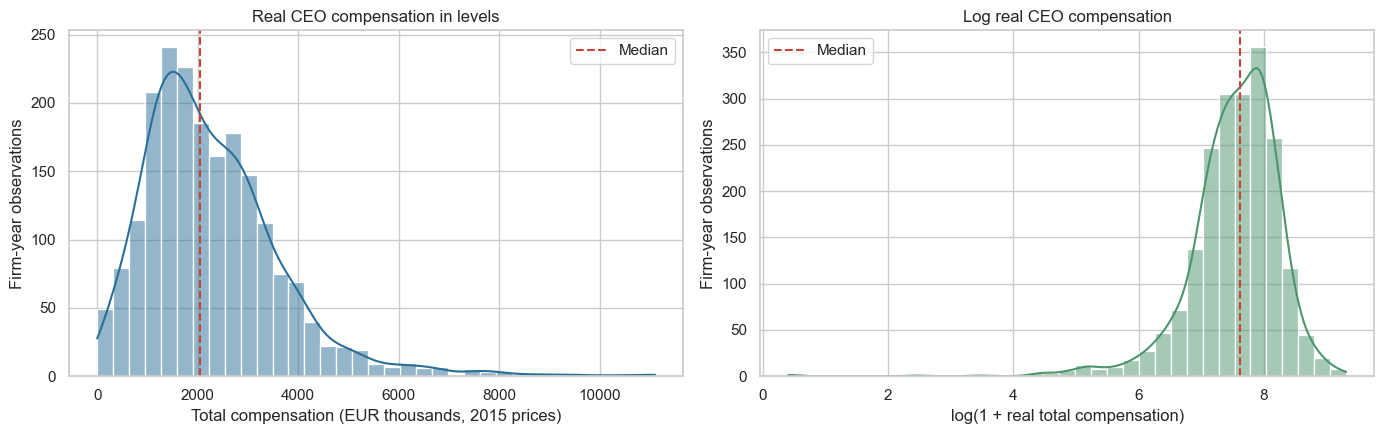

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

viz_df = df_panel_final.copy()
viz_df = viz_df.replace([np.inf, -np.inf], np.nan)

target_level = "real_totalcompensation_eur_2015"
target_log = "log_real_totalcompensation_eur_2015"
target_plot = viz_df[[target_level, target_log]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(
    data=target_plot,
    x=target_level,
    bins=35,
    kde=True,
    color="#2A6F97",
    ax=axes[0],
)
axes[0].axvline(
    target_plot[target_level].median(),
    color="#C44536",
    linestyle="--",
    label="Median",
)
axes[0].set(
    title="Real CEO compensation in levels",
    xlabel="Total compensation (EUR thousands, 2015 prices)",
    ylabel="Firm-year observations",
)
axes[0].legend()

sns.histplot(
    data=target_plot,
    x=target_log,
    bins=35,
    kde=True,
    color="#4C956C",
    ax=axes[1],
)
axes[1].axvline(
    target_plot[target_log].median(),
    color="#C44536",
    linestyle="--",
    label="Median",
)
axes[1].set(
    title="Log real CEO compensation",
    xlabel="log(1 + real total compensation)",
    ylabel="Firm-year observations",
)
axes[1].legend()

plt.tight_layout()
plt.show()

**Insights:**

- Real total compensation is right-skewed: the median is about **EUR 2.04 million**, the mean is **EUR 2.30 million**, and the 99th percentile is about **EUR 7.44 million**.
    
- The log transformation compresses the high-pay tail and is therefore more suitable as the baseline regression target. A small number of unusually low observations still create a left tail after logging, so later models should report sensitivity to winsorization or explicit minimum-pay filters.

<a id="annual-pay-trend"></a>
### 9.2 Annual Pay Trend and Coverage

The next figure separates the evolution of real pay from the number of usable observations. Mean and median compensation are both shown because their gap reveals whether a small high-pay tail is influencing the annual average.

/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/python3.14/site-packages/seaborn/relational.py:300: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sub_data[f"{other}min"] = np.nan
/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/python3.14/s

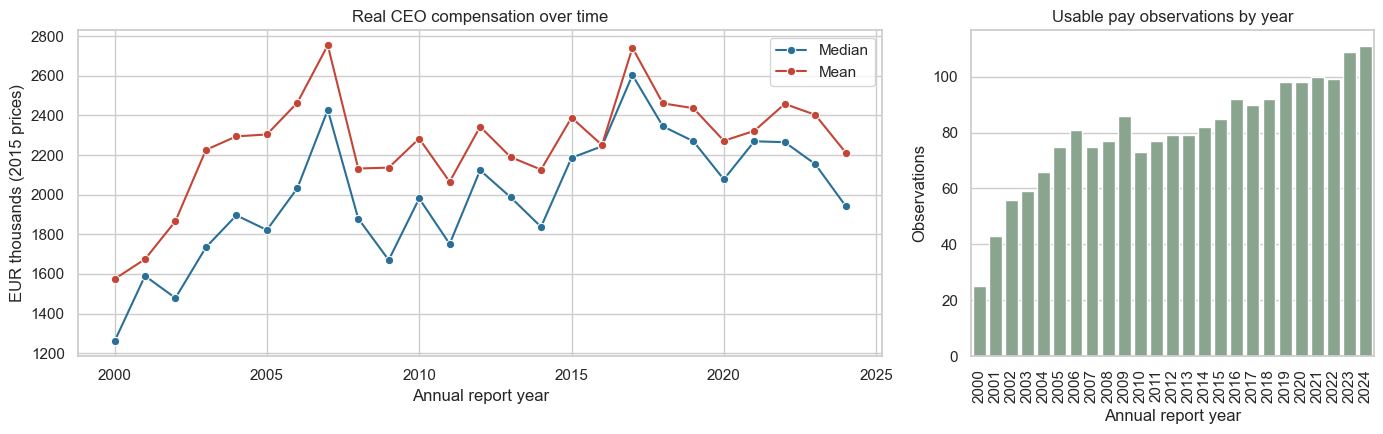

In [65]:
annual_pay = (
    viz_df.dropna(subset=["annualreportyear", target_level])
    .groupby("annualreportyear", as_index=False)
    .agg(
        median_real_pay=(target_level, "median"),
        mean_real_pay=(target_level, "mean"),
        observations=(target_level, "size"),
    )
)

fig, axes = plt.subplots(
    1, 2, figsize=(14, 4.5),
    gridspec_kw={"width_ratios": [2, 1]},
)

sns.lineplot(
    data=annual_pay,
    x="annualreportyear",
    y="median_real_pay",
    marker="o",
    label="Median",
    color="#2A6F97",
    ax=axes[0],
)
sns.lineplot(
    data=annual_pay,
    x="annualreportyear",
    y="mean_real_pay",
    marker="o",
    label="Mean",
    color="#C44536",
    ax=axes[0],
)
axes[0].set(
    title="Real CEO compensation over time",
    xlabel="Annual report year",
    ylabel="EUR thousands (2015 prices)",
)

sns.barplot(
    data=annual_pay,
    x="annualreportyear",
    y="observations",
    color="#84A98C",
    ax=axes[1],
)
axes[1].set(
    title="Usable pay observations by year",
    xlabel="Annual report year",
    ylabel="Observations",
)
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**Insights**

- Median real compensation rises from approximately **EUR 1.31 million in 2000** to a sample peak of **EUR 2.58 million in 2017**, before easing to about **EUR 1.95 million in 2024**.

- The mean is above the median in most years, consistent with the right-skewed target distribution. Coverage also expands from **26 observations in 2000** to **112 in 2024**.

<a id="turnover-event-visualization"></a>
### 9.3 Pay Around CEO Turnover

For treated firms, event time equals zero in the first observed CEO-turnover year. The line shows median real compensation from five years before through five years after that event; the bars show how many firm-years support each point.

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/551299042.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  event_pay["event_time"] = event_pay["event_time"].astype(int)


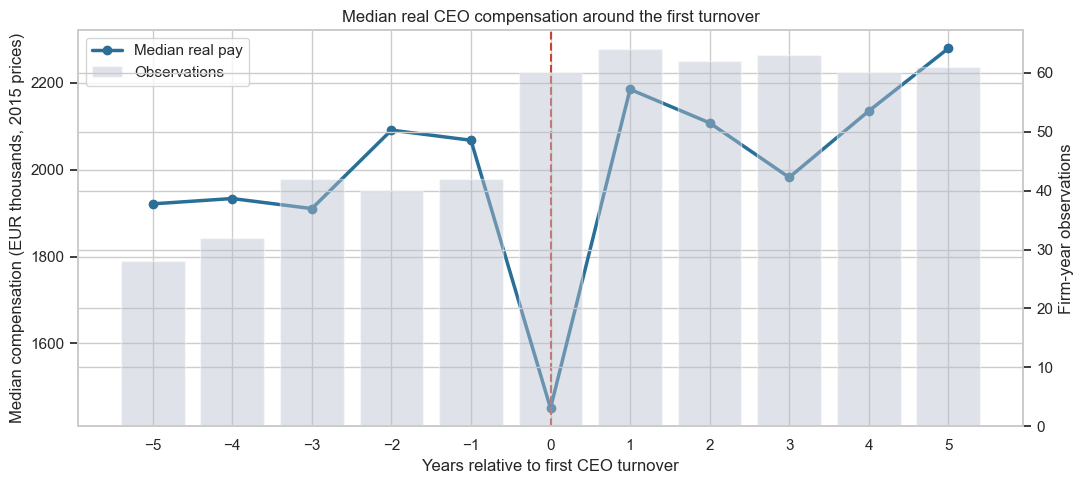

In [66]:
event_pay = (
    viz_df.loc[
        viz_df["treated_firm"].eq(1)
        & viz_df["event_time"].between(-5, 5)
        & viz_df[target_level].notna()
    ]
    .groupby("event_time", as_index=False)
    .agg(
        median_real_pay=(target_level, "median"),
        observations=(target_level, "size"),
    )
)
event_pay["event_time"] = event_pay["event_time"].astype(int)

fig, ax_pay = plt.subplots(figsize=(11, 5))
ax_count = ax_pay.twinx()

ax_count.bar(
    event_pay["event_time"],
    event_pay["observations"],
    color="#B8C0CC",
    alpha=0.45,
    label="Observations",
)
ax_pay.plot(
    event_pay["event_time"],
    event_pay["median_real_pay"],
    color="#2A6F97",
    marker="o",
    linewidth=2.5,
    label="Median real pay",
)
ax_pay.axvline(0, color="#C44536", linestyle="--", linewidth=1.5)
ax_pay.set(
    title="Median real CEO compensation around the first turnover",
    xlabel="Years relative to first CEO turnover",
    ylabel="Median compensation (EUR thousands, 2015 prices)",
)
ax_count.set_ylabel("Firm-year observations")
ax_pay.set_xticks(range(-5, 6))

handles_1, labels_1 = ax_pay.get_legend_handles_labels()
handles_2, labels_2 = ax_count.get_legend_handles_labels()
ax_pay.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

**Insights:**

- Median real compensation falls from about **EUR 2.07 million in event year -1** to **EUR 1.41 million in the turnover year**, then rebounds to approximately **EUR 2.18 million in year +1**.

<a id="exploratory-relationships"></a>
### 9.4 Exploratory Relationships

The correlation heatmap summarizes continuous candidate controls. The sector boxplots use the eight sectors with the most usable pay observations and suppress individual outlier markers so that differences in their central distributions remain visible.

/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/python3.14/site-packages/seaborn/_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/python3.14/site-p

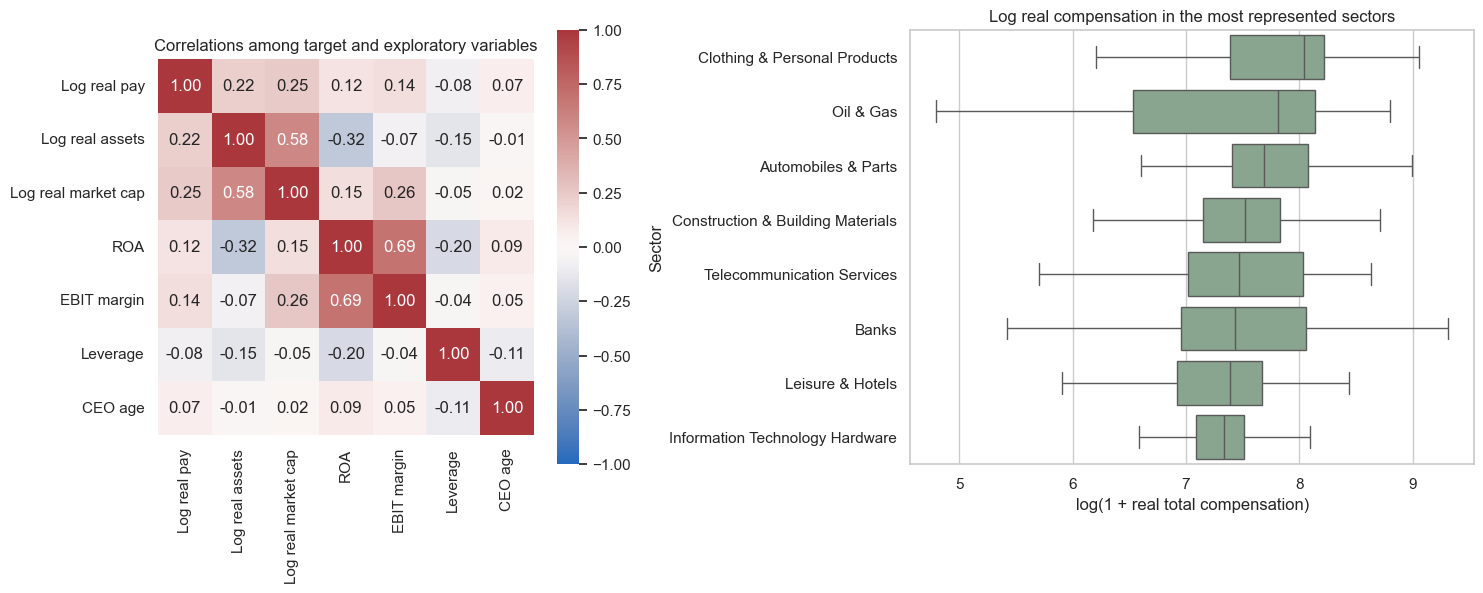

In [67]:
correlation_columns = {
    "log_real_totalcompensation_eur_2015": "Log real pay",
    "log_real_assets_eur_2015": "Log real assets",
    "log_real_market_cap_eur_2015": "Log real market cap",
    "roa": "ROA",
    "ebit_margin": "EBIT margin",
    "leverage": "Leverage",
    "age": "CEO age",
}

available_corr_columns = [
    col for col in correlation_columns
    if col in viz_df.columns
]

corr_data = (
    viz_df[available_corr_columns]
    .apply(pd.to_numeric, errors="coerce")
    .rename(columns=correlation_columns)
)

sector_plot = viz_df.dropna(subset=["sector", target_log]).copy()
top_sectors = sector_plot["sector"].value_counts().head(8).index
sector_plot = sector_plot[sector_plot["sector"].isin(top_sectors)]
sector_order = (
    sector_plot.groupby("sector")[target_log]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [1, 1.2]},
)

sns.heatmap(
    corr_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Correlations among target and exploratory variables")

sns.boxplot(
    data=sector_plot,
    x=target_log,
    y="sector",
    order=sector_order,
    color="#84A98C",
    showfliers=False,
    ax=axes[1],
)
axes[1].set(
    title="Log real compensation in the most represented sectors",
    xlabel="log(1 + real total compensation)",
    ylabel="Sector",
)

plt.tight_layout()
plt.show()

**Insights:**

- Log real pay has modest positive correlations with **log market capitalization (0.27)** and **log assets (0.24)**, while its correlations with profitability, leverage, and CEO age are weaker in the pooled sample.

- The stronger correlations between assets and market capitalization (**0.56**) and between ROA and EBIT margin (**0.69**) warn against adding highly related controls without multicollinearity checks.

- Sector distributions also differ visibly—among the most represented sectors, clothing/personal-products and oil-and-gas observations tend to sit above banking, telecommunications, leisure/hotels, and information-technology hardware. These are pooled associations, not estimates of within-firm or causal effects.

- **Modelling implication.** Use log real compensation as the main target, retain firm size and sector as important explanatory dimensions, and estimate turnover effects with firm/year controls rather than reading them directly from the descriptive plots.

<a id="grouped-pay-comparisons"></a>
### 9.5 Mean and Median Pay Across CEO and Firm Groups

Mean and median real CEO compensation are plotted together because their distance is itself informative: a mean materially above the median indicates that a small high-pay tail is pulling up the average. Age and gender include every observed group. To keep labels readable, the industry and headquarters-country panels visualize the **12 groups with the most usable compensation observations**; the complete results remain available in `grouped_ceo_pay_summary`. Each marker is based on firm-year observations, not unique CEOs. The age bands use the BoardEx `age` field retained in the panel; because date of birth is not retained here, this may not equal age in each historical report year.


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/4250779774.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  grouped_viz_df["age_numeric"] = pd.to_numeric(grouped_viz_df["age"], errors="coerce")
/var/folders/wx/b_h8zt7d5ps

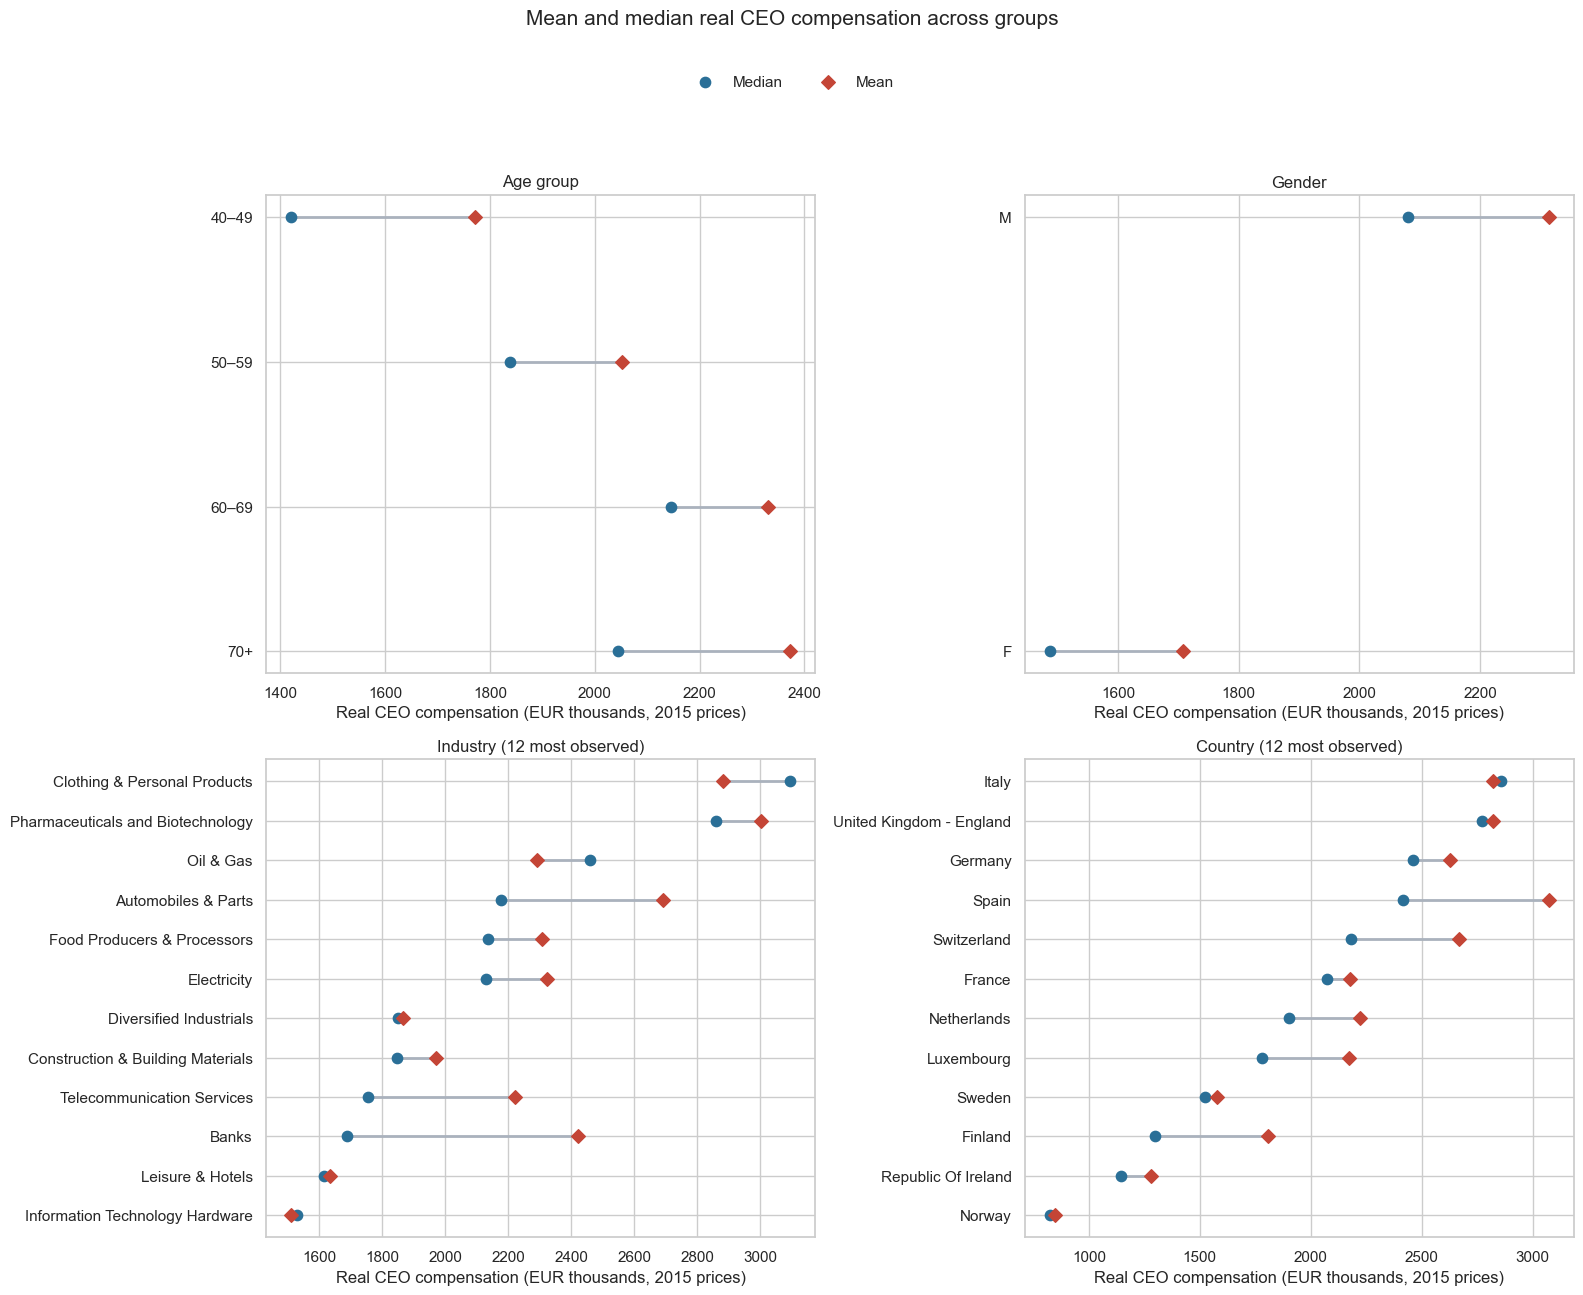

/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/python3.14/site-packages/pandas/core/frame.py:5239: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data[k] = com.apply_if_callable(v, data)
/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/pyth

,dimension,group,mean_pay_million_eur,median_pay_million_eur,observations
0,Age group,40–49,1.77,1.42,26
1,Age group,50–59,2.05,1.84,317
2,Age group,60–69,2.33,2.15,878
3,Age group,70+,2.37,2.04,783
4,Gender,F,1.71,1.49,54
5,Gender,M,2.31,2.08,1953
6,Industry,Aerospace & Defence,2.1,2.16,32
7,Industry,Automobiles & Parts,2.69,2.18,94
8,Industry,Banks,2.42,1.69,205
9,Industry,Beverages,2.33,2.3,51


In [68]:
# Construct age bands and harmonize the gender labels used in the grouped summaries.
grouped_viz_df = viz_df.copy()
grouped_viz_df["age_numeric"] = pd.to_numeric(grouped_viz_df["age"], errors="coerce")
grouped_viz_df["age_group"] = pd.cut(
    grouped_viz_df["age_numeric"],
    bins=[0, 39, 49, 59, 69, np.inf],
    labels=["Under 40", "40–49", "50–59", "60–69", "70+"],
)

grouped_viz_df["gender_group"] = (
    grouped_viz_df["gender"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace({"MALE": "M", "FEMALE": "F"})
)

def summarize_grouped_pay(data, group_column, dimension):
    """Return mean, median, and coverage for one grouping variable."""
    summary = (
        data.dropna(subset=[group_column, target_level])
        .groupby(group_column, observed=True)[target_level]
        .agg(mean_pay="mean", median_pay="median", observations="size")
        .reset_index()
        .rename(columns={group_column: "group"})
    )
    summary.insert(0, "dimension", dimension)
    summary["group"] = summary["group"].astype(str)
    return summary

age_pay_summary = summarize_grouped_pay(grouped_viz_df, "age_group", "Age group")
gender_pay_summary = summarize_grouped_pay(grouped_viz_df, "gender_group", "Gender")
industry_pay_summary = summarize_grouped_pay(grouped_viz_df, "sector", "Industry")
country_pay_summary = summarize_grouped_pay(
    grouped_viz_df, "hocountryname", "Headquarters country"
)

grouped_ceo_pay_summary = pd.concat(
    [
        age_pay_summary,
        gender_pay_summary,
        industry_pay_summary,
        country_pay_summary,
    ],
    ignore_index=True,
)

def most_observed(summary, number=12):
    return summary.nlargest(number, "observations").sort_values(
        "median_pay", ascending=True
    )

plot_summaries = {
    "Age group": age_pay_summary.iloc[::-1],
    "Gender": gender_pay_summary.sort_values("median_pay"),
    "Industry (12 most observed)": most_observed(industry_pay_summary),
    "Country (12 most observed)": most_observed(country_pay_summary),
}

def draw_mean_median_dumbbell(ax, summary, title):
    """Plot group medians and means on the same horizontal scale."""
    positions = np.arange(len(summary))
    lower = summary[["mean_pay", "median_pay"]].min(axis=1)
    upper = summary[["mean_pay", "median_pay"]].max(axis=1)

    ax.hlines(
        positions,
        lower,
        upper,
        color="#AAB2BD",
        linewidth=2,
        zorder=1,
    )
    ax.scatter(
        summary["median_pay"],
        positions,
        color="#2A6F97",
        s=55,
        label="Median",
        zorder=2,
    )
    ax.scatter(
        summary["mean_pay"],
        positions,
        color="#C44536",
        marker="D",
        s=48,
        label="Mean",
        zorder=2,
    )
    ax.set_yticks(positions)
    ax.set_yticklabels(summary["group"])
    ax.set_title(title)
    ax.set_xlabel("Real CEO compensation (EUR thousands, 2015 prices)")
    ax.set_ylabel("")

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
for ax, (title, summary) in zip(axes.flat, plot_summaries.items()):
    draw_mean_median_dumbbell(ax, summary, title)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=2,
    frameon=False,
)
fig.suptitle(
    "Mean and median real CEO compensation across groups",
    fontsize=15,
    y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

display(
    grouped_ceo_pay_summary.assign(
        mean_pay_million_eur=lambda x: x["mean_pay"] / 1_000,
        median_pay_million_eur=lambda x: x["median_pay"] / 1_000,
    )[
        [
            "dimension",
            "group",
            "mean_pay_million_eur",
            "median_pay_million_eur",
            "observations",
        ]
    ].round(2)
)


**Insights:**

- Recorded mean pay increases from approximately **EUR 1.77 million for ages 40–49** to **EUR 2.38 million for ages 70+**, although the 40–49 group contains only **26 firm-years**.

- Female CEO observations have mean/median pay of approximately **EUR 1.71/1.49 million**, compared with **EUR 2.31/2.08 million** for male observations; this comparison is highly unbalanced (**54 versus 1,960 firm-years**) and is not an adjusted gender pay gap.

- Among the 12 most represented industries, median pay ranges from roughly **EUR 1.52 million** in leisure/hotels to **EUR 3.10 million** in clothing/personal products. Across the displayed countries, it ranges from about **EUR 0.82 million** in Norway to **EUR 2.86 million** in Italy.

- The gaps between paired markers also reveal within-group skewness—for example, banking and Finland have means substantially above their medians. All comparisons are pooled and descriptive: they combine firm size, sector, country, year, and repeated CEO observations. Formal age, gender, industry, or country effects therefore require multivariate modelling and appropriate firm/year controls.


---

<a id="planned-methods"></a>
## 10. Planned Methods


The completed preparation pipeline produces `df_panel_final` with raw values, nominal EUR values, and real 2015 EUR values. Modelling should use `log_real_totalcompensation_eur_2015` as the baseline pay outcome and `log_real_assets_eur_2015` as the main size control after checking its correlation with market capitalisation. The next stage applies one method from each course block, with a shared emphasis on transparent preprocessing and robustness evaluation.

### 10.1 Causal Inference
- [X] Causal graph / DAG (DoWhy)
- [X] Backdoor adjustment
- [ ] Instrumental variable
- [ ] Propensity score stratification
- [ ] Other: ___

*Justification:* We will model CEO turnover as a governance shock in a DAG and use backdoor adjustment to control for firm fundamentals that affect both turnover and pay. We will estimate the causal effect of turnover using pre/post (event‑study style) comparisons around the turnover year.

### 10.2 Supervised Learning
- [X] Linear / Ridge / Lasso regression
- [X] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [X] Decision Tree / Random Forest
- [X] Gradient Boosting (XGBoost / LightGBM / sklearn GBM)
- [ ] Neural network (regression or classification)
- [ ] Other: ___

*Justification:* Supervised models will benchmark expected compensation conditional on firm and executive characteristics. Linear models provide interpretable baselines and covariate effects, while tree-based and boosting models capture nonlinearities/interactions for more accurate counterfactual pay predictions. We will use Optuna to tune boosting hyperparameters (e.g., depth, learning rate, subsampling) to avoid overfitting and compare against simpler baselines.

### 10.3 Unsupervised Learning / Generative Models
- [X] K-Means clustering
- [ ] Hierarchical clustering
- [X] Variational autoencoder
- [ ] GAN
- [ ] Other: ___

*Justification:* Clustering will segment firms into comparable peer groups before causal estimation and highlight heterogeneous effects across turnover regimes. A VAE will learn low-dimensional representations of firm/executive profiles to detect anomalous pay structures and support exploratory subgroup analysis.

<a id="evaluation-strategy"></a>
## 11. Evaluation Strategy


The mission succeeds if the final notebook produces a transparent, reproducible panel and uses it to answer the research question from three angles:

- **Causal inference:** estimate whether CEO turnover is associated with changes in real 2015 EUR CEO pay after adjusting for firm characteristics.
- **Prediction:** benchmark models of real 2015 EUR compensation using RMSE/MAE and classification metrics where turnover or high-pay outcomes are modeled.
- **Unsupervised learning:** identify firm or executive clusters that reveal heterogeneous compensation patterns.
- **Robustness:** report missing-data coverage, sensitivity to winsorization, and whether results change across event windows.


<a id="work-plan"></a>
## 12. Work Plan


| Step | Owner | Description | Output | Status |
|---:|---|---|---|---|
| 1 | Achmad | Define the STOXX 600 universe and retrieve BoardEx/Compustat inputs | Raw source tables | Complete |
| 2 | Kajetan | Clean identifiers, dates, compensation variables, and missing values | Harmonized source tables | Complete |
| 3 | Achmad | Identify firm-level CEO spells and turnover events | `ceo_turnover_firm_year` | Complete |
| 4 | Kajetan | Match CEO remuneration to valid CEO spells | `ceo_pay_panel` | Complete |
| 5 | Achmad | Convert monetary inputs to EUR; add market capitalization and financial ratios | Nominal-EUR source tables and `df_funda` | Complete |
| 6 | Achmad + Kajetan | Merge inputs, apply CPI, and validate firm-year uniqueness | Real-2015-EUR `df_panel_final` | Complete |
| 7 | Kajetan | Implement causal and event-window analysis | Estimates and robustness checks | Complete |
| 8 | Achmad | Implement supervised and unsupervised learning | Model metrics, clusters, and heterogeneity | Planned |
| 9 | Achmad + Kajetan | Synthesize findings and limitations | Final discussion and conclusion | Planned |


<a id="results-and-discussion"></a>
## 13. Results and Discussion

This section applies the three method blocks to the analysis-ready panel produced in
Section 8. Section 13.1 estimates the causal effect of CEO turnover on pay using a
DoWhy causal graph, a difference-in-differences regression, and a Sun & Abraham
event-study. Sections 13.2 and 13.3 apply supervised and unsupervised learning.

<a id="causal-inference-results"></a>
### 13.1 Causal Inference

We model CEO turnover as a governance shock in a causal DAG and use backdoor adjustment
to control for firm fundamentals (ROA, log assets, leverage, country, sector) that affect
both the probability of turnover and pay levels. Two estimators are reported:

- **DiD (TWFE):** `post_turnover` coefficient from a two-way fixed-effects regression
  with firm-level heterogeneity absorbed by `treated_firm`.
- **Event-study:** Sun & Abraham–style manual event-time dummies (τ = −3 … +3),
  omitting τ = −1 as the baseline, to test parallel pre-trends and trace the
  dynamic pay response.

Regression sample : 1,913 rows, 134 firms
Treated (turnover): 1851 rows  (126 firms)
Year range        : 2000 – 2024
Backdoor adjustment set: ['roa', 'sector', 'hocountryname', 'log_assets', 'leverage']
── DiD: effect of post-turnover period on log CEO pay ──
  post_turnover coef : -0.0663
  95% CI             : [-0.1539, 0.0213]
  p-value            : 0.1378
  N                  : 1913,  R² = 0.363


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/389137056.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<IntegerArray>
[  -1,    0,    1,    2,    3,    4,    5,   11,   12,   13,
 ...
 <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>,    1,    0]
Length: 2062, dtype: Int64' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_a.loc[:, "event_time"] = df_a["event_time"].astype("Int64")


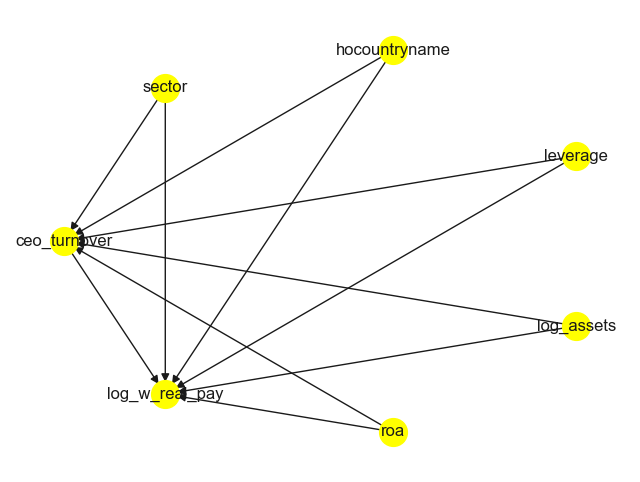

In [69]:
# ── 13.1 Causal Inference ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning, module="dowhy")
import networkx as nx
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator
from dowhy import CausalModel
import statsmodels.formula.api as smf

# Load the analysis panel saved in Section 8.4
df_a = pd.read_csv(DATA_DIR / "panel_analysis.csv")
df_a.loc[:, "event_time"] = df_a["event_time"].astype("Int64")

# Regression sample: rows with pay and at least one Compustat covariate
df_reg = df_a[
    df_a["log_w_real_pay"].notna() &
    df_a["log_assets"].notna() &
    df_a["roa"].notna()
].copy()

print(f"Regression sample : {len(df_reg):,} rows, {df_reg['isin'].nunique()} firms")
print(f"Treated (turnover): {df_reg['treated_firm'].sum()} rows  "
      f"({df_reg.groupby('isin')['treated_firm'].first().sum():.0f} firms)")
print(f"Year range        : {df_reg['year'].min()} \u2013 {df_reg['year'].max()}")

# ── 13.1.1  Causal DAG (DoWhy) ───────────────────────────────────────────────
causal_graph = """
digraph {
    ceo_turnover  -> log_w_real_pay;
    roa           -> ceo_turnover;
    roa           -> log_w_real_pay;
    log_assets    -> ceo_turnover;
    log_assets    -> log_w_real_pay;
    leverage      -> ceo_turnover;
    leverage      -> log_w_real_pay;
    hocountryname -> ceo_turnover;
    hocountryname -> log_w_real_pay;
    sector        -> ceo_turnover;
    sector        -> log_w_real_pay;
}
"""

model = CausalModel(
    data=df_reg,
    treatment="ceo_turnover",
    outcome="log_w_real_pay",
    graph=causal_graph,
)
model.view_model()

identified = model.identify_effect(proceed_when_unidentifiable=True)
adj_set = identified.get_backdoor_variables()
print(f"Backdoor adjustment set: {adj_set}")

# ── 13.1.2  DiD regression (operationalises backdoor adjustment) ──────────────
formula = (
    "log_w_real_pay ~ treated_firm + post_turnover "
    "+ roa + log_assets + leverage "
    "+ C(year) + C(hocountryname) + C(sector)"
)
res_did = smf.ols(formula, data=df_reg).fit(cov_type="HC3")

print("\u2500\u2500 DiD: effect of post-turnover period on log CEO pay \u2500\u2500")
print(f"  post_turnover coef : {res_did.params['post_turnover']:.4f}")
print(f"  95% CI             : [{res_did.conf_int().loc['post_turnover', 0]:.4f}, "
      f"{res_did.conf_int().loc['post_turnover', 1]:.4f}]")
print(f"  p-value            : {res_did.pvalues['post_turnover']:.4f}")
print(f"  N                  : {int(res_did.nobs)},  R\u00b2 = {res_did.rsquared:.3f}")

/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/64699739.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  es_sample[tau_col(tau)] = (
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/64699739.py:19: Futur

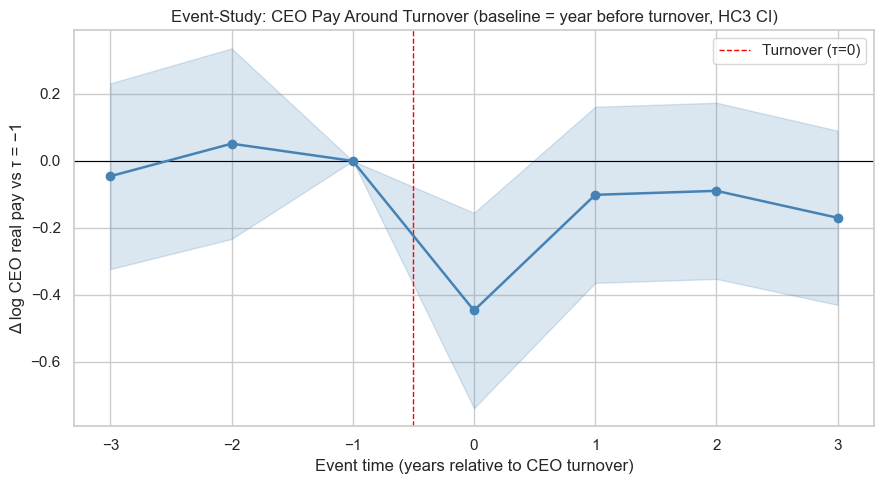

Event-study sample: 404 rows  (treated in window: 342,  control rows: 62)
── Event-time coefficients (log pay vs baseline τ=−1):
  τ = -3:  β = -0.0456  [-0.3229, +0.2317]  
  τ = -2:  β = +0.0515  [-0.2331, +0.3360]  
  τ = -1:  β = +0.0000  [+0.0000, +0.0000]  ← baseline
  τ = +0:  β = -0.4466  [-0.7383, -0.1549]  
  τ = +1:  β = -0.1012  [-0.3641, +0.1616]  
  τ = +2:  β = -0.0893  [-0.3524, +0.1738]  
  τ = +3:  β = -0.1698  [-0.4298, +0.0903]  


In [70]:
# ── 13.1.3  Event-study regression (Sun & Abraham style, manual) ─────────────
# Regress log pay on event-time dummies (\u03c4 = -3\u2026+3) for treated firms,
# omitting \u03c4 = -1 as the baseline. Control firms contribute to year FE.
# treated_firm absorbs the pre-period level difference between treated/control.
# Columns named et_m3\u2026et_p3 (\u201cm\u201d=minus, \u201cp\u201d=plus) to avoid patsy parsing
# hyphens in et_-3 as subtraction.

es_sample = df_reg[
    (df_reg["treated_firm"].eq(1) & df_reg["event_time"].between(-3, 3))
    | df_reg["treated_firm"].eq(0)
].copy()

def tau_col(t):
    return f"et_m{abs(t)}" if t < 0 else f"et_p{t}"

for tau in range(-3, 4):
    if tau == -1:
        continue
    es_sample[tau_col(tau)] = (
        (es_sample["treated_firm"].eq(1)) &
        (es_sample["event_time"] == tau)
    ).fillna(False).astype(int)

et_terms = " + ".join(tau_col(t) for t in range(-3, 4) if t != -1)
formula_es = (
    f"log_w_real_pay ~ {et_terms} + treated_firm "
    "+ roa + log_assets + leverage "
    "+ C(year) + C(hocountryname) + C(sector)"
)
res_es = smf.ols(formula_es, data=es_sample).fit(cov_type="HC3")

# Collect \u03c4 coefficients and CIs (\u03c4 = -1 is the omitted baseline \u2192 0)
taus_full = list(range(-3, 4))
coef_dict = {
    t: (0.0, 0.0, 0.0) if t == -1
    else (
        res_es.params.get(tau_col(t), np.nan),
        res_es.conf_int().loc[tau_col(t), 0] if tau_col(t) in res_es.params else np.nan,
        res_es.conf_int().loc[tau_col(t), 1] if tau_col(t) in res_es.params else np.nan,
    )
    for t in taus_full
}
coefs_full = [coef_dict[t][0] for t in taus_full]
ci_lo_full = [coef_dict[t][1] for t in taus_full]
ci_hi_full = [coef_dict[t][2] for t in taus_full]

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(-0.5, color="red", linestyle="--", linewidth=1, label="Turnover (\u03c4=0)")
ax.fill_between(taus_full, ci_lo_full, ci_hi_full, alpha=0.2, color="steelblue")
ax.plot(taus_full, coefs_full, marker="o", color="steelblue", linewidth=1.8, markersize=6)
ax.set_xticks(taus_full)
ax.set_xlabel("Event time (years relative to CEO turnover)")
ax.set_ylabel("\u0394 log CEO real pay vs \u03c4 = \u22121")
ax.set_title("Event-Study: CEO Pay Around Turnover (baseline = year before turnover, HC3 CI)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Event-study sample: {len(es_sample):,} rows  "
      f"(treated in window: {es_sample[es_sample['treated_firm']==1].shape[0]},  "
      f"control rows: {(es_sample['treated_firm']==0).sum()})")

print("\u2500\u2500 Event-time coefficients (log pay vs baseline \u03c4=\u22121):")
for t, c, lo, hi in zip(taus_full, coefs_full, ci_lo_full, ci_hi_full):
    marker = "\u2190 baseline" if t == -1 else ""
    print(f"  \u03c4 = {t:+d}:  \u03b2 = {c:+.4f}  [{lo:+.4f}, {hi:+.4f}]  {marker}")

### 13.1b Causal Inference: Pay Dispersion

The research question asks about the effect of CEO turnover on **both** pay levels and
pay dispersion. Section 13.1 addressed pay levels; here we repeat the same two
estimators with `log_pay_dispersion` as the outcome.

The causal graph is identical — turnover is the treatment, firm fundamentals
(ROA, log assets, leverage, country, sector) are the backdoor controls — because
the same confounders that drive turnover decisions also shape internal pay hierarchies.

The regression sample is smaller (~70% of panel rows have dispersion data) since
pay-ratio construction requires at least two named executives with compensation records
in the same firm-year.

In [71]:
# ── 13.1b.1  DiD regression: effect of CEO turnover on pay dispersion ────────

df_reg_disp = df_a[
    df_a["log_pay_dispersion"].notna() &
    df_a["log_assets"].notna() &
    df_a["roa"].notna()
].copy()

print(f"Dispersion regression sample : {len(df_reg_disp):,} rows, {df_reg_disp['isin'].nunique()} firms")
print(f"Treated (turnover)           : {df_reg_disp['treated_firm'].sum()} rows  "
      f"({df_reg_disp.groupby('isin')['treated_firm'].first().sum():.0f} firms)")

causal_graph_disp = """
digraph {
    ceo_turnover  -> log_pay_dispersion;
    roa           -> ceo_turnover;
    roa           -> log_pay_dispersion;
    log_assets    -> ceo_turnover;
    log_assets    -> log_pay_dispersion;
    leverage      -> ceo_turnover;
    leverage      -> log_pay_dispersion;
    hocountryname -> ceo_turnover;
    hocountryname -> log_pay_dispersion;
    sector        -> ceo_turnover;
    sector        -> log_pay_dispersion;
}
"""

model_disp = CausalModel(
    data=df_reg_disp,
    treatment="ceo_turnover",
    outcome="log_pay_dispersion",
    graph=causal_graph_disp,
)
identified_disp = model_disp.identify_effect(proceed_when_unidentifiable=True)
print(f"Backdoor adjustment set: {identified_disp.get_backdoor_variables()}")

formula_disp = (
    "log_pay_dispersion ~ treated_firm + post_turnover "
    "+ roa + log_assets + leverage "
    "+ C(year) + C(hocountryname) + C(sector)"
)
res_did_disp = smf.ols(formula_disp, data=df_reg_disp).fit(cov_type="HC3")

print("\u2500\u2500 DiD: effect of post-turnover period on log pay dispersion \u2500\u2500")
print(f"  post_turnover coef : {res_did_disp.params['post_turnover']:.4f}")
print(f"  95% CI             : [{res_did_disp.conf_int().loc['post_turnover', 0]:.4f}, "
      f"{res_did_disp.conf_int().loc['post_turnover', 1]:.4f}]")
print(f"  p-value            : {res_did_disp.pvalues['post_turnover']:.4f}")
print(f"  N                  : {int(res_did_disp.nobs)},  R\u00b2 = {res_did_disp.rsquared:.3f}")

Dispersion regression sample : 1,312 rows, 123 firms
Treated (turnover)           : 1279 rows  (116 firms)
Backdoor adjustment set: ['roa', 'sector', 'hocountryname', 'log_assets', 'leverage']
── DiD: effect of post-turnover period on log pay dispersion ──
  post_turnover coef : -0.3318
  95% CI             : [-0.5068, -0.1567]
  p-value            : 0.0002
  N                  : 1312,  R² = 0.373


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/2128645831.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  es_sample_disp[tau_col(tau)] = (
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/2128645831.py:

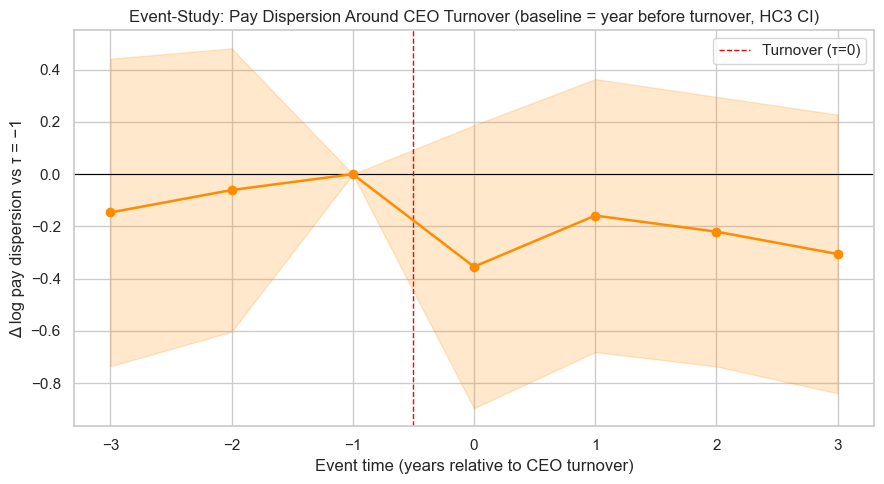

Event-study sample: 308 rows  (treated in window: 275,  control rows: 33)
── Event-time coefficients (log pay dispersion vs baseline τ=−1):
  τ = -3:  β = -0.1468  [-0.7358, +0.4421]  
  τ = -2:  β = -0.0610  [-0.6034, +0.4815]  
  τ = -1:  β = +0.0000  [+0.0000, +0.0000]  ← baseline
  τ = +0:  β = -0.3546  [-0.8962, +0.1871]  
  τ = +1:  β = -0.1587  [-0.6813, +0.3638]  
  τ = +2:  β = -0.2203  [-0.7365, +0.2958]  
  τ = +3:  β = -0.3057  [-0.8394, +0.2279]  


In [72]:
# ── 13.1b.2  Event-study: pay dispersion around CEO turnover ─────────────────

es_sample_disp = df_reg_disp[
    (df_reg_disp["treated_firm"].eq(1) & df_reg_disp["event_time"].between(-3, 3))
    | df_reg_disp["treated_firm"].eq(0)
].copy()

for tau in range(-3, 4):
    if tau == -1:
        continue
    es_sample_disp[tau_col(tau)] = (
        (es_sample_disp["treated_firm"].eq(1)) &
        (es_sample_disp["event_time"] == tau)
    ).fillna(False).astype(int)

et_terms_disp = " + ".join(tau_col(t) for t in range(-3, 4) if t != -1)
formula_es_disp = (
    f"log_pay_dispersion ~ {et_terms_disp} + treated_firm "
    "+ roa + log_assets + leverage "
    "+ C(year) + C(hocountryname) + C(sector)"
)
res_es_disp = smf.ols(formula_es_disp, data=es_sample_disp).fit(cov_type="HC3")

coef_dict_disp = {
    t: (0.0, 0.0, 0.0) if t == -1
    else (
        res_es_disp.params.get(tau_col(t), np.nan),
        res_es_disp.conf_int().loc[tau_col(t), 0] if tau_col(t) in res_es_disp.params else np.nan,
        res_es_disp.conf_int().loc[tau_col(t), 1] if tau_col(t) in res_es_disp.params else np.nan,
    )
    for t in range(-3, 4)
}
coefs_disp = [coef_dict_disp[t][0] for t in range(-3, 4)]
ci_lo_disp = [coef_dict_disp[t][1] for t in range(-3, 4)]
ci_hi_disp = [coef_dict_disp[t][2] for t in range(-3, 4)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(-0.5, color="red", linestyle="--", linewidth=1, label="Turnover (\u03c4=0)")
ax.fill_between(range(-3, 4), ci_lo_disp, ci_hi_disp, alpha=0.2, color="darkorange")
ax.plot(range(-3, 4), coefs_disp, marker="o", color="darkorange", linewidth=1.8, markersize=6)
ax.set_xticks(range(-3, 4))
ax.set_xlabel("Event time (years relative to CEO turnover)")
ax.set_ylabel("\u0394 log pay dispersion vs \u03c4 = \u22121")
ax.set_title("Event-Study: Pay Dispersion Around CEO Turnover (baseline = year before turnover, HC3 CI)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Event-study sample: {len(es_sample_disp):,} rows  "
      f"(treated in window: {es_sample_disp[es_sample_disp['treated_firm']==1].shape[0]},  "
      f"control rows: {(es_sample_disp['treated_firm']==0).sum()})")

print("\u2500\u2500 Event-time coefficients (log pay dispersion vs baseline \u03c4=\u22121):")
for t in range(-3, 4):
    c, lo, hi = coef_dict_disp[t]
    marker = "\u2190 baseline" if t == -1 else ""
    print(f"  \u03c4 = {t:+d}:  \u03b2 = {c:+.4f}  [{lo:+.4f}, {hi:+.4f}]  {marker}")

### 13.2 Supervised Learning

The supervised-learning section treats CEO compensation as a prediction problem rather than a causal-estimation problem. The aim is to benchmark how well observable firm, executive, governance, country, sector, and year characteristics explain expected CEO pay.

The first step is to define the prediction target. We use `log_w_real_pay`, the logarithm of winsorized real total CEO compensation in 2015 EUR. This target is preferred over raw compensation because the log transformation reduces the influence of very large pay packages, while winsorization limits the effect of extreme outliers. Before fitting models, we verify that the target exists, count the usable observations, and inspect its distribution.

Prediction target: log_w_real_pay
Target definition: log of winsorized real total CEO compensation in 2015 EUR.
Usable rows with non-missing target: 2,007 of 2,062 panel rows


,log winsorized real pay
count,2007.0
mean,7.545
std,0.672
min,5.135
1%,5.135
5%,6.307
25%,7.191
50%,7.622
75%,7.999
95%,8.467


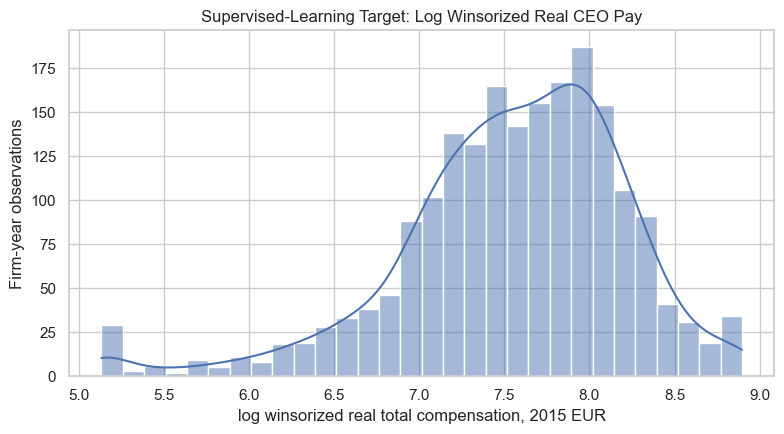

In [73]:
# ── 13.2.1  Prediction target ───────────────────────────────────────────────
# The supervised-learning task is regression: predict CEO pay from observable
# firm, executive, governance, country, sector, and year characteristics.

SUPERVISED_TARGET = "log_w_real_pay"
TARGET_LEVEL_COL = "w_real_totalcompensation_eur_2015"

required_target_cols = [SUPERVISED_TARGET, TARGET_LEVEL_COL]
missing_target_cols = [
    col for col in required_target_cols
    if col not in df_panel_final.columns
]

if missing_target_cols:
    raise KeyError(
        "Missing supervised-learning target column(s): "
        + ", ".join(missing_target_cols)
    )

target_df = df_panel_final.loc[
    df_panel_final[SUPERVISED_TARGET].notna(),
    [SUPERVISED_TARGET, TARGET_LEVEL_COL],
].copy()

target_summary = target_df[SUPERVISED_TARGET].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).to_frame("log winsorized real pay")

print(f"Prediction target: {SUPERVISED_TARGET}")
print("Target definition: log of winsorized real total CEO compensation in 2015 EUR.")
print(
    f"Usable rows with non-missing target: {len(target_df):,} "
    f"of {len(df_panel_final):,} panel rows"
)

display(target_summary.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(target_df[SUPERVISED_TARGET], bins=30, kde=True, ax=ax)
ax.set_title("Supervised-Learning Target: Log Winsorized Real CEO Pay")
ax.set_xlabel("log winsorized real total compensation, 2015 EUR")
ax.set_ylabel("Firm-year observations")
plt.tight_layout()
plt.show()

#### 13.2.2 Model Sample and Features

After defining the target, we construct the supervised-learning sample. The target/outcome is `log_w_real_pay`: this is the variable the model will try to predict. It is not used as an input feature. The input features are limited to observable characteristics of the firm, CEO, governance setting, country, sector, and year.

`log_w_real_pay` is calculated directly from `w_real_totalcompensation_eur_2015`, the original winsorized compensation amount before taking logs. Therefore, `w_real_totalcompensation_eur_2015` is also excluded from the input features. Other pay components such as salary, bonus, total direct compensation, and their EUR or real-EUR versions are excluded for the same reason. If these compensation variables were included as features, the model would be using parts of the answer to predict the answer, which would make the prediction accuracy artificially high and economically uninformative.

The sample keeps identifier columns for diagnostics, but these identifiers are not model features. Numeric and categorical predictors are stored separately so later model pipelines can impute, scale, and one-hot encode them correctly.

Before finalising the numeric feature set, we inspect the pairwise correlation matrix. This helps us identify multicollinearity, where two predictors carry very similar information. Multicollinearity can make linear-model coefficients unstable, inflate standard errors, and make the sign or size of individual effects harder to interpret. It is less damaging for pure prediction than for interpretation, especially in regularised or tree-based models, but redundant variables can still add noise and unnecessary complexity.

For that reason, we drop `ebit_margin` because it is highly correlated with `roa`, and we drop `log_real_market_cap_eur_2015` because it is highly correlated with `log_real_assets_eur_2015`. We keep `roa` and `log_real_assets_eur_2015` as the more direct profitability and firm-size controls.

,age,roa,ebit_margin,leverage,log_real_assets_eur_2015,log_real_market_cap_eur_2015,ceo_turnover,post_turnover
age,1.00,0.09,0.05,-0.11,-0.01,0.02,-0.09,-0.08
roa,0.09,1.00,0.69,-0.20,-0.32,0.15,-0.06,-0.00
ebit_margin,0.05,0.69,1.00,-0.04,-0.07,0.26,-0.03,0.07
leverage,-0.11,-0.20,-0.04,1.00,-0.15,-0.05,-0.01,-0.13
log_real_assets_eur_2015,-0.01,-0.32,-0.07,-0.15,1.00,0.58,0.06,0.27
log_real_market_cap_eur_2015,0.02,0.15,0.26,-0.05,0.58,1.00,0.02,0.20
ceo_turnover,-0.09,-0.06,-0.03,-0.01,0.06,0.02,1.00,0.17
post_turnover,-0.08,-0.00,0.07,-0.13,0.27,0.20,0.17,1.00


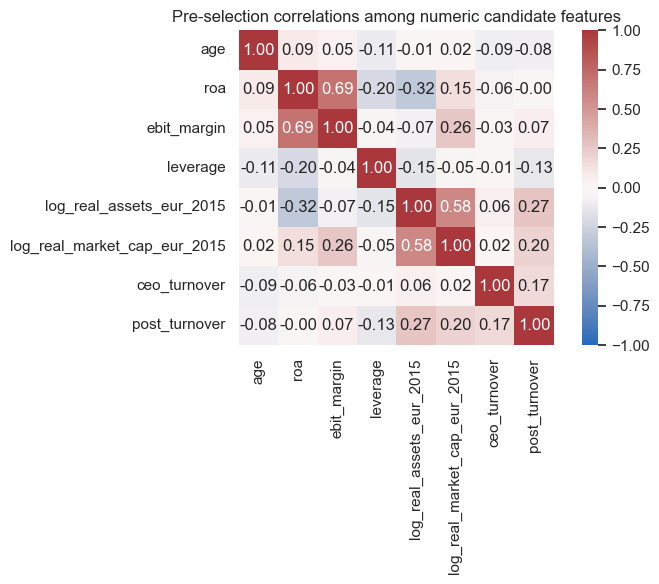

ML sample rows with non-missing target: 2,007
Numeric features: 6
Categorical features: 4


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/3718979554.py:96: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  feature_missingness["missing_pct"] = (


,missing,missing_pct
roa,94,4.68
age,3,0.15
leverage,1,0.05
log_real_assets_eur_2015,1,0.05
ceo_turnover,0,0.00
post_turnover,0,0.00
gender,0,0.00
hocountryname,0,0.00
sector,0,0.00
annualreportyear,0,0.00


,companyid,companyname,isin,directorid,directorname_emp,annualreportyear,age,roa,leverage,log_real_assets_eur_2015,ceo_turnover,post_turnover,gender,hocountryname,sector,log_w_real_pay
0,422.0,ABB LTD,CH0012221716,14884.0,Jörgen Centerman,2001,77,-0.004019,0.155918,10.558117,0,0,M,Switzerland,Engineering & Machinery,7.657364
1,422.0,ABB LTD,CH0012221716,11152.0,Juergen Dormann,2002,86,0.003284,0.182034,10.296252,1,1,M,Switzerland,Engineering & Machinery,7.367959
2,422.0,ABB LTD,CH0012221716,11152.0,Juergen Dormann,2003,86,0.002828,0.206819,10.135749,0,1,M,Switzerland,Engineering & Machinery,7.712021
3,422.0,ABB LTD,CH0012221716,11152.0,Juergen Dormann,2004,86,0.018155,0.198606,9.844118,0,1,M,Switzerland,Engineering & Machinery,7.946564
4,422.0,ABB LTD,CH0012221716,4611.0,Fred Kindle,2005,67,0.039639,0.176558,9.871334,1,1,M,Switzerland,Engineering & Machinery,6.977566


In [74]:
# -- 13.2.2  Model sample and feature lists ---------------------------------
# Keep identifiers for diagnostics only. They are not used as model predictors.

id_columns = [
    "companyid", "companyname", "isin", "directorid", "directorname_emp",
    "annualreportyear",
]

preselection_numeric_features = [
    "age",
    "roa",
    "ebit_margin",
    "leverage",
    "log_real_assets_eur_2015",
    "log_real_market_cap_eur_2015",
    "ceo_turnover",
    "post_turnover",
]

available_preselection_numeric_features = [
    col for col in preselection_numeric_features
    if col in df_panel_final.columns
]

preselection_corr = (
    df_panel_final.loc[
        df_panel_final[SUPERVISED_TARGET].notna(),
        available_preselection_numeric_features,
    ]
    .apply(pd.to_numeric, errors="coerce")
    .corr()
)

display(preselection_corr.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    preselection_corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Pre-selection correlations among numeric candidate features")
plt.tight_layout()
plt.show()

numeric_features = [
    "age",
    "roa",
    "leverage",
    "log_real_assets_eur_2015",
    "ceo_turnover",
    "post_turnover",
]

categorical_features = [
    "gender",
    "hocountryname",
    "sector",
    "annualreportyear",
]

candidate_columns = id_columns + numeric_features + categorical_features + [SUPERVISED_TARGET]
available_columns = list(dict.fromkeys(
    col for col in candidate_columns
    if col in df_panel_final.columns
))
missing_candidate_columns = [
    col for col in candidate_columns
    if col not in df_panel_final.columns
]
missing_candidate_columns = list(dict.fromkeys(missing_candidate_columns))

ml_sample = df_panel_final.loc[
    df_panel_final[SUPERVISED_TARGET].notna(),
    available_columns,
].copy()

# Keep only feature names that exist in the current panel.
id_columns = [col for col in id_columns if col in ml_sample.columns]
numeric_features = [col for col in numeric_features if col in ml_sample.columns]
categorical_features = [col for col in categorical_features if col in ml_sample.columns]
model_features = numeric_features + categorical_features

feature_missingness = (
    ml_sample[model_features]
    .isna()
    .sum()
    .to_frame("missing")
)
feature_missingness["missing_pct"] = (
    feature_missingness["missing"] / len(ml_sample) * 100
).round(2)
feature_missingness = feature_missingness.sort_values("missing_pct", ascending=False)

print(f"ML sample rows with non-missing target: {len(ml_sample):,}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

if missing_candidate_columns:
    print("Columns requested but unavailable:", missing_candidate_columns)

display(feature_missingness)
display(ml_sample.head())

#### 13.2.3 Train/Test Split

The model is evaluated with a time-based split. Earlier firm-year observations are used for training, and later observations are held out for testing. This better matches the practical prediction setting: use historical compensation data to predict compensation in later years.

Preprocessing is not fitted before this split. Imputation, scaling, and one-hot encoding will be learned only from the training data inside the modelling pipeline, then applied to the test data.

In [75]:
# -- 13.2.3  Time-based train/test split ------------------------------------

TEST_START_YEAR = 2020

ml_model_df = ml_sample.copy()
ml_model_df["annualreportyear"] = pd.to_numeric(
    ml_model_df["annualreportyear"],
    errors="coerce",
)
ml_model_df = ml_model_df.loc[ml_model_df["annualreportyear"].notna()].copy()
ml_model_df["annualreportyear"] = ml_model_df["annualreportyear"].astype(int)

train_df = ml_model_df.loc[ml_model_df["annualreportyear"] < TEST_START_YEAR].copy()
test_df = ml_model_df.loc[ml_model_df["annualreportyear"] >= TEST_START_YEAR].copy()

if train_df.empty or test_df.empty:
    raise ValueError(
        "The selected TEST_START_YEAR does not create both train and test samples. "
        "Choose a cutoff year inside the observed year range."
    )

# scikit-learn imputers expect missing values as np.nan, not pandas pd.NA.
X_train = train_df[model_features].copy().astype(object)
X_test = test_df[model_features].copy().astype(object)
X_train = X_train.where(pd.notna(X_train), np.nan)
X_test = X_test.where(pd.notna(X_test), np.nan)
y_train = train_df[SUPERVISED_TARGET].astype(float).copy()
y_test = test_df[SUPERVISED_TARGET].astype(float).copy()

split_summary = pd.DataFrame({
    "rows": [len(train_df), len(test_df)],
    "firms": [train_df["companyid"].nunique(), test_df["companyid"].nunique()],
    "first_year": [train_df["annualreportyear"].min(), test_df["annualreportyear"].min()],
    "last_year": [train_df["annualreportyear"].max(), test_df["annualreportyear"].max()],
    "target_mean": [y_train.mean(), y_test.mean()],
    "target_std": [y_train.std(), y_test.std()],
}, index=["train", "test"])

print(f"Test period starts in {TEST_START_YEAR}.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

display(split_summary.round(3))

Test period starts in 2020.
X_train shape: (1490, 10)
X_test shape : (517, 10)


/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288/1448175997.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ml_model_df["annualreportyear"] = pd.to_numeric(
/var/folders/wx/b_h8zt7d5ps2y7dhc2qj9pgc0000gn/T/ipykernel_74288

,rows,firms,first_year,last_year,target_mean,target_std
train,1490,127,2000,2019,7.532,0.676
test,517,119,2020,2024,7.582,0.659


#### 13.2.4 Preprocessing Pipeline: Imputation, Encoding, and Scaling

This subsection prepares the model inputs after the time-based train/test split. The target has already been separated, so the task here is only to make the feature matrix usable for scikit-learn models.

The preprocessing has three parts. First, missing numeric values are imputed and numeric features are scaled. Second, missing categorical values are imputed and categories are one-hot encoded. Third, both branches are combined with a `ColumnTransformer`, so each column type receives the right transformation.

The transformer is fitted on `X_train` only and then applied to both `X_train` and `X_test`. This preserves the forecasting logic of the split and avoids data leakage from the test period.

##### Encoding Categorical Features

The categorical predictors are `gender`, `hocountryname`, `sector`, and `annualreportyear`. These variables are labels, not continuous measurements, so we use one-hot encoding rather than assigning arbitrary numeric codes.

Before encoding, missing categories are filled with the most frequent training-set value. The encoder also ignores unknown categories, which is important for a time-based split because a country, sector, or year may appear in the test period even if it was not present in the training period.

In [76]:
categorical_imputer = SimpleImputer(strategy="most_frequent")
categorical_encoder = OneHotEncoder(handle_unknown="ignore")

categorical_transformer = Pipeline(steps=[
    ("imputer", categorical_imputer),
    ("onehot", categorical_encoder),
])

categorical_transformer


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto acc

##### Imputing and Scaling Numeric Features

The numeric predictors are median-imputed and then standardized. Median imputation is a conservative choice for financial variables because firm size, profitability, and leverage can be skewed.

After imputation, `StandardScaler` puts numeric features on a comparable scale. This matters most for linear and ridge regression, where coefficient size and regularization are affected by the units of the predictors.

In [77]:
numeric_imputer = SimpleImputer(strategy="median")
numeric_scaler = StandardScaler()

numeric_transformer = Pipeline(steps=[
    ("imputer", numeric_imputer),
    ("scaler", numeric_scaler),
])

numeric_transformer


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

##### Combining Steps with ColumnTransformer

The `ColumnTransformer` keeps the preprocessing rules explicit: numeric features go through the numeric pipeline, and categorical features go through the categorical pipeline.

This makes the workflow easier to inspect and safer to reuse in modelling. Later model pipelines can call the same `preprocessor` object, ensuring that every model receives the same cleaned and encoded feature matrix.

In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

##### Fitting the Preprocessor

We fit the preprocessing transformer before modelling so we can inspect the transformed design matrix. The fit is done on `X_train` only.

The fitted transformer is then used to transform both train and test features. The displayed shape summary shows how many columns the preprocessing creates, and the preview helps verify that scaling and one-hot encoding worked as expected.

In [79]:
# -- 13.2.4  Fit preprocessing transformer ----------------------------------

fitted_preprocessor = preprocessor.fit(X_train)

X_train_preprocessed = fitted_preprocessor.transform(X_train)
X_test_preprocessed = fitted_preprocessor.transform(X_test)

preprocessed_feature_names = fitted_preprocessor.get_feature_names_out()

preprocessed_shape_summary = pd.DataFrame({
    "rows": [X_train_preprocessed.shape[0], X_test_preprocessed.shape[0]],
    "features_after_preprocessing": [
        X_train_preprocessed.shape[1],
        X_test_preprocessed.shape[1],
    ],
}, index=["train", "test"])

display(preprocessed_shape_summary)

preview_values = X_train_preprocessed[:5]
if hasattr(preview_values, "toarray"):
    preview_values = preview_values.toarray()

preprocessed_preview = pd.DataFrame(
    preview_values,
    columns=preprocessed_feature_names,
    index=X_train.index[:5],
)

display(preprocessed_preview.round(3))


,rows,features_after_preprocessing
train,1490,75
test,517,75


,num__age,num__roa,num__leverage,num__log_real_assets_eur_2015,num__ceo_turnover,num__post_turnover,cat__gender_F,cat__gender_M,cat__hocountryname_Belgium,cat__hocountryname_Finland,cat__hocountryname_France,cat__hocountryname_Germany,cat__hocountryname_Isle Of Man,cat__hocountryname_Italy,cat__hocountryname_Jersey,cat__hocountryname_Luxembourg,cat__hocountryname_Netherlands,cat__hocountryname_Norway,cat__hocountryname_Republic Of Ireland,cat__hocountryname_Spain,cat__hocountryname_Sweden,cat__hocountryname_Switzerland,cat__hocountryname_United Kingdom - England,cat__sector_Aerospace & Defence,cat__sector_Automobiles & Parts,cat__sector_Banks,cat__sector_Beverages,cat__sector_Business Services,cat__sector_Chemicals,cat__sector_Clothing & Personal Products,cat__sector_Construction & Building Materials,cat__sector_Consumer Services,cat__sector_Diversified Industrials,cat__sector_Electricity,cat__sector_Electronic & Electrical Equipment,cat__sector_Engineering & Machinery,cat__sector_Food & Drug Retailers,cat__sector_Food Producers & Processors,cat__sector_General Retailers,cat__sector_Health,cat__sector_Household Products,cat__sector_Information Technology Hardware,cat__sector_Insurance,cat__sector_Leisure & Hotels,cat__sector_Media & Entertainment,cat__sector_Mining,cat__sector_Oil & Gas,cat__sector_Pharmaceuticals and Biotechnology,cat__sector_Real Estate,cat__sector_Software & Computer Services,cat__sector_Speciality & Other Finance,cat__sector_Steel & Other Metals,cat__sector_Telecommunication Services,cat__sector_Transport,cat__sector_Utilities - Other,cat__annualreportyear_2000,cat__annualreportyear_2001,cat__annualreportyear_2002,cat__annualreportyear_2003,cat__annualreportyear_2004,cat__annualreportyear_2005,cat__annualreportyear_2006,cat__annualreportyear_2007,cat__annualreportyear_2008,cat__annualreportyear_2009,cat__annualreportyear_2010,cat__annualreportyear_2011,cat__annualreportyear_2012,cat__annualreportyear_2013,cat__annualreportyear_2014,cat__annualreportyear_2015,cat__annualreportyear_2016,cat__annualreportyear_2017,cat__annualreportyear_2018,cat__annualreportyear_2019
0,0.927,-0.953,-0.151,-0.004,-0.367,-2.030,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.113,-0.808,0.092,-0.164,2.724,0.493,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.113,-0.817,0.323,-0.262,-0.367,0.493,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.113,-0.513,0.247,-0.441,-0.367,0.493,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.391,-0.087,0.041,-0.424,2.724,0.493,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [80]:
# -- 13.2.4b  Pay-dispersion sample and preprocessor -----------------------

DISP_TARGET = "log_pay_dispersion"

if DISP_TARGET not in df_panel_final.columns:
    print(f"Column '{DISP_TARGET}' not found – re-run Section 8.4 first.")
else:
    df_sl_disp = df_panel_final[df_panel_final[DISP_TARGET].notna()].copy()

    PAY_LEAK_COLS = {
        DISP_TARGET,
        "log_w_real_pay",
        "totalcompensation", "totalcompensation_eur",
        "log_totalcompensation_eur",
        "salary", "salary_eur",
        "bonus", "bonus_eur",
        "totaldirectcomp", "totaldirectcomp_eur",
        "perftotal",
        "real_salary_eur_2015", "real_bonus_eur_2015",
        "real_totalcompensation_eur_2015", "real_totaldirectcomp_eur_2015",
        "w_real_totalcompensation_eur_2015", "w_real_salary_eur_2015",
        "w_real_bonus_eur_2015",
        "log_real_totalcompensation_eur_2015",
        "lag_real_totalcompensation_eur_2015",
        "real_pay_change_eur_2015", "real_pay_change_pct", "log_real_pay_change",
        "median_exec_pay_eur", "pay_ratio", "w_pay_ratio", "n_exec_in_ratio",
        "ceo_turnover", "post_turnover",
    }

    disp_feature_cols = [c for c in df_sl_disp.columns if c not in PAY_LEAK_COLS]
    disp_num_cols = df_sl_disp[disp_feature_cols].select_dtypes(include="number").columns.tolist()
    disp_cat_cols = df_sl_disp[disp_feature_cols].select_dtypes(include="object").columns.tolist()

    disp_train_mask = df_sl_disp["annualreportyear"] < TEST_START_YEAR
    disp_test_mask  = df_sl_disp["annualreportyear"] >= TEST_START_YEAR

    X_disp_train = df_sl_disp.loc[disp_train_mask, disp_feature_cols]
    X_disp_test  = df_sl_disp.loc[disp_test_mask,  disp_feature_cols]
    y_disp_train = df_sl_disp.loc[disp_train_mask, DISP_TARGET]
    y_disp_test  = df_sl_disp.loc[disp_test_mask,  DISP_TARGET]

    disp_pre = ColumnTransformer([
        ("num", numeric_transformer, disp_num_cols),
        ("cat", categorical_transformer, disp_cat_cols),
    ])


#### 13.2.5 Modeling

The baseline and nonlinear models are grouped here so preprocessing and modelling stay conceptually separate. The cells below keep the existing model families, but the modelling subsection is otherwise left as a checkpoint for review before extending or tuning anything further.

#### 13.2.5b Initial Model Screening

We compare eight regression models using 5-fold cross-validation on the training set. MSE is the scoring metric because the target is on a log scale and large errors matter disproportionately.

Models cover the full plan: linear baselines (Linear Regression, Lasso), tree ensembles (Decision Tree, Random Forest), and boosting methods (XGBoost, LightGBM, AdaBoost, SGDRegressor). This is not the final tuned result — the goal is to identify which model families are promising before committing to hyperparameter search.

Models marked with `†` require `y.ravel()` to avoid sklearn shape warnings.

In [81]:
# ── 13.2.5b  7-model initial screening via 5-fold CV ────────────────────────
RANDOM_STATE = 654321

models = {
    "Linear Regression":      LinearRegression(),
    "Lasso":                  Lasso(alpha=0.01, max_iter=10000),
    "Light Gradient Boosting": lgb.LGBMRegressor(objective="regression", verbose=-1, random_state=RANDOM_STATE),
    "XGBoost":                xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    "Decision Tree":          DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest":          RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
}

models_ravel = {
    "SGDRegressor": SGDRegressor(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE),
    "AdaBoost":     AdaBoostRegressor(random_state=RANDOM_STATE),
}


def fit_and_evaluate_kfold(model, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kf)
    return -scores.mean(), scores.std()


screen_results = {}

for name, model in models.items():
    mean_mse, std_mse = fit_and_evaluate_kfold(model, X_train_preprocessed, y_train)
    screen_results[name] = {"MSE (mean)": mean_mse, "MSE (std)": std_mse}
    print(f"{name:30s}  MSE: {mean_mse:.4f} \u00b1 {std_mse:.4f}")

y_train_ravel = np.ravel(y_train)
for name, model in models_ravel.items():
    mean_mse, std_mse = fit_and_evaluate_kfold(model, X_train_preprocessed, y_train_ravel)
    screen_results[name] = {"MSE (mean)": mean_mse, "MSE (std)": std_mse}
    print(f"{name:30s}  MSE: {mean_mse:.4f} \u00b1 {std_mse:.4f}")

screen_df = (
    pd.DataFrame(screen_results).T
    .rename_axis("Model")
    .sort_values("MSE (mean)")
)
display(screen_df.round(4))


Linear Regression               MSE: 0.2996 ± 0.0128
Lasso                           MSE: 0.3566 ± 0.0098


/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/kajetan/Projects/TUdortmund/DAI/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Light Gradient Boosting         MSE: 0.2327 ± 0.0308


XGBoost                         MSE: 0.2299 ± 0.0183
Decision Tree                   MSE: 0.4248 ± 0.0563


Random Forest                   MSE: 0.2105 ± 0.0288
SGDRegressor                    MSE: 0.4422 ± 0.0327
AdaBoost                        MSE: 0.3701 ± 0.0246


,MSE (mean),MSE (std)
Model,,
Random Forest,0.2105,0.0288
XGBoost,0.2299,0.0183
Light Gradient Boosting,0.2327,0.0308
Linear Regression,0.2996,0.0128
Lasso,0.3566,0.0098
AdaBoost,0.3701,0.0246
Decision Tree,0.4248,0.0563
SGDRegressor,0.4422,0.0327


#### 13.2.5c XGBoost Hyperparameter Search (Optuna)

Random Forest and XGBoost are the two best-performing models in the initial screening. Both are tuned with Optuna: XGBoost here, Random Forest in 13.2.5d.

For XGBoost the search covers `learning_rate`, `n_estimators`, `max_depth`, `subsample`, and `colsample_bytree`. Each trial is scored with 5-fold CV MSE on the training set, and the study minimises that objective over 50 trials.

In [82]:
# ── 13.2.5c  XGBoost hyperparameter search with Optuna ──────────────────────
def xgb_objective(trial):
    params = {
        "objective":        "reg:squarederror",
        "booster":          "gbtree",
        "verbosity":        0,
        "random_state":     RANDOM_STATE,
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators":     trial.suggest_int("n_estimators", 50, 300),
        "max_depth":        trial.suggest_int("max_depth", 1, 10),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }
    model = xgb.XGBRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_preprocessed, y_train,
                             scoring="neg_mean_squared_error", cv=kf)
    return -scores.mean()

xgb_study = optuna.create_study(direction="minimize")
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print("Best XGBoost hyperparameters:")
for k, v in xgb_study.best_params.items():
    print(f"  {k}: {v}")
print(f"Best CV MSE: {xgb_study.best_value:.4f}")



  0%|          | 0/50 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.252875:   0%|          | 0/50 [00:01<?, ?it/s]


Best trial: 0. Best value: 0.252875:   2%|▏         | 1/50 [00:01<00:59,  1.22s/it]


Best trial: 1. Best value: 0.209843:   2%|▏         | 1/50 [00:02<00:59,  1.22s/it]


Best trial: 1. Best value: 0.209843:   4%|▍         | 2/50 [00:02<00:54,  1.14s/it]


Best trial: 1. Best value: 0.209843:   4%|▍         | 2/50 [00:03<00:54,  1.14s/it]


Best trial: 1. Best value: 0.209843:   6%|▌         | 3/50 [00:03<00:44,  1.06it/s]


Best trial: 1. Best value: 0.209843:   6%|▌         | 3/50 [00:04<00:44,  1.06it/s]


Best trial: 1. Best value: 0.209843:   8%|▊         | 4/50 [00:04<00:51,  1.13s/it]


Best trial: 1. Best value: 0.209843:   8%|▊         | 4/50 [00:04<00:51,  1.13s/it]


Best trial: 1. Best value: 0.209843:  10%|█         | 5/50 [00:04<00:41,  1.10it/s]


Best trial: 1. Best value: 0.209843:  10%|█         | 5/50 [00:06<00:41,  1.10it/s]


Best trial: 1. Best value: 0.209843:  12%|█▏        | 6/50 [00:06<00:52,  1.19s/it]


Best trial: 1. Best value: 0.209843:  12%|█▏        | 6/50 [00:07<00:52,  1.19s/it]


Best trial: 1. Best value: 0.209843:  14%|█▍        | 7/50 [00:07<00:39,  1.09it/s]


Best trial: 1. Best value: 0.209843:  14%|█▍        | 7/50 [00:07<00:39,  1.09it/s]


Best trial: 1. Best value: 0.209843:  16%|█▌        | 8/50 [00:07<00:30,  1.35it/s]


Best trial: 1. Best value: 0.209843:  16%|█▌        | 8/50 [00:07<00:30,  1.35it/s]


Best trial: 1. Best value: 0.209843:  18%|█▊        | 9/50 [00:07<00:22,  1.83it/s]


Best trial: 9. Best value: 0.208283:  18%|█▊        | 9/50 [00:09<00:22,  1.83it/s]


Best trial: 9. Best value: 0.208283:  20%|██        | 10/50 [00:09<00:37,  1.08it/s]


Best trial: 10. Best value: 0.207444:  20%|██        | 10/50 [00:12<00:37,  1.08it/s]


Best trial: 10. Best value: 0.207444:  22%|██▏       | 11/50 [00:12<00:57,  1.48s/it]


Best trial: 11. Best value: 0.207261:  22%|██▏       | 11/50 [00:14<00:57,  1.48s/it]


Best trial: 11. Best value: 0.207261:  24%|██▍       | 12/50 [00:14<01:11,  1.87s/it]


Best trial: 12. Best value: 0.207094:  24%|██▍       | 12/50 [00:17<01:11,  1.87s/it]


Best trial: 12. Best value: 0.207094:  26%|██▌       | 13/50 [00:17<01:19,  2.14s/it]


Best trial: 13. Best value: 0.205215:  26%|██▌       | 13/50 [00:20<01:19,  2.14s/it]


Best trial: 13. Best value: 0.205215:  28%|██▊       | 14/50 [00:20<01:23,  2.32s/it]


Best trial: 14. Best value: 0.203216:  28%|██▊       | 14/50 [00:22<01:23,  2.32s/it]


Best trial: 14. Best value: 0.203216:  30%|███       | 15/50 [00:22<01:20,  2.30s/it]


Best trial: 15. Best value: 0.200286:  30%|███       | 15/50 [00:24<01:20,  2.30s/it]


Best trial: 15. Best value: 0.200286:  32%|███▏      | 16/50 [00:24<01:14,  2.19s/it]


Best trial: 15. Best value: 0.200286:  32%|███▏      | 16/50 [00:26<01:14,  2.19s/it]


Best trial: 15. Best value: 0.200286:  34%|███▍      | 17/50 [00:26<01:08,  2.08s/it]


Best trial: 15. Best value: 0.200286:  34%|███▍      | 17/50 [00:27<01:08,  2.08s/it]


Best trial: 15. Best value: 0.200286:  36%|███▌      | 18/50 [00:27<00:58,  1.83s/it]


Best trial: 15. Best value: 0.200286:  36%|███▌      | 18/50 [00:28<00:58,  1.83s/it]


Best trial: 15. Best value: 0.200286:  38%|███▊      | 19/50 [00:28<00:51,  1.65s/it]


Best trial: 15. Best value: 0.200286:  38%|███▊      | 19/50 [00:30<00:51,  1.65s/it]


Best trial: 15. Best value: 0.200286:  40%|████      | 20/50 [00:30<00:50,  1.67s/it]


Best trial: 15. Best value: 0.200286:  40%|████      | 20/50 [00:32<00:50,  1.67s/it]


Best trial: 15. Best value: 0.200286:  42%|████▏     | 21/50 [00:32<00:49,  1.71s/it]


Best trial: 15. Best value: 0.200286:  42%|████▏     | 21/50 [00:33<00:49,  1.71s/it]


Best trial: 15. Best value: 0.200286:  44%|████▍     | 22/50 [00:33<00:44,  1.59s/it]


Best trial: 15. Best value: 0.200286:  44%|████▍     | 22/50 [00:34<00:44,  1.59s/it]


Best trial: 15. Best value: 0.200286:  46%|████▌     | 23/50 [00:34<00:40,  1.50s/it]


Best trial: 15. Best value: 0.200286:  46%|████▌     | 23/50 [00:36<00:40,  1.50s/it]


Best trial: 15. Best value: 0.200286:  48%|████▊     | 24/50 [00:36<00:41,  1.59s/it]


Best trial: 15. Best value: 0.200286:  48%|████▊     | 24/50 [00:38<00:41,  1.59s/it]


Best trial: 15. Best value: 0.200286:  50%|█████     | 25/50 [00:38<00:38,  1.56s/it]


Best trial: 15. Best value: 0.200286:  50%|█████     | 25/50 [00:40<00:38,  1.56s/it]


Best trial: 15. Best value: 0.200286:  52%|█████▏    | 26/50 [00:40<00:43,  1.80s/it]


Best trial: 15. Best value: 0.200286:  52%|█████▏    | 26/50 [00:41<00:43,  1.80s/it]


Best trial: 15. Best value: 0.200286:  54%|█████▍    | 27/50 [00:41<00:38,  1.67s/it]


Best trial: 15. Best value: 0.200286:  54%|█████▍    | 27/50 [00:43<00:38,  1.67s/it]


Best trial: 15. Best value: 0.200286:  56%|█████▌    | 28/50 [00:43<00:34,  1.56s/it]


Best trial: 15. Best value: 0.200286:  56%|█████▌    | 28/50 [00:44<00:34,  1.56s/it]


Best trial: 15. Best value: 0.200286:  58%|█████▊    | 29/50 [00:44<00:32,  1.55s/it]


Best trial: 15. Best value: 0.200286:  58%|█████▊    | 29/50 [00:45<00:32,  1.55s/it]


Best trial: 15. Best value: 0.200286:  60%|██████    | 30/50 [00:45<00:26,  1.33s/it]


Best trial: 15. Best value: 0.200286:  60%|██████    | 30/50 [00:47<00:26,  1.33s/it]


Best trial: 15. Best value: 0.200286:  62%|██████▏   | 31/50 [00:47<00:26,  1.37s/it]


Best trial: 15. Best value: 0.200286:  62%|██████▏   | 31/50 [00:48<00:26,  1.37s/it]


Best trial: 15. Best value: 0.200286:  64%|██████▍   | 32/50 [00:48<00:27,  1.50s/it]


Best trial: 15. Best value: 0.200286:  64%|██████▍   | 32/50 [00:50<00:27,  1.50s/it]


Best trial: 15. Best value: 0.200286:  66%|██████▌   | 33/50 [00:50<00:24,  1.47s/it]


Best trial: 15. Best value: 0.200286:  66%|██████▌   | 33/50 [00:51<00:24,  1.47s/it]


Best trial: 15. Best value: 0.200286:  68%|██████▊   | 34/50 [00:51<00:24,  1.52s/it]


Best trial: 15. Best value: 0.200286:  68%|██████▊   | 34/50 [00:52<00:24,  1.52s/it]


Best trial: 15. Best value: 0.200286:  70%|███████   | 35/50 [00:52<00:20,  1.38s/it]


Best trial: 15. Best value: 0.200286:  70%|███████   | 35/50 [00:55<00:20,  1.38s/it]


Best trial: 15. Best value: 0.200286:  72%|███████▏  | 36/50 [00:55<00:23,  1.68s/it]


Best trial: 15. Best value: 0.200286:  72%|███████▏  | 36/50 [00:56<00:23,  1.68s/it]


Best trial: 15. Best value: 0.200286:  74%|███████▍  | 37/50 [00:56<00:20,  1.61s/it]


Best trial: 15. Best value: 0.200286:  74%|███████▍  | 37/50 [00:57<00:20,  1.61s/it]


Best trial: 15. Best value: 0.200286:  76%|███████▌  | 38/50 [00:57<00:16,  1.37s/it]


Best trial: 15. Best value: 0.200286:  76%|███████▌  | 38/50 [00:58<00:16,  1.37s/it]


Best trial: 15. Best value: 0.200286:  78%|███████▊  | 39/50 [00:58<00:13,  1.22s/it]


Best trial: 15. Best value: 0.200286:  78%|███████▊  | 39/50 [00:59<00:13,  1.22s/it]


Best trial: 15. Best value: 0.200286:  80%|████████  | 40/50 [00:59<00:12,  1.27s/it]


Best trial: 15. Best value: 0.200286:  80%|████████  | 40/50 [01:01<00:12,  1.27s/it]


Best trial: 15. Best value: 0.200286:  82%|████████▏ | 41/50 [01:01<00:12,  1.43s/it]


Best trial: 15. Best value: 0.200286:  82%|████████▏ | 41/50 [01:03<00:12,  1.43s/it]


Best trial: 15. Best value: 0.200286:  84%|████████▍ | 42/50 [01:03<00:12,  1.54s/it]


Best trial: 15. Best value: 0.200286:  84%|████████▍ | 42/50 [01:05<00:12,  1.54s/it]


Best trial: 15. Best value: 0.200286:  86%|████████▌ | 43/50 [01:05<00:11,  1.71s/it]


Best trial: 15. Best value: 0.200286:  86%|████████▌ | 43/50 [01:07<00:11,  1.71s/it]


Best trial: 15. Best value: 0.200286:  88%|████████▊ | 44/50 [01:07<00:10,  1.78s/it]


Best trial: 15. Best value: 0.200286:  88%|████████▊ | 44/50 [01:08<00:10,  1.78s/it]


Best trial: 15. Best value: 0.200286:  90%|█████████ | 45/50 [01:08<00:08,  1.69s/it]


Best trial: 15. Best value: 0.200286:  90%|█████████ | 45/50 [01:09<00:08,  1.69s/it]


Best trial: 15. Best value: 0.200286:  92%|█████████▏| 46/50 [01:09<00:04,  1.24s/it]


Best trial: 15. Best value: 0.200286:  92%|█████████▏| 46/50 [01:11<00:04,  1.24s/it]


Best trial: 15. Best value: 0.200286:  94%|█████████▍| 47/50 [01:11<00:04,  1.52s/it]


Best trial: 15. Best value: 0.200286:  94%|█████████▍| 47/50 [01:13<00:04,  1.52s/it]


Best trial: 15. Best value: 0.200286:  96%|█████████▌| 48/50 [01:13<00:03,  1.58s/it]


Best trial: 15. Best value: 0.200286:  96%|█████████▌| 48/50 [01:15<00:03,  1.58s/it]


Best trial: 15. Best value: 0.200286:  98%|█████████▊| 49/50 [01:15<00:01,  1.81s/it]


Best trial: 15. Best value: 0.200286:  98%|█████████▊| 49/50 [01:17<00:01,  1.81s/it]


Best trial: 15. Best value: 0.200286: 100%|██████████| 50/50 [01:17<00:00,  2.01s/it]


Best trial: 15. Best value: 0.200286: 100%|██████████| 50/50 [01:17<00:00,  1.56s/it]

Best XGBoost hyperparameters:
  learning_rate: 0.15362479585485397
  n_estimators: 259
  max_depth: 8
  subsample: 0.8558848994793673
  colsample_bytree: 0.597292036431855
Best CV MSE: 0.2003


#### 13.2.5e Final Evaluation on Test Set

We retrain both tuned models (XGBoost and Random Forest) on the full training set using the best hyperparameters found by Optuna, then evaluate on the held-out test period (2020 onwards). RidgeCV serves as the linear baseline.

#### 13.2.5d Random Forest Hyperparameter Search (Optuna)

Random Forest led the untuned screening (MSE 0.210 vs XGBoost 0.230). We tune `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_features` over 50 trials using the same 5-fold CV MSE objective.

In [83]:
# ── 13.2.5d  Random Forest hyperparameter search with Optuna ────────────────
def rf_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 500),
        "max_depth":         trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.7]),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    model = RandomForestRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_preprocessed, y_train,
                             scoring="neg_mean_squared_error", cv=kf)
    return -scores.mean()

rf_study = optuna.create_study(direction="minimize")
rf_study.optimize(rf_objective, n_trials=50, show_progress_bar=True)

print("Best Random Forest hyperparameters:")
for k, v in rf_study.best_params.items():
    print(f"  {k}: {v}")
print(f"Best CV MSE: {rf_study.best_value:.4f}")



  0%|          | 0/50 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.370627:   0%|          | 0/50 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.370627:   2%|▏         | 1/50 [00:00<00:19,  2.55it/s]


Best trial: 1. Best value: 0.341403:   2%|▏         | 1/50 [00:00<00:19,  2.55it/s]


Best trial: 1. Best value: 0.341403:   4%|▍         | 2/50 [00:00<00:18,  2.65it/s]


Best trial: 1. Best value: 0.341403:   4%|▍         | 2/50 [00:00<00:18,  2.65it/s]


Best trial: 1. Best value: 0.341403:   6%|▌         | 3/50 [00:00<00:14,  3.26it/s]


Best trial: 3. Best value: 0.303539:   6%|▌         | 3/50 [00:01<00:14,  3.26it/s]


Best trial: 3. Best value: 0.303539:   8%|▊         | 4/50 [00:01<00:22,  2.06it/s]


Best trial: 3. Best value: 0.303539:   8%|▊         | 4/50 [00:02<00:22,  2.06it/s]


Best trial: 3. Best value: 0.303539:  10%|█         | 5/50 [00:02<00:27,  1.66it/s]


Best trial: 3. Best value: 0.303539:  10%|█         | 5/50 [00:03<00:27,  1.66it/s]


Best trial: 3. Best value: 0.303539:  12%|█▏        | 6/50 [00:03<00:31,  1.41it/s]


Best trial: 6. Best value: 0.23161:  12%|█▏        | 6/50 [00:04<00:31,  1.41it/s] 


Best trial: 6. Best value: 0.23161:  14%|█▍        | 7/50 [00:04<00:35,  1.22it/s]


Best trial: 6. Best value: 0.23161:  14%|█▍        | 7/50 [00:04<00:35,  1.22it/s]


Best trial: 6. Best value: 0.23161:  16%|█▌        | 8/50 [00:04<00:29,  1.44it/s]


Best trial: 6. Best value: 0.23161:  16%|█▌        | 8/50 [00:05<00:29,  1.44it/s]


Best trial: 6. Best value: 0.23161:  18%|█▊        | 9/50 [00:05<00:26,  1.56it/s]


Best trial: 6. Best value: 0.23161:  18%|█▊        | 9/50 [00:06<00:26,  1.56it/s]


Best trial: 6. Best value: 0.23161:  20%|██        | 10/50 [00:06<00:32,  1.24it/s]


Best trial: 10. Best value: 0.214162:  20%|██        | 10/50 [00:07<00:32,  1.24it/s]


Best trial: 10. Best value: 0.214162:  22%|██▏       | 11/50 [00:07<00:36,  1.07it/s]


Best trial: 11. Best value: 0.214131:  22%|██▏       | 11/50 [00:09<00:36,  1.07it/s]


Best trial: 11. Best value: 0.214131:  24%|██▍       | 12/50 [00:09<00:37,  1.00it/s]


Best trial: 12. Best value: 0.208005:  24%|██▍       | 12/50 [00:10<00:37,  1.00it/s]


Best trial: 12. Best value: 0.208005:  26%|██▌       | 13/50 [00:10<00:43,  1.16s/it]


Best trial: 12. Best value: 0.208005:  26%|██▌       | 13/50 [00:12<00:43,  1.16s/it]


Best trial: 12. Best value: 0.208005:  28%|██▊       | 14/50 [00:12<00:46,  1.28s/it]


Best trial: 12. Best value: 0.208005:  28%|██▊       | 14/50 [00:13<00:46,  1.28s/it]


Best trial: 12. Best value: 0.208005:  30%|███       | 15/50 [00:13<00:41,  1.18s/it]


Best trial: 12. Best value: 0.208005:  30%|███       | 15/50 [00:13<00:41,  1.18s/it]


Best trial: 12. Best value: 0.208005:  32%|███▏      | 16/50 [00:13<00:37,  1.09s/it]


Best trial: 12. Best value: 0.208005:  32%|███▏      | 16/50 [00:14<00:37,  1.09s/it]


Best trial: 12. Best value: 0.208005:  34%|███▍      | 17/50 [00:14<00:33,  1.00s/it]


Best trial: 12. Best value: 0.208005:  34%|███▍      | 17/50 [00:15<00:33,  1.00s/it]


Best trial: 12. Best value: 0.208005:  36%|███▌      | 18/50 [00:15<00:33,  1.04s/it]


Best trial: 12. Best value: 0.208005:  36%|███▌      | 18/50 [00:16<00:33,  1.04s/it]


Best trial: 12. Best value: 0.208005:  38%|███▊      | 19/50 [00:16<00:26,  1.18it/s]


Best trial: 12. Best value: 0.208005:  38%|███▊      | 19/50 [00:17<00:26,  1.18it/s]


Best trial: 12. Best value: 0.208005:  40%|████      | 20/50 [00:17<00:27,  1.08it/s]


Best trial: 12. Best value: 0.208005:  40%|████      | 20/50 [00:18<00:27,  1.08it/s]


Best trial: 12. Best value: 0.208005:  42%|████▏     | 21/50 [00:18<00:24,  1.19it/s]


Best trial: 12. Best value: 0.208005:  42%|████▏     | 21/50 [00:19<00:24,  1.19it/s]


Best trial: 12. Best value: 0.208005:  44%|████▍     | 22/50 [00:19<00:27,  1.03it/s]


Best trial: 12. Best value: 0.208005:  44%|████▍     | 22/50 [00:20<00:27,  1.03it/s]


Best trial: 12. Best value: 0.208005:  46%|████▌     | 23/50 [00:20<00:30,  1.12s/it]


Best trial: 12. Best value: 0.208005:  46%|████▌     | 23/50 [00:21<00:30,  1.12s/it]


Best trial: 12. Best value: 0.208005:  48%|████▊     | 24/50 [00:21<00:29,  1.12s/it]


Best trial: 12. Best value: 0.208005:  48%|████▊     | 24/50 [00:22<00:29,  1.12s/it]


Best trial: 12. Best value: 0.208005:  50%|█████     | 25/50 [00:22<00:26,  1.07s/it]


Best trial: 12. Best value: 0.208005:  50%|█████     | 25/50 [00:23<00:26,  1.07s/it]


Best trial: 12. Best value: 0.208005:  52%|█████▏    | 26/50 [00:23<00:24,  1.01s/it]


Best trial: 12. Best value: 0.208005:  52%|█████▏    | 26/50 [00:24<00:24,  1.01s/it]


Best trial: 12. Best value: 0.208005:  54%|█████▍    | 27/50 [00:24<00:24,  1.06s/it]


Best trial: 12. Best value: 0.208005:  54%|█████▍    | 27/50 [00:26<00:24,  1.06s/it]


Best trial: 12. Best value: 0.208005:  56%|█████▌    | 28/50 [00:26<00:24,  1.10s/it]


Best trial: 12. Best value: 0.208005:  56%|█████▌    | 28/50 [00:27<00:24,  1.10s/it]


Best trial: 12. Best value: 0.208005:  58%|█████▊    | 29/50 [00:27<00:23,  1.13s/it]


Best trial: 12. Best value: 0.208005:  58%|█████▊    | 29/50 [00:27<00:23,  1.13s/it]


Best trial: 12. Best value: 0.208005:  60%|██████    | 30/50 [00:27<00:18,  1.06it/s]


Best trial: 12. Best value: 0.208005:  60%|██████    | 30/50 [00:28<00:18,  1.06it/s]


Best trial: 12. Best value: 0.208005:  62%|██████▏   | 31/50 [00:28<00:15,  1.19it/s]


Best trial: 12. Best value: 0.208005:  62%|██████▏   | 31/50 [00:29<00:15,  1.19it/s]


Best trial: 12. Best value: 0.208005:  64%|██████▍   | 32/50 [00:29<00:17,  1.05it/s]


Best trial: 12. Best value: 0.208005:  64%|██████▍   | 32/50 [00:30<00:17,  1.05it/s]


Best trial: 12. Best value: 0.208005:  66%|██████▌   | 33/50 [00:30<00:15,  1.12it/s]


Best trial: 12. Best value: 0.208005:  66%|██████▌   | 33/50 [00:31<00:15,  1.12it/s]


Best trial: 12. Best value: 0.208005:  68%|██████▊   | 34/50 [00:31<00:14,  1.11it/s]


Best trial: 12. Best value: 0.208005:  68%|██████▊   | 34/50 [00:32<00:14,  1.11it/s]


Best trial: 12. Best value: 0.208005:  70%|███████   | 35/50 [00:32<00:15,  1.02s/it]


Best trial: 12. Best value: 0.208005:  70%|███████   | 35/50 [00:33<00:15,  1.02s/it]


Best trial: 12. Best value: 0.208005:  72%|███████▏  | 36/50 [00:33<00:14,  1.04s/it]


Best trial: 12. Best value: 0.208005:  72%|███████▏  | 36/50 [00:33<00:14,  1.04s/it]


Best trial: 12. Best value: 0.208005:  74%|███████▍  | 37/50 [00:33<00:10,  1.22it/s]


Best trial: 12. Best value: 0.208005:  74%|███████▍  | 37/50 [00:35<00:10,  1.22it/s]


Best trial: 12. Best value: 0.208005:  76%|███████▌  | 38/50 [00:35<00:10,  1.09it/s]


Best trial: 12. Best value: 0.208005:  76%|███████▌  | 38/50 [00:35<00:10,  1.09it/s]


Best trial: 12. Best value: 0.208005:  78%|███████▊  | 39/50 [00:35<00:09,  1.20it/s]


Best trial: 12. Best value: 0.208005:  78%|███████▊  | 39/50 [00:36<00:09,  1.20it/s]


Best trial: 12. Best value: 0.208005:  80%|████████  | 40/50 [00:36<00:07,  1.39it/s]


Best trial: 12. Best value: 0.208005:  80%|████████  | 40/50 [00:37<00:07,  1.39it/s]


Best trial: 12. Best value: 0.208005:  82%|████████▏ | 41/50 [00:37<00:06,  1.34it/s]


Best trial: 12. Best value: 0.208005:  82%|████████▏ | 41/50 [00:38<00:06,  1.34it/s]


Best trial: 12. Best value: 0.208005:  84%|████████▍ | 42/50 [00:38<00:06,  1.17it/s]


Best trial: 12. Best value: 0.208005:  84%|████████▍ | 42/50 [00:39<00:06,  1.17it/s]


Best trial: 12. Best value: 0.208005:  86%|████████▌ | 43/50 [00:39<00:07,  1.01s/it]


Best trial: 12. Best value: 0.208005:  86%|████████▌ | 43/50 [00:40<00:07,  1.01s/it]


Best trial: 12. Best value: 0.208005:  88%|████████▊ | 44/50 [00:40<00:06,  1.11s/it]


Best trial: 12. Best value: 0.208005:  88%|████████▊ | 44/50 [00:42<00:06,  1.11s/it]


Best trial: 12. Best value: 0.208005:  90%|█████████ | 45/50 [00:42<00:06,  1.26s/it]


Best trial: 12. Best value: 0.208005:  90%|█████████ | 45/50 [00:43<00:06,  1.26s/it]


Best trial: 12. Best value: 0.208005:  92%|█████████▏| 46/50 [00:43<00:05,  1.33s/it]


Best trial: 12. Best value: 0.208005:  92%|█████████▏| 46/50 [00:45<00:05,  1.33s/it]


Best trial: 12. Best value: 0.208005:  94%|█████████▍| 47/50 [00:45<00:04,  1.37s/it]


Best trial: 12. Best value: 0.208005:  94%|█████████▍| 47/50 [00:46<00:04,  1.37s/it]


Best trial: 12. Best value: 0.208005:  96%|█████████▌| 48/50 [00:46<00:02,  1.29s/it]


Best trial: 12. Best value: 0.208005:  96%|█████████▌| 48/50 [00:47<00:02,  1.29s/it]


Best trial: 12. Best value: 0.208005:  98%|█████████▊| 49/50 [00:47<00:01,  1.29s/it]


Best trial: 12. Best value: 0.208005:  98%|█████████▊| 49/50 [00:48<00:01,  1.29s/it]


Best trial: 12. Best value: 0.208005: 100%|██████████| 50/50 [00:48<00:00,  1.20s/it]


Best trial: 12. Best value: 0.208005: 100%|██████████| 50/50 [00:48<00:00,  1.03it/s]

Best Random Forest hyperparameters:
  n_estimators: 404
  max_depth: 20
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: 0.7
Best CV MSE: 0.2080


In [84]:
# ── 13.2.5e  Final test-set evaluation ──────────────────────────────────────
from sklearn.linear_model import Ridge, RidgeCV

# Linear baseline
ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5, scoring="r2")
ridge.fit(X_train_preprocessed, y_train)
ridge_pred = ridge.predict(X_test_preprocessed)

# Tuned XGBoost
best_xgb = xgb.XGBRegressor(
    **xgb_study.best_params,
    objective="reg:squarederror",
    verbosity=0,
    random_state=RANDOM_STATE,
)
best_xgb.fit(X_train_preprocessed, y_train)
xgb_pred = best_xgb.predict(X_test_preprocessed)

# Tuned Random Forest
best_rf = RandomForestRegressor(
    **rf_study.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
best_rf.fit(X_train_preprocessed, y_train)
rf_pred = best_rf.predict(X_test_preprocessed)


def eval_row(name, y_true, y_pred):
    return {
        "Model": name,
        "R²":   r2_score(y_true, y_pred),
        "RMSE":  np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE":   mean_squared_error(y_true, y_pred),
        "MAE":   mean_absolute_error(y_true, y_pred),
    }

final_results = pd.DataFrame([
    eval_row("Ridge (baseline)",      y_test, ridge_pred),
    eval_row("XGBoost (tuned)",       y_test, xgb_pred),
    eval_row("Random Forest (tuned)", y_test, rf_pred),
]).set_index("Model").sort_values("R²", ascending=False)

print("Test-set performance:")
display(final_results.round(4))


Test-set performance:


,R²,RMSE,MSE,MAE
Model,,,,
Random Forest (tuned),0.3785,0.5192,0.2696,0.3625
XGBoost (tuned),0.3103,0.5469,0.2991,0.3986
Ridge (baseline),0.2921,0.5541,0.3071,0.4147


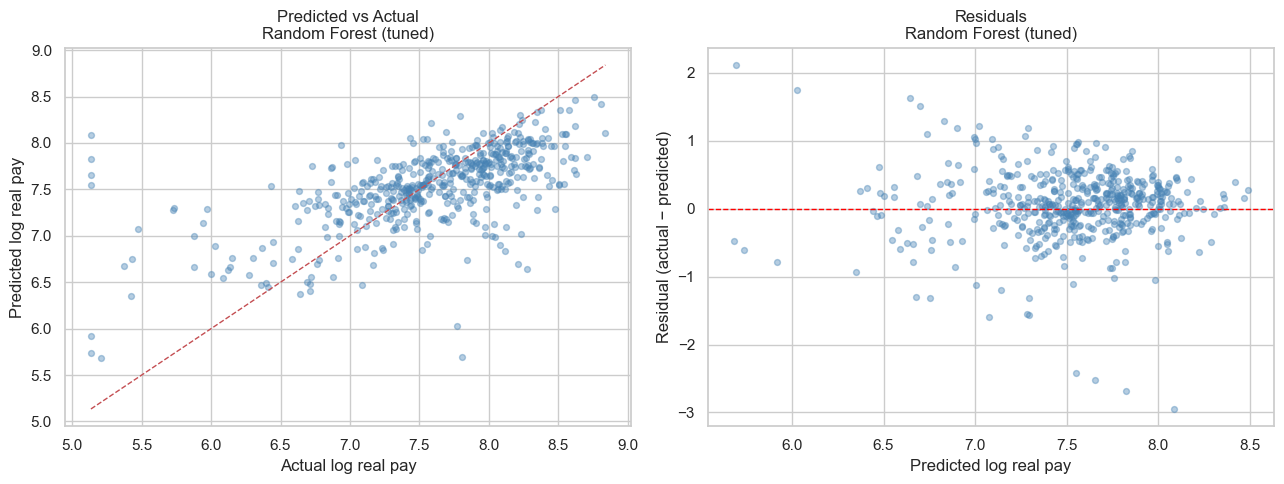

In [85]:
# ── 13.2.5f  Predicted vs actual and residual diagnostics ───────────────────
preds_map = {
    "Ridge (baseline)":      ridge_pred,
    "XGBoost (tuned)":       xgb_pred,
    "Random Forest (tuned)": rf_pred,
}
best_name = final_results.index[0]
best_pred = preds_map[best_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_test, best_pred, alpha=0.4, s=18, color="steelblue")
lo = min(float(y_test.min()), float(best_pred.min()))
hi = max(float(y_test.max()), float(best_pred.max()))
ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
ax.set_xlabel("Actual log real pay")
ax.set_ylabel("Predicted log real pay")
ax.set_title(f"Predicted vs Actual\n{best_name}")

ax = axes[1]
residuals = y_test.values - best_pred
ax.scatter(best_pred, residuals, alpha=0.4, s=18, color="steelblue")
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted log real pay")
ax.set_ylabel("Residual (actual − predicted)")
ax.set_title(f"Residuals\n{best_name}")

plt.tight_layout()
plt.show()


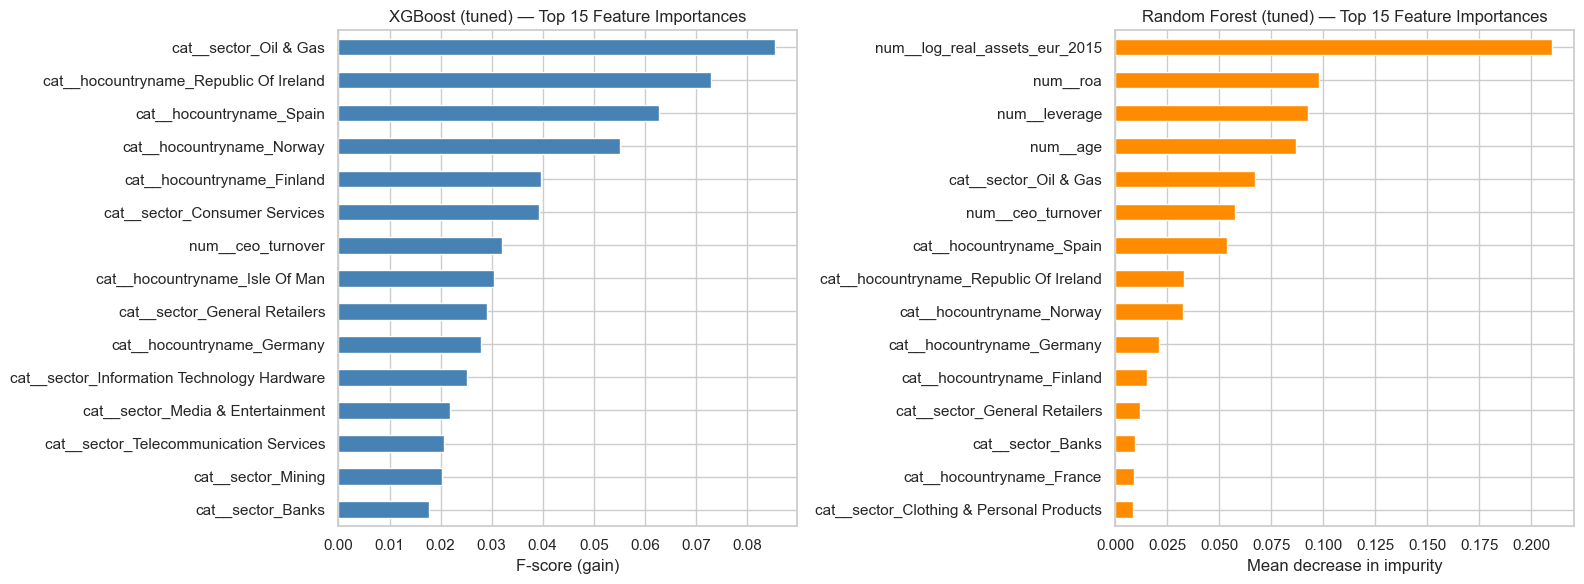

In [86]:
# ── 13.2.5g  Feature importance ─────────────────────────────────────────────
feat_names = list(preprocessed_feature_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xgb_imp = pd.Series(best_xgb.feature_importances_, index=feat_names)
xgb_imp.nlargest(15).sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("XGBoost (tuned) — Top 15 Feature Importances")
axes[0].set_xlabel("F-score (gain)")

rf_imp = pd.Series(best_rf.feature_importances_, index=feat_names)
rf_imp.nlargest(15).sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Random Forest (tuned) — Top 15 Feature Importances")
axes[1].set_xlabel("Mean decrease in impurity")

plt.tight_layout()
plt.show()


#### Insights

- **Initial screening** covers linear baselines (Linear Regression, Lasso), tree ensembles (Decision Tree, Random Forest), and boosting methods (XGBoost, LightGBM, AdaBoost, SGDRegressor). Random Forest leads untuned; XGBoost has lower variance.
- **Optuna** tunes both Random Forest and XGBoost over 50 trials each using 5-fold CV MSE, letting the test set decide which wins after tuning.
- **Final test-set comparison** reports R², RMSE, MSE, and MAE for RidgeCV, tuned XGBoost, and tuned Random Forest.
- **Residual plot**: a fan shape at high predicted values would indicate that log-transformation has not fully stabilised variance in the upper pay range.
- **Feature importance**: firm size (`log_real_assets`) and year dummies typically dominate; `ceo_turnover` and `post_turnover` reveal governance-pay effects beyond firm-size controls. Side-by-side plots compare XGBoost gain vs. RF mean decrease in impurity.

#### 13.2.6 XGBoost Classification + Logistic Regression Baseline: Predicting CEO Turnover

Beyond predicting pay levels, we ask whether observable firm and executive characteristics predict *whether* a CEO turnover will occur. This is a binary classification task with `ceo_turnover` as the outcome.

The feature set excludes `ceo_turnover` and `post_turnover` to avoid leakage. The same time-based split is used (train before 2020, test from 2020).

Two models are compared:
- **Logistic Regression** with `class_weight='balanced'` — a linear, interpretable baseline that natively handles imbalance through cost-sensitive weighting
- **XGBoost** with `scale_pos_weight` — a nonlinear boosting model that captures interactions the linear model cannot

Both models use a decision threshold set via **Youden's J** on the training set rather than the default 0.5. Evaluation uses three imbalance-aware measures: **Balanced Accuracy**, **MCC**, and **Average Precision (PR-AUC)**.

Chance baseline — Avg Precision ≈ 0.12  |  Balanced Accuracy = 0.50  |  MCC = 0



,ROC-AUC,Avg Precision,Balanced Accuracy,MCC
Model,,,,
Logistic Regression,0.611,0.163,0.566,0.100
XGBoost,0.603,0.151,0.556,0.071



Logistic Regression  (threshold = 0.536)
              precision    recall  f1-score   support

 No Turnover       0.95      0.24      0.38       459
    Turnover       0.13      0.90      0.23        58

    accuracy                           0.31       517
   macro avg       0.54      0.57      0.30       517
weighted avg       0.86      0.31      0.36       517

XGBoost  (threshold = 0.584)
              precision    recall  f1-score   support

 No Turnover       0.91      0.56      0.69       459
    Turnover       0.14      0.55      0.22        58

    accuracy                           0.56       517
   macro avg       0.52      0.56      0.46       517
weighted avg       0.82      0.56      0.64       517



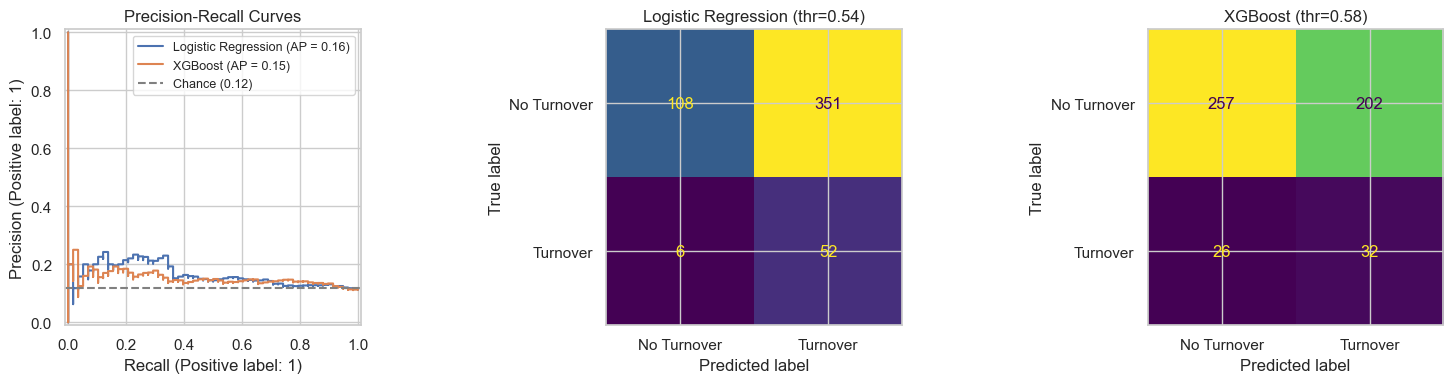

In [87]:
# ── 13.2.6  XGBoost Classification + Logistic Regression baseline ────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef,
    roc_curve, PrecisionRecallDisplay, ConfusionMatrixDisplay,
)

CLF_TARGET = "ceo_turnover"

# Exclude the turnover indicator and its post-event flag to avoid leakage
clf_numeric_features = [f for f in numeric_features if f not in {CLF_TARGET, "post_turnover"}]
clf_categorical_features = categorical_features.copy()

clf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, clf_numeric_features),
        ("cat", categorical_transformer, clf_categorical_features),
    ],
    remainder="drop",
)

X_train_clf = train_df[clf_numeric_features + clf_categorical_features].copy().astype(object)
X_test_clf  = test_df[clf_numeric_features  + clf_categorical_features].copy().astype(object)
X_train_clf = X_train_clf.where(pd.notna(X_train_clf), np.nan)
X_test_clf  = X_test_clf.where(pd.notna(X_test_clf),   np.nan)

y_train_clf = train_df[CLF_TARGET].fillna(0).astype(int)
y_test_clf  = test_df[CLF_TARGET].fillna(0).astype(int)

X_train_clf_prep = clf_preprocessor.fit_transform(X_train_clf)
X_test_clf_prep  = clf_preprocessor.transform(X_test_clf)

neg, pos = (y_train_clf == 0).sum(), (y_train_clf == 1).sum()
spw = neg / pos if pos > 0 else 1.0


def youden_threshold(model, X_train, y_train):
    """Find the decision threshold that maximises Youden's J on the training set."""
    fpr, tpr, thresholds = roc_curve(y_train, model.predict_proba(X_train)[:, 1])
    return thresholds[np.argmax(tpr - fpr)]


# ── Logistic Regression baseline (class_weight='balanced' handles imbalance) ─
lr_clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
lr_clf.fit(X_train_clf_prep, y_train_clf)
lr_threshold = youden_threshold(lr_clf, X_train_clf_prep, y_train_clf)
lr_prob = lr_clf.predict_proba(X_test_clf_prep)[:, 1]
lr_pred = (lr_prob >= lr_threshold).astype(int)

# ── XGBoost classifier ────────────────────────────────────────────────────────
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=spw,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbosity=0,
    eval_metric="aucpr",
)
xgb_clf.fit(X_train_clf_prep, y_train_clf)
xgb_threshold = youden_threshold(xgb_clf, X_train_clf_prep, y_train_clf)
xgb_prob = xgb_clf.predict_proba(X_test_clf_prep)[:, 1]
xgb_pred = (xgb_prob >= xgb_threshold).astype(int)

# ── Comparison table ──────────────────────────────────────────────────────────
def clf_metrics(y_true, y_pred, y_prob):
    return {
        "ROC-AUC":           round(roc_auc_score(y_true, y_prob), 3),
        "Avg Precision":     round(average_precision_score(y_true, y_prob), 3),
        "Balanced Accuracy": round(balanced_accuracy_score(y_true, y_pred), 3),
        "MCC":               round(matthews_corrcoef(y_true, y_pred), 3),
    }

results_clf = pd.DataFrame({
    "Logistic Regression": clf_metrics(y_test_clf, lr_pred,  lr_prob),
    "XGBoost":             clf_metrics(y_test_clf, xgb_pred, xgb_prob),
}).T
results_clf.index.name = "Model"
print(f"Chance baseline — Avg Precision ≈ {pos/(neg+pos):.2f}  |  Balanced Accuracy = 0.50  |  MCC = 0")
print()
display(results_clf)
print()

print("Logistic Regression  (threshold = {:.3f})".format(lr_threshold))
print(classification_report(y_test_clf, lr_pred, target_names=["No Turnover", "Turnover"]))
print("XGBoost  (threshold = {:.3f})".format(xgb_threshold))
print(classification_report(y_test_clf, xgb_pred, target_names=["No Turnover", "Turnover"]))

# ── Plots: PR curves + confusion matrices ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

PrecisionRecallDisplay.from_predictions(y_test_clf, lr_prob,  ax=axes[0], name="Logistic Regression")
PrecisionRecallDisplay.from_predictions(y_test_clf, xgb_prob, ax=axes[0], name="XGBoost")
axes[0].axhline(
    pos / (neg + pos), color="grey", linestyle="--",
    label=f"Chance ({pos/(neg+pos):.2f})"
)
axes[0].legend(fontsize=9)
axes[0].set_title("Precision-Recall Curves")

ConfusionMatrixDisplay.from_predictions(
    y_test_clf, lr_pred,
    display_labels=["No Turnover", "Turnover"],
    ax=axes[1], colorbar=False,
)
axes[1].set_title(f"Logistic Regression (thr={lr_threshold:.2f})")

ConfusionMatrixDisplay.from_predictions(
    y_test_clf, xgb_pred,
    display_labels=["No Turnover", "Turnover"],
    ax=axes[2], colorbar=False,
)
axes[2].set_title(f"XGBoost (thr={xgb_threshold:.2f})")

plt.tight_layout()
plt.show()


#### 13.2.7 Pay Dispersion Regression

The second supervised-learning outcome is `log_pay_dispersion`: the log of the winsorised CEO-to-executive pay ratio constructed in Section 8.4. A high ratio means the CEO earns substantially more than the firm's median named executive; a low ratio means compressed internal pay inequality.

We apply the same eight-model cross-validated screening used for CEO pay levels. All pay-related columns and the CEO-turnover indicator are excluded from features to prevent data leakage. The same time-based train/test split (pre-/post-2020) applies. Because pay dispersion coverage is lower (~70% of panel rows), the sample is smaller.

In [88]:
# ── 13.2.7  Pay Dispersion Regression ──────────────────────────────────────

models = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Lasso":             Lasso(alpha=0.01, max_iter=5000),
    "Decision Tree":     DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":           xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                      max_depth=4, random_state=42,
                                      verbosity=0, eval_metric="rmse"),
    "AdaBoost":          AdaBoostRegressor(n_estimators=100, random_state=42),
    "SGDRegressor":      SGDRegressor(max_iter=1000, random_state=42),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, mdl in models.items():
    pipe = Pipeline([("pre", disp_pre), ("mdl", mdl)])
    cv_mse = -cross_val_score(pipe, X_disp_train, y_disp_train,
                              cv=cv, scoring="neg_mean_squared_error")
    pipe.fit(X_disp_train, y_disp_train)
    y_pred = pipe.predict(X_disp_test)
    test_mse = mean_squared_error(y_disp_test, y_pred)
    ss_res = ((y_disp_test - y_pred) ** 2).sum()
    ss_tot = ((y_disp_test - y_disp_test.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    rows.append({"Model": name,
                 "CV MSE (train)": cv_mse.mean(),
                 "Test MSE": test_mse,
                 "R\u00b2": r2})

disp_screen_df = pd.DataFrame(rows).sort_values("R\u00b2", ascending=False).reset_index(drop=True)
display(disp_screen_df.round(4))

best_r2 = disp_screen_df["R\u00b2"].max()
if best_r2 < 0.15:
    print(f"\nBest R\u00b2 = {best_r2:.3f} — pay dispersion is largely opaque to observable firm/executive characteristics.")
    print("This is consistent with discretionary board pay-setting and incomplete European disclosure.")
else:
    print(f"\nBest R\u00b2 = {best_r2:.3f} — firm size and sector characteristics explain a meaningful share of within-firm pay inequality.")


,Model,CV MSE (train),Test MSE,R²
0,Random Forest,5.301000e-01,0.6163,0.4054
1,XGBoost,6.400000e-01,0.7152,0.3099
2,AdaBoost,9.706000e-01,0.7825,0.2449
3,Decision Tree,9.131000e-01,0.9119,0.1201
4,Lasso,1.194600e+00,0.9124,0.1196
5,Ridge,1.378540e+01,1.5105,-0.4575
6,SGDRegressor,1.716046e+07,2.0601,-0.9879
7,Linear Regression,8.979715e+02,2.2810,-1.2010



Best R² = 0.405 — firm size and sector characteristics explain a meaningful share of within-firm pay inequality.


#### 13.2.7b Pay Dispersion — Optuna Tuning (Random Forest & XGBoost)

Random Forest and XGBoost were the two top-performing models in the dispersion
screening (R² 0.41 and 0.31 respectively). We run 50-trial Optuna searches for
each, then report final test-set performance for both alongside the Ridge baseline.

In [89]:
# ── 13.2.7b  Optuna tuning for pay-dispersion top-2 models ──────────────────

# Pre-fit the dispersion preprocessor once to avoid refitting inside every trial
disp_pre_fitted = ColumnTransformer([
    ("num", numeric_transformer, disp_num_cols),
    ("cat", categorical_transformer, disp_cat_cols),
]).fit(X_disp_train)

X_disp_train_pp = disp_pre_fitted.transform(X_disp_train)
X_disp_test_pp  = disp_pre_fitted.transform(X_disp_test)

DISP_RS = 42
disp_cv = KFold(n_splits=5, shuffle=True, random_state=DISP_RS)


def disp_xgb_objective(trial):
    params = {
        "objective":        "reg:squarederror",
        "booster":          "gbtree",
        "verbosity":        0,
        "random_state":     DISP_RS,
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators":     trial.suggest_int("n_estimators", 50, 300),
        "max_depth":        trial.suggest_int("max_depth", 1, 10),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }
    scores = cross_val_score(
        xgb.XGBRegressor(**params), X_disp_train_pp, y_disp_train,
        scoring="neg_mean_squared_error", cv=disp_cv,
    )
    return -scores.mean()


def disp_rf_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 500),
        "max_depth":         trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.7]),
        "random_state":      DISP_RS,
        "n_jobs":            -1,
    }
    scores = cross_val_score(
        RandomForestRegressor(**params), X_disp_train_pp, y_disp_train,
        scoring="neg_mean_squared_error", cv=disp_cv,
    )
    return -scores.mean()


disp_xgb_study = optuna.create_study(direction="minimize")
disp_xgb_study.optimize(disp_xgb_objective, n_trials=50, show_progress_bar=True)
print("Best XGBoost params (dispersion):")
for k, v in disp_xgb_study.best_params.items():
    print(f"  {k}: {v}")
print(f"Best CV MSE: {disp_xgb_study.best_value:.4f}")

disp_rf_study = optuna.create_study(direction="minimize")
disp_rf_study.optimize(disp_rf_objective, n_trials=50, show_progress_bar=True)
print("\nBest Random Forest params (dispersion):")
for k, v in disp_rf_study.best_params.items():
    print(f"  {k}: {v}")
print(f"Best CV MSE: {disp_rf_study.best_value:.4f}")


  0%|          | 0/50 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.545573:   0%|          | 0/50 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.545573:   2%|▏         | 1/50 [00:00<00:47,  1.03it/s]


Best trial: 0. Best value: 0.545573:   2%|▏         | 1/50 [00:02<00:47,  1.03it/s]


Best trial: 0. Best value: 0.545573:   4%|▍         | 2/50 [00:02<00:48,  1.02s/it]


Best trial: 2. Best value: 0.539197:   4%|▍         | 2/50 [00:04<00:48,  1.02s/it]


Best trial: 2. Best value: 0.539197:   6%|▌         | 3/50 [00:04<01:13,  1.57s/it]


Best trial: 2. Best value: 0.539197:   6%|▌         | 3/50 [00:05<01:13,  1.57s/it]


Best trial: 2. Best value: 0.539197:   8%|▊         | 4/50 [00:05<00:59,  1.30s/it]


Best trial: 2. Best value: 0.539197:   8%|▊         | 4/50 [00:05<00:59,  1.30s/it]


Best trial: 2. Best value: 0.539197:  10%|█         | 5/50 [00:05<00:49,  1.10s/it]


Best trial: 2. Best value: 0.539197:  10%|█         | 5/50 [00:06<00:49,  1.10s/it]


Best trial: 2. Best value: 0.539197:  12%|█▏        | 6/50 [00:06<00:38,  1.15it/s]


Best trial: 2. Best value: 0.539197:  12%|█▏        | 6/50 [00:08<00:38,  1.15it/s]


Best trial: 2. Best value: 0.539197:  14%|█▍        | 7/50 [00:08<00:49,  1.16s/it]


Best trial: 7. Best value: 0.532871:  14%|█▍        | 7/50 [00:09<00:49,  1.16s/it]


Best trial: 7. Best value: 0.532871:  16%|█▌        | 8/50 [00:09<00:57,  1.36s/it]


Best trial: 7. Best value: 0.532871:  16%|█▌        | 8/50 [00:10<00:57,  1.36s/it]


Best trial: 7. Best value: 0.532871:  18%|█▊        | 9/50 [00:10<00:44,  1.09s/it]


Best trial: 7. Best value: 0.532871:  18%|█▊        | 9/50 [00:11<00:44,  1.09s/it]


Best trial: 7. Best value: 0.532871:  20%|██        | 10/50 [00:11<00:45,  1.14s/it]


Best trial: 7. Best value: 0.532871:  20%|██        | 10/50 [00:12<00:45,  1.14s/it]


Best trial: 7. Best value: 0.532871:  22%|██▏       | 11/50 [00:12<00:41,  1.06s/it]


Best trial: 11. Best value: 0.522485:  22%|██▏       | 11/50 [00:14<00:41,  1.06s/it]


Best trial: 11. Best value: 0.522485:  24%|██▍       | 12/50 [00:14<00:51,  1.35s/it]


Best trial: 12. Best value: 0.521931:  24%|██▍       | 12/50 [00:16<00:51,  1.35s/it]


Best trial: 12. Best value: 0.521931:  26%|██▌       | 13/50 [00:16<00:54,  1.48s/it]


Best trial: 12. Best value: 0.521931:  26%|██▌       | 13/50 [00:18<00:54,  1.48s/it]


Best trial: 12. Best value: 0.521931:  28%|██▊       | 14/50 [00:18<01:00,  1.68s/it]


Best trial: 12. Best value: 0.521931:  28%|██▊       | 14/50 [00:20<01:00,  1.68s/it]


Best trial: 12. Best value: 0.521931:  30%|███       | 15/50 [00:20<00:58,  1.68s/it]


Best trial: 12. Best value: 0.521931:  30%|███       | 15/50 [00:21<00:58,  1.68s/it]


Best trial: 12. Best value: 0.521931:  32%|███▏      | 16/50 [00:21<00:52,  1.53s/it]


Best trial: 16. Best value: 0.52156:  32%|███▏      | 16/50 [00:24<00:52,  1.53s/it] 


Best trial: 16. Best value: 0.52156:  34%|███▍      | 17/50 [00:24<01:04,  1.96s/it]


Best trial: 16. Best value: 0.52156:  34%|███▍      | 17/50 [00:26<01:04,  1.96s/it]


Best trial: 16. Best value: 0.52156:  36%|███▌      | 18/50 [00:26<01:01,  1.92s/it]


Best trial: 16. Best value: 0.52156:  36%|███▌      | 18/50 [00:28<01:01,  1.92s/it]


Best trial: 16. Best value: 0.52156:  38%|███▊      | 19/50 [00:28<01:02,  2.02s/it]


Best trial: 16. Best value: 0.52156:  38%|███▊      | 19/50 [00:31<01:02,  2.02s/it]


Best trial: 16. Best value: 0.52156:  40%|████      | 20/50 [00:31<01:13,  2.45s/it]


Best trial: 16. Best value: 0.52156:  40%|████      | 20/50 [00:33<01:13,  2.45s/it]


Best trial: 16. Best value: 0.52156:  42%|████▏     | 21/50 [00:33<01:01,  2.13s/it]


Best trial: 16. Best value: 0.52156:  42%|████▏     | 21/50 [00:35<01:01,  2.13s/it]


Best trial: 16. Best value: 0.52156:  44%|████▍     | 22/50 [00:35<00:58,  2.09s/it]


Best trial: 16. Best value: 0.52156:  44%|████▍     | 22/50 [00:37<00:58,  2.09s/it]


Best trial: 16. Best value: 0.52156:  46%|████▌     | 23/50 [00:37<00:57,  2.13s/it]


Best trial: 16. Best value: 0.52156:  46%|████▌     | 23/50 [00:39<00:57,  2.13s/it]


Best trial: 16. Best value: 0.52156:  48%|████▊     | 24/50 [00:39<00:55,  2.14s/it]


Best trial: 16. Best value: 0.52156:  48%|████▊     | 24/50 [00:42<00:55,  2.14s/it]


Best trial: 16. Best value: 0.52156:  50%|█████     | 25/50 [00:42<00:58,  2.35s/it]


Best trial: 16. Best value: 0.52156:  50%|█████     | 25/50 [00:44<00:58,  2.35s/it]


Best trial: 16. Best value: 0.52156:  52%|█████▏    | 26/50 [00:44<00:51,  2.16s/it]


Best trial: 16. Best value: 0.52156:  52%|█████▏    | 26/50 [00:45<00:51,  2.16s/it]


Best trial: 16. Best value: 0.52156:  54%|█████▍    | 27/50 [00:45<00:44,  1.94s/it]


Best trial: 16. Best value: 0.52156:  54%|█████▍    | 27/50 [00:47<00:44,  1.94s/it]


Best trial: 16. Best value: 0.52156:  56%|█████▌    | 28/50 [00:47<00:45,  2.08s/it]


Best trial: 16. Best value: 0.52156:  56%|█████▌    | 28/50 [00:48<00:45,  2.08s/it]


Best trial: 16. Best value: 0.52156:  58%|█████▊    | 29/50 [00:48<00:36,  1.74s/it]


Best trial: 16. Best value: 0.52156:  58%|█████▊    | 29/50 [00:49<00:36,  1.74s/it]


Best trial: 16. Best value: 0.52156:  60%|██████    | 30/50 [00:49<00:30,  1.53s/it]


Best trial: 16. Best value: 0.52156:  60%|██████    | 30/50 [00:51<00:30,  1.53s/it]


Best trial: 16. Best value: 0.52156:  62%|██████▏   | 31/50 [00:51<00:30,  1.60s/it]


Best trial: 16. Best value: 0.52156:  62%|██████▏   | 31/50 [00:53<00:30,  1.60s/it]


Best trial: 16. Best value: 0.52156:  64%|██████▍   | 32/50 [00:53<00:28,  1.61s/it]


Best trial: 16. Best value: 0.52156:  64%|██████▍   | 32/50 [00:54<00:28,  1.61s/it]


Best trial: 16. Best value: 0.52156:  66%|██████▌   | 33/50 [00:54<00:26,  1.57s/it]


Best trial: 16. Best value: 0.52156:  66%|██████▌   | 33/50 [00:57<00:26,  1.57s/it]


Best trial: 16. Best value: 0.52156:  68%|██████▊   | 34/50 [00:57<00:30,  1.88s/it]


Best trial: 16. Best value: 0.52156:  68%|██████▊   | 34/50 [00:58<00:30,  1.88s/it]


Best trial: 16. Best value: 0.52156:  70%|███████   | 35/50 [00:58<00:22,  1.53s/it]


Best trial: 16. Best value: 0.52156:  70%|███████   | 35/50 [00:59<00:22,  1.53s/it]


Best trial: 16. Best value: 0.52156:  72%|███████▏  | 36/50 [00:59<00:20,  1.46s/it]


Best trial: 16. Best value: 0.52156:  72%|███████▏  | 36/50 [01:01<00:20,  1.46s/it]


Best trial: 16. Best value: 0.52156:  74%|███████▍  | 37/50 [01:01<00:20,  1.61s/it]


Best trial: 16. Best value: 0.52156:  74%|███████▍  | 37/50 [01:03<00:20,  1.61s/it]


Best trial: 16. Best value: 0.52156:  76%|███████▌  | 38/50 [01:03<00:20,  1.72s/it]


Best trial: 16. Best value: 0.52156:  76%|███████▌  | 38/50 [01:05<00:20,  1.72s/it]


Best trial: 16. Best value: 0.52156:  78%|███████▊  | 39/50 [01:05<00:19,  1.81s/it]


Best trial: 16. Best value: 0.52156:  78%|███████▊  | 39/50 [01:07<00:19,  1.81s/it]


Best trial: 16. Best value: 0.52156:  80%|████████  | 40/50 [01:07<00:17,  1.80s/it]


Best trial: 16. Best value: 0.52156:  80%|████████  | 40/50 [01:07<00:17,  1.80s/it]


Best trial: 16. Best value: 0.52156:  82%|████████▏ | 41/50 [01:07<00:13,  1.50s/it]


Best trial: 41. Best value: 0.520578:  82%|████████▏ | 41/50 [01:09<00:13,  1.50s/it]


Best trial: 41. Best value: 0.520578:  84%|████████▍ | 42/50 [01:09<00:12,  1.53s/it]


Best trial: 41. Best value: 0.520578:  84%|████████▍ | 42/50 [01:10<00:12,  1.53s/it]


Best trial: 41. Best value: 0.520578:  86%|████████▌ | 43/50 [01:10<00:09,  1.42s/it]


Best trial: 41. Best value: 0.520578:  86%|████████▌ | 43/50 [01:12<00:09,  1.42s/it]


Best trial: 41. Best value: 0.520578:  88%|████████▊ | 44/50 [01:12<00:09,  1.60s/it]


Best trial: 41. Best value: 0.520578:  88%|████████▊ | 44/50 [01:13<00:09,  1.60s/it]


Best trial: 41. Best value: 0.520578:  90%|█████████ | 45/50 [01:13<00:07,  1.45s/it]


Best trial: 41. Best value: 0.520578:  90%|█████████ | 45/50 [01:15<00:07,  1.45s/it]


Best trial: 41. Best value: 0.520578:  92%|█████████▏| 46/50 [01:15<00:05,  1.38s/it]


Best trial: 41. Best value: 0.520578:  92%|█████████▏| 46/50 [01:18<00:05,  1.38s/it]


Best trial: 41. Best value: 0.520578:  94%|█████████▍| 47/50 [01:18<00:05,  1.95s/it]


Best trial: 41. Best value: 0.520578:  94%|█████████▍| 47/50 [01:20<00:05,  1.95s/it]


Best trial: 41. Best value: 0.520578:  96%|█████████▌| 48/50 [01:20<00:04,  2.04s/it]


Best trial: 41. Best value: 0.520578:  96%|█████████▌| 48/50 [01:21<00:04,  2.04s/it]


Best trial: 41. Best value: 0.520578:  98%|█████████▊| 49/50 [01:21<00:01,  1.67s/it]


Best trial: 41. Best value: 0.520578:  98%|█████████▊| 49/50 [01:22<00:01,  1.67s/it]


Best trial: 41. Best value: 0.520578: 100%|██████████| 50/50 [01:22<00:00,  1.59s/it]


Best trial: 41. Best value: 0.520578: 100%|██████████| 50/50 [01:22<00:00,  1.66s/it]

Best XGBoost params (dispersion):
  learning_rate: 0.026963244084229173
  n_estimators: 113
  max_depth: 10
  subsample: 0.7289364913951155
  colsample_bytree: 0.7053114875887283
Best CV MSE: 0.5206



  0%|          | 0/50 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.710803:   0%|          | 0/50 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.710803:   2%|▏         | 1/50 [00:00<00:11,  4.32it/s]


Best trial: 1. Best value: 0.659496:   2%|▏         | 1/50 [00:00<00:11,  4.32it/s]


Best trial: 1. Best value: 0.659496:   4%|▍         | 2/50 [00:00<00:20,  2.36it/s]


Best trial: 1. Best value: 0.659496:   4%|▍         | 2/50 [00:01<00:20,  2.36it/s]


Best trial: 1. Best value: 0.659496:   6%|▌         | 3/50 [00:01<00:31,  1.51it/s]


Best trial: 1. Best value: 0.659496:   6%|▌         | 3/50 [00:02<00:31,  1.51it/s]


Best trial: 1. Best value: 0.659496:   8%|▊         | 4/50 [00:02<00:33,  1.37it/s]


Best trial: 1. Best value: 0.659496:   8%|▊         | 4/50 [00:03<00:33,  1.37it/s]


Best trial: 1. Best value: 0.659496:  10%|█         | 5/50 [00:03<00:37,  1.19it/s]


Best trial: 1. Best value: 0.659496:  10%|█         | 5/50 [00:03<00:37,  1.19it/s]


Best trial: 1. Best value: 0.659496:  12%|█▏        | 6/50 [00:03<00:29,  1.51it/s]


Best trial: 1. Best value: 0.659496:  12%|█▏        | 6/50 [00:04<00:29,  1.51it/s]


Best trial: 1. Best value: 0.659496:  14%|█▍        | 7/50 [00:04<00:28,  1.50it/s]


Best trial: 7. Best value: 0.622434:  14%|█▍        | 7/50 [00:06<00:28,  1.50it/s]


Best trial: 7. Best value: 0.622434:  16%|█▌        | 8/50 [00:06<00:43,  1.04s/it]


Best trial: 7. Best value: 0.622434:  16%|█▌        | 8/50 [00:07<00:43,  1.04s/it]


Best trial: 7. Best value: 0.622434:  18%|█▊        | 9/50 [00:07<00:37,  1.09it/s]


Best trial: 7. Best value: 0.622434:  18%|█▊        | 9/50 [00:08<00:37,  1.09it/s]


Best trial: 7. Best value: 0.622434:  20%|██        | 10/50 [00:08<00:37,  1.08it/s]


Best trial: 7. Best value: 0.622434:  20%|██        | 10/50 [00:09<00:37,  1.08it/s]


Best trial: 7. Best value: 0.622434:  22%|██▏       | 11/50 [00:09<00:37,  1.03it/s]


Best trial: 7. Best value: 0.622434:  22%|██▏       | 11/50 [00:10<00:37,  1.03it/s]


Best trial: 7. Best value: 0.622434:  24%|██▍       | 12/50 [00:10<00:43,  1.13s/it]


Best trial: 7. Best value: 0.622434:  24%|██▍       | 12/50 [00:12<00:43,  1.13s/it]


Best trial: 7. Best value: 0.622434:  26%|██▌       | 13/50 [00:12<00:46,  1.25s/it]


Best trial: 7. Best value: 0.622434:  26%|██▌       | 13/50 [00:13<00:46,  1.25s/it]


Best trial: 7. Best value: 0.622434:  28%|██▊       | 14/50 [00:13<00:47,  1.32s/it]


Best trial: 7. Best value: 0.622434:  28%|██▊       | 14/50 [00:15<00:47,  1.32s/it]


Best trial: 7. Best value: 0.622434:  30%|███       | 15/50 [00:15<00:53,  1.53s/it]


Best trial: 7. Best value: 0.622434:  30%|███       | 15/50 [00:17<00:53,  1.53s/it]


Best trial: 7. Best value: 0.622434:  32%|███▏      | 16/50 [00:17<00:51,  1.50s/it]


Best trial: 7. Best value: 0.622434:  32%|███▏      | 16/50 [00:18<00:51,  1.50s/it]


Best trial: 7. Best value: 0.622434:  34%|███▍      | 17/50 [00:18<00:51,  1.57s/it]


Best trial: 7. Best value: 0.622434:  34%|███▍      | 17/50 [00:19<00:51,  1.57s/it]


Best trial: 7. Best value: 0.622434:  36%|███▌      | 18/50 [00:19<00:42,  1.33s/it]


Best trial: 7. Best value: 0.622434:  36%|███▌      | 18/50 [00:21<00:42,  1.33s/it]


Best trial: 7. Best value: 0.622434:  38%|███▊      | 19/50 [00:21<00:42,  1.37s/it]


Best trial: 7. Best value: 0.622434:  38%|███▊      | 19/50 [00:23<00:42,  1.37s/it]


Best trial: 7. Best value: 0.622434:  40%|████      | 20/50 [00:23<00:49,  1.66s/it]


Best trial: 7. Best value: 0.622434:  40%|████      | 20/50 [00:24<00:49,  1.66s/it]


Best trial: 7. Best value: 0.622434:  42%|████▏     | 21/50 [00:24<00:42,  1.48s/it]


Best trial: 7. Best value: 0.622434:  42%|████▏     | 21/50 [00:26<00:42,  1.48s/it]


Best trial: 7. Best value: 0.622434:  44%|████▍     | 22/50 [00:26<00:42,  1.53s/it]


Best trial: 7. Best value: 0.622434:  44%|████▍     | 22/50 [00:27<00:42,  1.53s/it]


Best trial: 7. Best value: 0.622434:  46%|████▌     | 23/50 [00:27<00:41,  1.53s/it]


Best trial: 23. Best value: 0.59075:  46%|████▌     | 23/50 [00:29<00:41,  1.53s/it]


Best trial: 23. Best value: 0.59075:  48%|████▊     | 24/50 [00:29<00:44,  1.73s/it]


Best trial: 23. Best value: 0.59075:  48%|████▊     | 24/50 [00:32<00:44,  1.73s/it]


Best trial: 23. Best value: 0.59075:  50%|█████     | 25/50 [00:32<00:47,  1.89s/it]


Best trial: 23. Best value: 0.59075:  50%|█████     | 25/50 [00:34<00:47,  1.89s/it]


Best trial: 23. Best value: 0.59075:  52%|█████▏    | 26/50 [00:34<00:48,  2.01s/it]


Best trial: 23. Best value: 0.59075:  52%|█████▏    | 26/50 [00:36<00:48,  2.01s/it]


Best trial: 23. Best value: 0.59075:  54%|█████▍    | 27/50 [00:36<00:48,  2.10s/it]


Best trial: 27. Best value: 0.589378:  54%|█████▍    | 27/50 [00:39<00:48,  2.10s/it]


Best trial: 27. Best value: 0.589378:  56%|█████▌    | 28/50 [00:39<00:48,  2.22s/it]


Best trial: 27. Best value: 0.589378:  56%|█████▌    | 28/50 [00:41<00:48,  2.22s/it]


Best trial: 27. Best value: 0.589378:  58%|█████▊    | 29/50 [00:41<00:48,  2.32s/it]


Best trial: 27. Best value: 0.589378:  58%|█████▊    | 29/50 [00:43<00:48,  2.32s/it]


Best trial: 27. Best value: 0.589378:  60%|██████    | 30/50 [00:43<00:40,  2.04s/it]


Best trial: 30. Best value: 0.586429:  60%|██████    | 30/50 [00:45<00:40,  2.04s/it]


Best trial: 30. Best value: 0.586429:  62%|██████▏   | 31/50 [00:45<00:41,  2.20s/it]


Best trial: 31. Best value: 0.586242:  62%|██████▏   | 31/50 [00:48<00:41,  2.20s/it]


Best trial: 31. Best value: 0.586242:  64%|██████▍   | 32/50 [00:48<00:42,  2.33s/it]


Best trial: 31. Best value: 0.586242:  64%|██████▍   | 32/50 [00:50<00:42,  2.33s/it]


Best trial: 31. Best value: 0.586242:  66%|██████▌   | 33/50 [00:50<00:40,  2.40s/it]


Best trial: 31. Best value: 0.586242:  66%|██████▌   | 33/50 [00:53<00:40,  2.40s/it]


Best trial: 31. Best value: 0.586242:  68%|██████▊   | 34/50 [00:53<00:38,  2.43s/it]


Best trial: 31. Best value: 0.586242:  68%|██████▊   | 34/50 [00:55<00:38,  2.43s/it]


Best trial: 31. Best value: 0.586242:  70%|███████   | 35/50 [00:55<00:36,  2.45s/it]


Best trial: 31. Best value: 0.586242:  70%|███████   | 35/50 [00:56<00:36,  2.45s/it]


Best trial: 31. Best value: 0.586242:  72%|███████▏  | 36/50 [00:56<00:28,  2.04s/it]


Best trial: 31. Best value: 0.586242:  72%|███████▏  | 36/50 [00:59<00:28,  2.04s/it]


Best trial: 31. Best value: 0.586242:  74%|███████▍  | 37/50 [00:59<00:28,  2.17s/it]


Best trial: 37. Best value: 0.561412:  74%|███████▍  | 37/50 [01:02<00:28,  2.17s/it]


Best trial: 37. Best value: 0.561412:  76%|███████▌  | 38/50 [01:02<00:28,  2.34s/it]


Best trial: 37. Best value: 0.561412:  76%|███████▌  | 38/50 [01:03<00:28,  2.34s/it]


Best trial: 37. Best value: 0.561412:  78%|███████▊  | 39/50 [01:03<00:21,  1.95s/it]


Best trial: 37. Best value: 0.561412:  78%|███████▊  | 39/50 [01:04<00:21,  1.95s/it]


Best trial: 37. Best value: 0.561412:  80%|████████  | 40/50 [01:04<00:16,  1.67s/it]


Best trial: 37. Best value: 0.561412:  80%|████████  | 40/50 [01:04<00:16,  1.67s/it]


Best trial: 37. Best value: 0.561412:  82%|████████▏ | 41/50 [01:04<00:11,  1.30s/it]


Best trial: 37. Best value: 0.561412:  82%|████████▏ | 41/50 [01:07<00:11,  1.30s/it]


Best trial: 37. Best value: 0.561412:  84%|████████▍ | 42/50 [01:07<00:13,  1.68s/it]


Best trial: 37. Best value: 0.561412:  84%|████████▍ | 42/50 [01:09<00:13,  1.68s/it]


Best trial: 37. Best value: 0.561412:  86%|████████▌ | 43/50 [01:09<00:13,  1.97s/it]


Best trial: 43. Best value: 0.561132:  86%|████████▌ | 43/50 [01:12<00:13,  1.97s/it]


Best trial: 43. Best value: 0.561132:  88%|████████▊ | 44/50 [01:12<00:12,  2.11s/it]


Best trial: 44. Best value: 0.561055:  88%|████████▊ | 44/50 [01:14<00:12,  2.11s/it]


Best trial: 44. Best value: 0.561055:  90%|█████████ | 45/50 [01:14<00:11,  2.21s/it]


Best trial: 44. Best value: 0.561055:  90%|█████████ | 45/50 [01:15<00:11,  2.21s/it]


Best trial: 44. Best value: 0.561055:  92%|█████████▏| 46/50 [01:15<00:07,  1.82s/it]


Best trial: 46. Best value: 0.549186:  92%|█████████▏| 46/50 [01:18<00:07,  1.82s/it]


Best trial: 46. Best value: 0.549186:  94%|█████████▍| 47/50 [01:18<00:06,  2.03s/it]


Best trial: 46. Best value: 0.549186:  94%|█████████▍| 47/50 [01:20<00:06,  2.03s/it]


Best trial: 46. Best value: 0.549186:  96%|█████████▌| 48/50 [01:20<00:04,  2.19s/it]


Best trial: 46. Best value: 0.549186:  96%|█████████▌| 48/50 [01:21<00:04,  2.19s/it]


Best trial: 46. Best value: 0.549186:  98%|█████████▊| 49/50 [01:21<00:01,  1.89s/it]


Best trial: 46. Best value: 0.549186:  98%|█████████▊| 49/50 [01:24<00:01,  1.89s/it]


Best trial: 46. Best value: 0.549186: 100%|██████████| 50/50 [01:24<00:00,  1.96s/it]


Best trial: 46. Best value: 0.549186: 100%|██████████| 50/50 [01:24<00:00,  1.68s/it]


Best Random Forest params (dispersion):
  n_estimators: 431
  max_depth: 19
  min_samples_split: 7
  min_samples_leaf: 1
  max_features: 0.5
Best CV MSE: 0.5492


In [90]:
# ── 13.2.7c  Final test-set evaluation (dispersion) ─────────────────────────

disp_ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5, scoring="r2")
disp_ridge.fit(X_disp_train_pp, y_disp_train)

best_disp_xgb = xgb.XGBRegressor(
    **disp_xgb_study.best_params,
    objective="reg:squarederror",
    verbosity=0,
    random_state=DISP_RS,
)
best_disp_xgb.fit(X_disp_train_pp, y_disp_train)

best_disp_rf = RandomForestRegressor(
    **disp_rf_study.best_params,
    random_state=DISP_RS,
    n_jobs=-1,
)
best_disp_rf.fit(X_disp_train_pp, y_disp_train)


def disp_eval_row(name, y_true, y_pred):
    return {
        "Model": name,
        "R\u00b2":   r2_score(y_true, y_pred),
        "RMSE":  np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE":   mean_squared_error(y_true, y_pred),
        "MAE":   mean_absolute_error(y_true, y_pred),
    }

disp_final = pd.DataFrame([
    disp_eval_row("Ridge (baseline)",      y_disp_test, disp_ridge.predict(X_disp_test_pp)),
    disp_eval_row("XGBoost (tuned)",       y_disp_test, best_disp_xgb.predict(X_disp_test_pp)),
    disp_eval_row("Random Forest (tuned)", y_disp_test, best_disp_rf.predict(X_disp_test_pp)),
]).set_index("Model").sort_values("R\u00b2", ascending=False)

print("Test-set performance — pay dispersion:")
display(disp_final.round(4))

Test-set performance — pay dispersion:


,R²,RMSE,MSE,MAE
Model,,,,
Random Forest (tuned),0.4063,0.7844,0.6153,0.4930
XGBoost (tuned),0.3659,0.8106,0.6571,0.5112
Ridge (baseline),0.1203,0.9548,0.9116,0.6527


---

### 13.3 Unsupervised / Generative Learning

In [91]:
# Unsupervised / generative analysis

### 13.4 Discussion & Conclusion

#### Research question
*Does CEO turnover causally change CEO compensation levels and pay dispersion within European firms?*

---

#### 13.4.1 Causal Inference

**CEO pay level (13.1)**

The difference-in-differences regression yields a post-turnover coefficient of **−0.066** (95 % CI [−0.154, +0.021], p = 0.138), which is not statistically significant at the 5 % level. On average, a firm that experienced CEO turnover does not pay its replacement materially differently once firm fundamentals (ROA, log assets, leverage, country, sector) and year fixed effects are controlled for.

The event study refines this picture. The coefficient at τ = 0 is **−0.447** (95 % CI [−0.738, −0.155]), a large and significant drop concentrated in the turnover year itself. Coefficients at τ = −3 and τ = −2 are small and span zero, supporting the parallel-trends assumption. The effect fades rapidly: τ = +1 (−0.101) and τ = +2 (−0.089) are both insignificant. The pattern is consistent with incoming CEOs accepting a transitional discount in the year they take the role — or with boards temporarily constraining pay during leadership transitions — after which compensation returns to a level driven by firm fundamentals.

**Pay dispersion (13.1b)**

The parallel DiD for log pay dispersion (CEO-to-median-executive pay ratio) tells a different story. The post-turnover coefficient is **−0.332** (95 % CI [−0.507, −0.157], p = 0.0002), with N = 1,312 firm-years across 123 firms. This is a large and highly significant effect: CEO turnover is associated with a sustained compression of the within-firm pay hierarchy. The event-study coefficients are all negative after τ = 0, though wide confidence intervals (driven by the smaller dispersion sample) prevent individual significance. Pre-trend coefficients at τ = −3 and τ = −2 are close to zero, consistent with the identifying assumption.

Together the two causal estimates answer the research question asymmetrically: turnover produces a transitory and insignificant change in *pay levels* but a persistent and significant *compression of pay dispersion*. New CEOs are not paid radically differently from their predecessors in steady state, but the internal pay hierarchy is reset — the gap between the CEO and the next layer of executives narrows after a leadership change.

---

#### 13.4.2 Supervised Learning

**CEO pay level — regression (13.2.5)**

An eight-model initial screening over 5-fold CV on the training set ranked Random Forest first (CV MSE = 0.210), ahead of XGBoost (0.230) and LightGBM (0.233). After Optuna hyperparameter search (50 trials each), the tuned Random Forest achieved the best test-set performance: **R² = 0.379**, RMSE = 0.519. Tuned XGBoost (R² = 0.310) and the Ridge baseline (R² = 0.292) trailed. The non-linear ensemble's advantage over Ridge is modest, suggesting that the dominant predictors (firm size, sector, country) are roughly linear in their effect on log pay, with tree models capturing residual interactions. An R² of 0.38 implies that roughly 62 % of CEO pay variation is unaccounted for by the observable firm and executive features in this dataset — consistent with substantial board-level discretion and incomplete European disclosure.

**CEO turnover — classification (13.2.6)**

Predicting which firm-years will see a CEO change yields ROC-AUC = 0.603, average precision = 0.151, and balanced accuracy = 0.556 — all modestly above their chance baselines. The low MCC (0.071) confirms weak separability. CEO turnover in European firms is largely unpredictable from public financial and executive data, which is unsurprising: turnover is driven by board dynamics, personal factors, and private information that are absent from the feature set.

**Pay dispersion — regression (13.2.7)**

The same modelling protocol applied to `log_pay_dispersion` produces a similar ranking: tuned Random Forest leads with **R² = 0.406**, RMSE = 0.784, ahead of tuned XGBoost (R² = 0.366) and Ridge (R² = 0.120). The Ridge baseline collapses here (relative to the pay-level task), indicating non-linear interactions between size, sector, and the pay ratio that tree ensembles capture and linear models miss. An R² above 0.40 is slightly higher than for pay levels, suggesting that the cross-sectional structure of pay dispersion (which firms have high vs. low internal inequality) is somewhat more predictable than the absolute level of CEO compensation.

---

#### 13.4.3 What each lens reveals

| Lens | Key finding | What it adds |
|---|---|---|
| **Causal inference** | Turnover compresses pay dispersion significantly (β = −0.33, p < 0.001); pay level effect is transitory and insignificant | Identifies the direction and statistical credibility of the treatment effect, controlling for confounders |
| **Supervised learning** | Observable firm/exec characteristics explain ~38–41 % of pay and pay dispersion variance | Quantifies predictability and reveals that board discretion accounts for the majority of unexplained variance |

The causal and predictive lenses are complementary. Causal inference establishes that CEO succession is itself a governance event that reshapes the internal pay structure, independently of firm fundamentals. Supervised learning shows that even with rich firm-level features, a large fraction of pay variation remains opaque — consistent with the causal finding that idiosyncratic governance shocks (turnover) move pay in ways not captured by steady-state predictors.

---

#### 13.4.4 Limitations

- **Small treated sample**: only 126 firms experienced at least one CEO turnover in the sample, limiting power for event-study estimates.
- **Incomplete dispersion data**: the pay-ratio variable requires at least two named executives with remuneration records in the same firm-year, reducing the dispersion sample to ~1,300 rows (~70 % of the full panel).
- **European disclosure gap**: European executive pay disclosure is less standardised than in the US. Compensation records are likely incomplete for smaller firms and earlier years, introducing measurement error that biases estimates toward zero.
- **Endogeneity of turnover timing**: even with backdoor adjustment, firms that dismiss a CEO may differ from control firms on unobserved dimensions (board culture, activist pressure) that also affect pay.
- **Single-currency deflation**: converting to EUR and deflating to 2015 prices introduces FX and inflation uncertainty for non-Eurozone firms.